In [1]:
#if fresh enviornment, in terminal
'''
chmod +x dependencies.sh
./dependencies.sh
'''
import sys
print(sys.executable)

/home/ec2-user/anaconda3/envs/python3/bin/python


In [2]:
# Install dependencies
packages = [
    "transformers",
    "datasets",
    "iterative-stratification",
    "seaborn",
    "matplotlib",
    "nltk",
    "torch",
    "ftfy",
    "Levenshtein",
    "sentencepiece",
    "sacremoses",
    "peft",
]

!pip install -q {" ".join(packages)} > /dev/null 2>&1

In [3]:
# Standard library
import copy
import gc
import glob
import itertools
import json
import math
import os
import random
import re
import warnings
from collections import Counter


# Data processing
import ftfy
import Levenshtein
import numpy as np
import pandas as pd


# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


# NLP
import nltk
from nltk.corpus import wordnet
from nltk.tokenize.punkt import PunktSentenceTokenizer


# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer


# Multilabel stratified splitting
from iterstrat.ml_stratifiers import (
    MultilabelStratifiedKFold,
    MultilabelStratifiedShuffleSplit as MSSS,
)


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset


# Transformers
from transformers import (
    AutoConfig,
    AutoModel,
    AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    RobertaModel,
    RobertaPreTrainedModel,
    RobertaTokenizerFast,
)

from transformers.models.roberta.modeling_roberta import (
    RobertaClassificationHead,
)

from transformers.utils import logging as transformers_logging


# PEFT / LoRA
from peft import LoraConfig, TaskType, get_peft_model


# Suppress Transformers output
transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()


# Suppress Hugging Face Hub progress bars
try:
    from huggingface_hub import disable_progress_bars
    disable_progress_bars()
except ImportError:
    pass


# Suppress warnings
warnings.filterwarnings("ignore")


# Download required NLTK data
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### [1] load data: training_set_task1.txt into df_part_a

In [6]:

#load the json training_set_task1.txt
with open("training_set_task1.txt", "r", encoding="utf-8") as f:
    data = json.load(f)

#load into pandas DataFrame
df_part_a = pd.DataFrame(data)

# Count using pandas (if 'labels' is a column containing lists)
empty_label_count = df_part_a["labels"].apply(lambda x: len(x) == 0).sum()

#save entries with empty labels into a seperate DF for checking
empty_labels_df = df_part_a[df_part_a["labels"].map(len) == 0].copy()

#Kepp at entries, empty_labels_df is kept only for inspection
df_part_a = df_part_a.reset_index(drop=True)

print(f"Total entries in df_part_a: {len(df_part_a)}")
print(f"  with at least one label: {(df_part_a['labels'].map(len) > 0).sum()}")
print(f"  with no labels:          {len(empty_labels_df)}")


Total entries in df_part_a: 688
  with at least one label: 545
  with no labels:          143


### [2] load data: training_set_task2.txt into df_part_b

In [7]:
# Load Task 2 JSON
with open("training_set_task2.txt", "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract unique techniques and construct class mappings
unique_techniques = set(label["technique"] for item in data for label in item.get("labels", []))
techniques_list = sorted(list(unique_techniques))
label2id = {label: idx for idx, label in enumerate(techniques_list)}
CLASSES = techniques_list

# Build a list of dictionary records
records = []
for item in data:
    spans = []
    doc_label_vector = [0.0] * len(techniques_list)
    
    for label in item.get("labels", []):
        tech_idx = label2id[label["technique"]]
        spans.append({
            "start": label["start"], 
            "end": label["end"], 
            "technique": label["technique"],
            "class_id": tech_idx
        })
        doc_label_vector[tech_idx] = 1.0

    records.append({
        "id": item.get("id"),  # Retains 'id' if present in the source JSON
        "text": item["text"],
        "labels": spans,
        "doc_level_labels": doc_label_vector
    })

# Load into DataFrame
df_part_b = pd.DataFrame(records)

# Check entries with empty labels
empty_label_count = df_part_b["labels"].apply(lambda x: len(x) == 0).sum()
empty_labels_df = df_part_b[df_part_b["labels"].map(len) == 0].copy()

df_part_b = df_part_b.reset_index(drop=True)

# Print summary
print(f"Total entries in df_part_b: {len(df_part_b)}")
print(f"  with at least one label: {(df_part_b['labels'].map(len) > 0).sum()}")
print(f"  with no labels:          {len(empty_labels_df)}")

Total entries in df_part_b: 688
  with at least one label: 545
  with no labels:          143


In [8]:
#compare training_set_task1 to training_set_task2 to see if there is any differnce in the data between the two 
t1 = {str(m["id"]): m for m in json.load(open("training_set_task1.txt", encoding="utf-8"))}
t2 = {str(m["id"]): m for m in json.load(open("training_set_task2.txt", encoding="utf-8"))}

only1, only2 = set(t1) - set(t2), set(t2) - set(t1)
both = set(t1) & set(t2)
text_diff = [i for i in both if t1[i]["text"] != t2[i]["text"]]
label_diff = [i for i in both
              if sorted(set(t1[i]["labels"])) != sorted({l["technique"] for l in t2[i]["labels"]})]

print(f"Task 1: {len(t1)} memes | Task 2: {len(t2)} memes | in both: {len(both)}")
print(f"Only in Task 1: {len(only1)} {sorted(only1)[:5]}")
print(f"Only in Task 2: {len(only2)} {sorted(only2)[:5]}")
print(f"Same id, different text:   {len(text_diff)} {text_diff[:5]}")
print(f"Same id, different labels: {len(label_diff)} {label_diff[:5]}")
for i in label_diff[:3]:
    print(i, "| T1:", sorted(set(t1[i]["labels"])), "| T2:", sorted({l['technique'] for l in t2[i]['labels']}))

Task 1: 688 memes | Task 2: 688 memes | in both: 688
Only in Task 1: 0 []
Only in Task 2: 0 []
Same id, different text:   0 []
Same id, different labels: 0 []


### Notes
 *  Both training_set_task1.txt and training_set_task2.txt sets of data have the same ids, so they are of the same data.
 *  That means that there are only 688 uniques ids of data for the model to train from. Of the 688 entries, 143 have no labels.
 *  It may make sense to to have one encoder with two heads - one for each model part
   *    Only 688 entries is a very small data set to train the model on. Given that the data set is small transfer learning is appropiete to improve the model in this case.
   *    Having only one model saves on the computer processing as a single T4 with 16GB GPU is all that can be used
   *    The doc head can look at the entire meme to decide if the meme has probablity of a certain label (for Part A)
   *    The token head can identify which words make up the label (for Part B)
   *    Where the two heads disagree they can be measured to identify how often
* **Architecture**: one shared RoBERTa-base encoder, plus two heads designed and trained here (the self-built segment):
   * **Doc head (Part A)**: attention pooling over the token vectors → 2-layer MLP → 20 sigmoid outputs (one per technique).
   * **Token head (Part B)**: 2-layer MLP applied to every token vector → 20 sigmoid outputs per token. Because each technique has its own sigmoid, the same words can carry several techniques at once (multi-label sequence tagging).
   * Loss: `L = BCE_doc + λ · BCE_token`, both with class weights (`pos_weight`).


In [9]:
labels = df_part_b["labels"].apply(
    lambda x: x[0]['technique'] if len(x) and isinstance(x[0], dict) 
    else (x[0] if len(x) else "(no technique)")
)

print(df_part_b[["text", "labels"]].head())
print(labels.value_counts().sort_index())
print(labels.unique())

                                                text  \
0    THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n   
1                           This is not an accident!   
2  SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...   
3  PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...   
4  WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n   

                                              labels  
0  [{'start': 0, 'end': 41, 'technique': 'Black-a...  
1                                                 []  
2  [{'start': 47, 'end': 83, 'technique': 'Slogan...  
3  [{'start': 0, 'end': 8, 'technique': 'Loaded L...  
4                                                 []  
labels
(no technique)                                         143
Appeal to authority                                     10
Appeal to fear/prejudice                                12
Bandwagon                                                1
Black-and-white Fallacy/Dictatorship                    10
Causal Oversimplification      

In [10]:
# Class weights for imbalanced data

#get all the labels
all_labels = [
    item['technique'] if isinstance(item, dict) else item
    for sublist in df_part_b["labels"]
    for item in sublist
]

#extract a list of unique labels, sorted
label_names = sorted(list(set(all_labels)))
#get number of classes
NUM_CLASSES = len(label_names)

#give class count
class_counts = Counter(all_labels)

#compute inverse frequency weights
total_occurrences = len(all_labels)
#iterate through 'label_names'
class_weights = torch.tensor(
    [total_occurrences / max(1, class_counts.get(name, 0)) for name in label_names],
    dtype=torch.float32
).to(device)

#normalize weights so they average to 1.0
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

#formatted results
print('Class weights (inverse frequency):')
for i, name in enumerate(label_names):
    print(f'  {name}: {class_weights[i].item():.2f}')


Class weights (inverse frequency):
  Appeal to authority: 0.66
  Appeal to fear/prejudice: 0.19
  Bandwagon: 4.27
  Black-and-white Fallacy/Dictatorship: 0.47
  Causal Oversimplification: 0.29
  Doubt: 0.17
  Exaggeration/Minimisation: 0.14
  Flag-waving: 0.26
  Glittering generalities (Virtue): 0.26
  Loaded Language: 0.02
  Misrepresentation of Someone's Position (Straw Man): 0.43
  Name calling/Labeling: 0.03
  Obfuscation, Intentional vagueness, Confusion: 2.14
  Presenting Irrelevant Data (Red Herring): 8.55
  Reductio ad hitlerum: 0.95
  Repetition: 0.33
  Slogans: 0.17
  Smears: 0.04
  Thought-terminating cliché: 0.41
  Whataboutism: 0.21


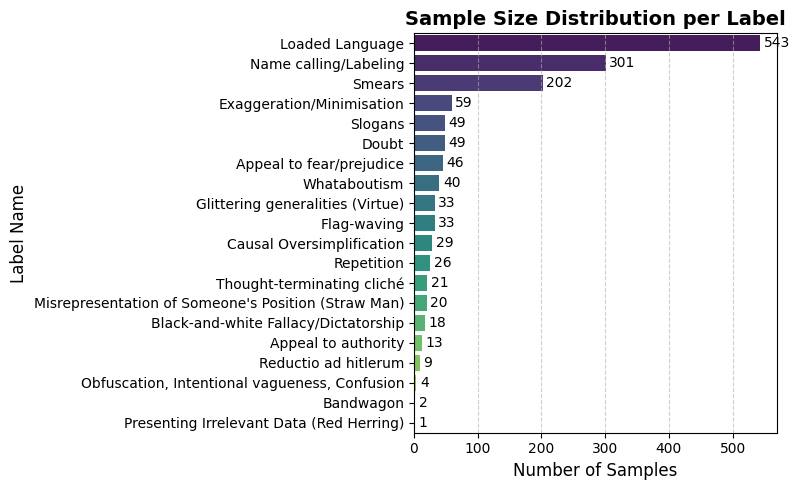

In [11]:
# Extract labels and counts sorted by frequency
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_counts)

# Create plot
#plt.figure(figsize=(10, len(labels) * 0.4 + 2))
plt.figure(figsize=(8, 5))
sns.barplot(x=list(counts), y=list(labels), hue=list(labels), palette="viridis", legend=False)

plt.xlabel("Number of Samples", fontsize=12)
plt.ylabel("Label Name", fontsize=12)
plt.title("Sample Size Distribution per Label", fontsize=14, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Annotate bars with exact counts
for index, count in enumerate(counts):
    plt.text(count + (max(counts) * 0.01), index, f"{count:,}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

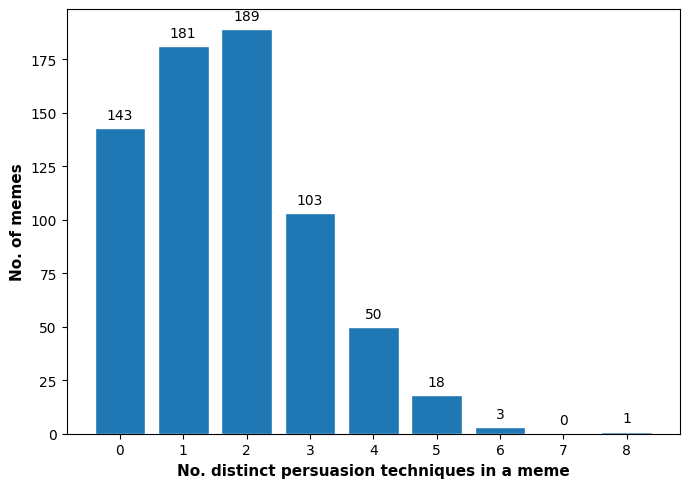

In [12]:
### for Task 1 ###
#get distinct techniques

distinct_counts = df_part_b['labels'].apply(
    lambda x: len({item['technique'] if isinstance(item, dict) else item for item in x})
    if isinstance(x, (list, set, tuple)) else (1 if pd.notna(x) else 0)
)

# Frequency distribution
distribution = distinct_counts.value_counts()

#freq distr
distribution = distinct_counts.value_counts()

max_techniques = distribution.index.max() if len(distribution) > 0 else 0
distribution = distribution.reindex(range(0, max_techniques + 1), fill_value=0)

#chart
x_values = distribution.index
y_values = distribution.values
plt.figure(figsize=(7, 5))
bars = plt.bar(x_values, y_values, color='#1f77b4', edgecolor='white')
#format labels
plt.xlabel("No. distinct persuasion techniques in a meme", fontsize=11, fontweight="bold")
plt.ylabel("No. of memes", fontsize=11, fontweight="bold")
plt.xticks(x_values)
# show counts for each bar
max_y = max(y_values) if len(y_values) > 0 else 1
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max_y * 0.015),
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()



* Looking at the samples from each category, the task requires contextual understanding, where the order of the words matters, rather than simple keyword matching. Therefore, a Bag-of-Words approach may not be suitable, as it does not capture the relationships between words. A self-attention approach can better capture these contextual relationships and dependencies within the text. A transformer approach would be ideal.

* Given that there are only 545 training samples, using a model pre-trained on a large text corpus would be beneficial. A pre-trained model should be able to  capture aspects of grammar and sentiment, reducing the amount of data that is required to learn these patterns compared with training a model from scratch.

* Furthermore, to maximise performance given the small dataset, 5-fold cross-validation can be used. MultilabelStratifiedKFold divides the dataset into five folds while maintaining a similar distribution of the rare classes across each fold. Five separate model instances are then trained, with each model using four folds for training and the remaining fold for validation. The predictions from the five models can then be averaged to produce the final prediction.


* There is large label disparity.. The dataset is imbalanced, with labels such as "Loaded Language", "Name Calling/Labeling" and "Smears" accounting for a large proportion of the training samples with > than 25% of the samples, labels like Bandwagon, Irrelevant Data, and Confusion are present in less than 2% of the data. As a result, standard Binary Cross-Entropy (BCE) may not adequately account for underrepresented positive labels, potentially leading to poorer performance with the minority classes. Therefore, Weighted Binary Cross-Entropy (Weighted BCE) can be used to address this imbalance by assigning higher weights to positive instances of less frequent classes, with weights inversely proportional to their frequency. This helps the model put greater weight on learning under-represented labels.

* Because the class distribution is imbalanced, Macro F1 will be used as the primary evaluation metric, as it assigns equal importance to each class and therefore provides greater sensitivity to performance on minority classes. In contrast, Micro F1 aggregates true positives, false positives, and false negatives across all classes, meaning that its score is influenced more heavily by the majority classes. Therefore, Micro F1 will be used as a supplementary metric to Macro F1 to provide additional insight into overall performance across the observed class distribution.

* From the current bechmark from, Dimitrov et al. (2021):
   * For Task 1. Team MinD archieved a F1-Micro score of .593 and .290 so this model should at least archieve the same benchmark score.
   * For Task 2. Team Volta archieved for F1: .482, Precision: .501, Recall: .464.
   * MinD did not compete on Task 2, only on Task 1 and Task 3. Volta archieved the best combination of both Task 1 and Task 2 with F1-Micro: .570 and F1-Macro .266
   * For these experiments the benchmark for both Tasks will be:
      * Task 1: F1-Micro: .570 and F1-Macro .266
      * Task 2: F1: .482, Precision: .501, Recall: .464.

* Dimitrov et al. (2021) mentions that there are biases in the training data:
That there are sizable disparities in the frequency of different techniques accross the data set.
The data set was sourced to 26 specific facebook groups, that were heavily focused on the politcics, pandamic, vaccines and gender equality. The uses of this solution may not use the same techniques or types of memes, if we solely train the model only on the SemEval-2021 Task 6 training samples.

* As the dataset may not accurately represent the data that users are likely to generate in real-world scenarios, using a pre-trained model may improve generalisation by leveraging representations learned from a broader and more diverse dataset than the available training set.

* Augmentation was used by some teams in (Dimitrov et al., 2021):
  * Such as by Team LIIR which used paraphrased augmentations of the orginal meme with back tranlsation where the text is translated to another language and then back again.
  * Team LeCun (Da San Martino et al., 2020) merged the data set with the additional external news/text propaganda dataset, aswell as multi step back translation between English, Dutch, Russian and English - thr process from (Daval-Frerot & Weis, 2020). A Clear back translation process is mentioned by Team LIIR (Ghadery et al., 2021) where they paraphrased each original sentence by translating it into a target language and then translating it back to the original language, English to German and back again.

* Becuase the data set is small to increase the size, the PTC corpus ( which has more than 20,000 sentences) from SemEval-2020 task 11 (Da San Martino et al., 2020) can be included. It was used in MinD ensamble approach (Tian et al., 2021). A subset of the data was retrived from (https://zenodo.org/records/3952415). MinD uses a process (sentence-level annotations) where they extract the label sample from the article with the start and end positions.

* For Task 1 (Gupta et al., 2021) Volta uses transfer learning with small and large variants of models - BERT and RoBERTa.

* For Task 1 (Tian et al., 2021) MinD uses transfer learninig with pretrained model RoBERTa, that has the advantage of dynamic masking and Byte-Pair Encoding (BPE) (Sennrich et al., 2016), it archieves a F1-Micro score of 0.6478 on the dev data set. They however use an ensemble by averaging the predictions across RoBERTa, XLNet, DeBERTa, and ALBERT for Task 1.




In [13]:
print(df_part_b.head())

    id                                               text  \
0  128    THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n   
1  189                           This is not an accident!   
2   96  SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...   
3  154  PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...   
4   15  WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n   

                                              labels  \
0  [{'start': 0, 'end': 41, 'technique': 'Black-a...   
1                                                 []   
2  [{'start': 47, 'end': 83, 'technique': 'Slogan...   
3  [{'start': 0, 'end': 8, 'technique': 'Loaded L...   
4                                                 []   

                                    doc_level_labels  
0  [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
3  [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...  
4  [0.0, 0.0, 0.0, 0.

In [14]:
# Valid class headings
df_labels = [
    "Appeal to authority",
    "Appeal to fear/prejudice",
    "Black-and-white Fallacy/Dictatorship",
    "Causal Oversimplification",
    "Doubt",
    "Exaggeration/Minimisation",
    "Flag-waving",
    "Glittering generalities (Virtue)",
    "Loaded Language",
    "Misrepresentation of Someone's Position (Straw Man)",
    "Name calling/Labeling",
    "Obfuscation, Intentional vagueness, Confusion",
    "Presenting Irrelevant Data (Red Herring)",
    "Reductio ad hitlerum",
    "Repetition",
    "Slogans",
    "Smears",
    "Thought-terminating cliché",
    "Whataboutism",
    "Bandwagon",
    "Transfer",
    "Appeal to (Strong) Emotions"
]
label_lookup = {label: label for label in df_labels}

In [15]:
#show the class counts of DF (training_set_task1.txt)
label_counts = (
    df_part_b["labels"]
    .dropna()
    .explode()
    # Step 1: Extract string from dict (change 'technique' if your key is different)
    .map(lambda x: x.get('technique') if isinstance(x, dict) else x)
    # Step 2: Look up mapped label name
    .map(lambda x: label_lookup.get(x, x))
    .dropna()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)

print(label_counts)

labels
Appeal to authority                                     13
Appeal to fear/prejudice                                46
Black-and-white Fallacy/Dictatorship                    18
Causal Oversimplification                               29
Doubt                                                   49
Exaggeration/Minimisation                               59
Flag-waving                                             33
Glittering generalities (Virtue)                        33
Loaded Language                                        543
Misrepresentation of Someone's Position (Straw Man)     20
Name calling/Labeling                                  301
Obfuscation, Intentional vagueness, Confusion            4
Presenting Irrelevant Data (Red Herring)                 1
Reductio ad hitlerum                                     9
Repetition                                              26
Slogans                                                 49
Smears                                           

* Stratified splitting requires that there is at least 2 samples per class, the following classes only have a single sample:           1
   * Presenting Irrelevant Data (Red Herring)                 1    
* Data Augmentation can solve this and adding more samples, Adding the samples from the PTC data set for the to try and obtain a better balance        

In [16]:
# -----------------------------
# Create normalised text keys
# -----------------------------
'''
positive_sentences_df["text_key"] = (
    positive_sentences_df["sentence_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)'''

df_part_b["text_key"] = (
    df_part_b["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [17]:
#general seed used so that fixed random seed used through experiments
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [18]:
# ------------------------------------------------------------------------------
# Global settings
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
MAX_LENGTH = 160                          # As the longest meme is 142 tokens
K_FOLDS = 5
BATCH_SIZE = 16
THRESHOLDS = np.arange(0.05, 0.96, 0.05)

P1_EPOCHS = 5                             # phase 1: heads only (encoder frozen)
P2_EPOCHS = 5                           # phase 2: LoRA + heads
PATIENCE = 5

all_results = {}                          # histories for plot_experiments
if "results_scores" not in globals():
    results_scores = {}

In [19]:
#[3] load training_set_task2.txt and build the document labels from the spans

with open("training_set_task2.txt", "r", encoding="utf-8") as f:
    data_task2 = json.load(f)

df2 = pd.DataFrame(data_task2)
df2["id"] = df2["id"].astype(str)

#the 20 techniques that can appear in the text (Transfer and Appeal to (Strong) Emotions are image-only)
TECHNIQUES = sorted({l["technique"] for item in data_task2 for l in item["labels"]})
label2id = {label: idx for idx, label in enumerate(TECHNIQUES)}
NUM_CLASSES = len(TECHNIQUES)
print(f"Number of techniques found in the spans: {NUM_CLASSES}")

#list of (start, end, technique) per meme
df2["spans"] = df2["labels"].apply(lambda ls: [(int(l["start"]), int(l["end"]), l["technique"]) for l in ls])

#document level label = every technique that has at least one span in the meme
df2["doc_labels"] = df2["spans"].apply(lambda sp: sorted({t for _, _, t in sp}))

Y = np.array([[1.0 if t in d else 0.0 for t in TECHNIQUES] for d in df2["doc_labels"]], dtype=np.float32)

#sanity check: the span offsets must point at the annotated text fragment
bad_offsets = 0
for item in data_task2:
    for l in item["labels"]:
        if "text_fragment" in l and item["text"][l["start"]:l["end"]] != l["text_fragment"]:
            bad_offsets += 1

print(f"Total memes:               {len(df2)}")
print(f"  with at least one span:  {(Y.sum(axis=1) > 0).sum()}")
print(f"  with no technique:       {(Y.sum(axis=1) == 0).sum()}")
print(f"Total span instances:      {df2['spans'].map(len).sum()}")
print(f"Spans whose offsets do not match text_fragment: {bad_offsets}")

Number of techniques found in the spans: 20
Total memes:               688
  with at least one span:  545
  with no technique:       143
Total span instances:      1498
Spans whose offsets do not match text_fragment: 0


,memes (Part A),span instances (Part B),spans per meme
Loaded Language,358,543,1.52
Name calling/Labeling,218,301,1.38
Smears,200,202,1.01
Exaggeration/Minimisation,52,59,1.13
Doubt,48,49,1.02
Slogans,44,49,1.11
Appeal to fear/prejudice,43,46,1.07
Whataboutism,40,40,1.00
Glittering generalities (Virtue),32,33,1.03
Causal Oversimplification,27,29,1.07


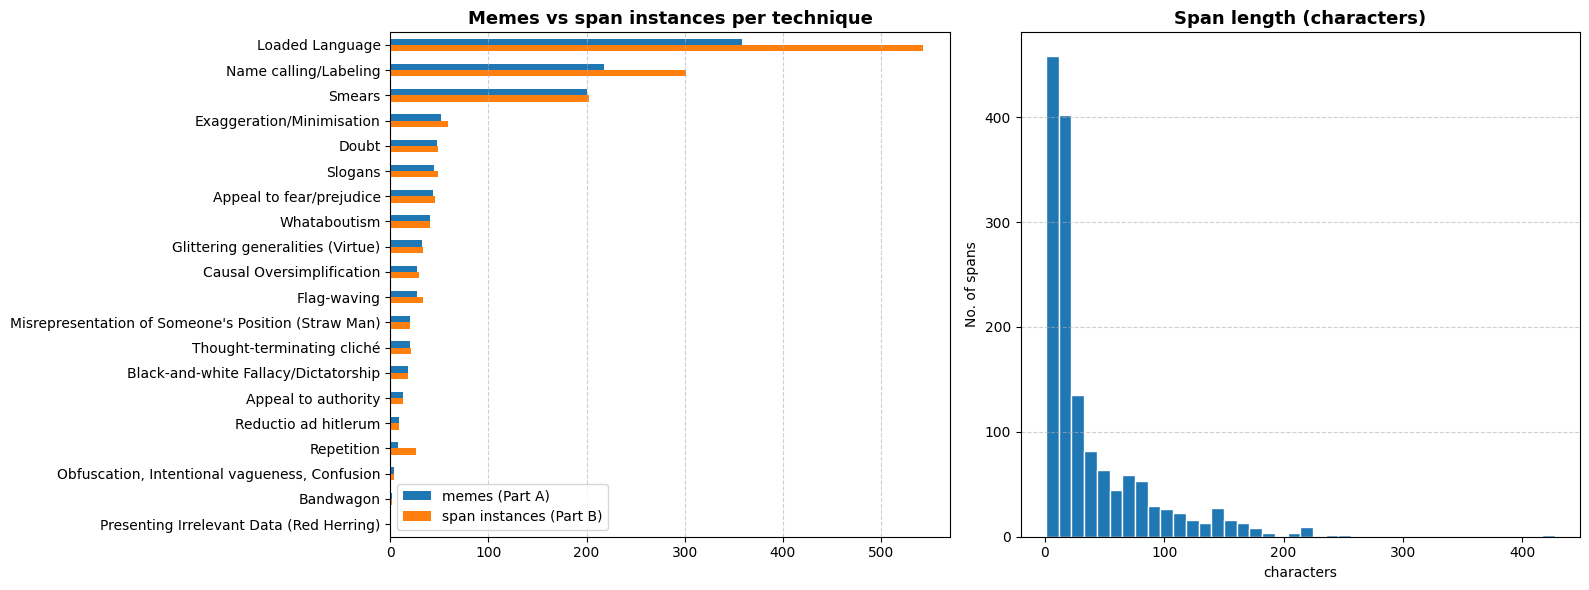

count    1498.0
mean       39.7
std        49.2
min         1.0
50%        19.0
90%       104.0
99%       218.1
max       427.0
dtype: float64


In [20]:
#[4] span statistics per technique: memes containing the technique vs number of span instances

span_counts = pd.Series([t for sp in df2["spans"] for _, _, t in sp]).value_counts().reindex(TECHNIQUES, fill_value=0)
meme_counts = pd.Series(Y.sum(axis=0).astype(int), index=TECHNIQUES)
span_len = pd.Series([e - s for sp in df2["spans"] for s, e, _ in sp])

span_table = pd.DataFrame({"memes (Part A)": meme_counts, "span instances (Part B)": span_counts})
span_table["spans per meme"] = (span_table["span instances (Part B)"] / span_table["memes (Part A)"].replace(0, np.nan)).round(2)
span_table = span_table.sort_values("memes (Part A)", ascending=False)
display(span_table)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
span_table[["memes (Part A)", "span instances (Part B)"]].plot.barh(ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Memes vs span instances per technique", fontsize=13, fontweight="bold")
axes[0].grid(axis="x", linestyle="--", alpha=0.6)

axes[1].hist(span_len, bins=40, color="#1f77b4", edgecolor="white")
axes[1].set_title("Span length (characters)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("characters")
axes[1].set_ylabel("No. of spans")
axes[1].grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(span_len.describe(percentiles=[0.5, 0.9, 0.99]).round(1))

* Some techniques are used several times in the same meme for example: (id: 106: Loaded Language),
* Part B contains more instances than Part A contains memes, as some techniques such as: (Slogans and Doubt) span an entire sentence.
* Span lengths range from a single word to the entire meme, seems that the use of a token level prediction head that predicts each token rather than relying on a fixed length window.
```json
{
        "id": "106",
        "text": "TRUMP CURES CORONAVIRUS!\n\nCURING CORONA VIRUS IS RACIST\n\nWE HAVE THE RIGHT TO DIE FROM OUR CORONAVIRUS\n\nDEMOCRATS ARE OUTRAGED!\n",
        "labels": [
            {
                "end": 55,
                "start": 49,
                "technique": "Loaded Language",
                "text_fragment": "RACIST"
            },
            {
                "end": 55,
                "start": 49,
                "technique": "Name calling/Labeling",
                "text_fragment": "RACIST"
            },
            {
                "end": 81,
                "start": 78,
                "technique": "Loaded Language",
                "text_fragment": "DIE"
            },
            {
                "end": 126,
                "start": 118,
                "technique": "Loaded Language",
                "text_fragment": "OUTRAGED"
            },
            {
                "end": 24,
                "start": 0,
                "technique": "Exaggeration/Minimisation",
                "text_fragment": "TRUMP CURES CORONAVIRUS!"
            },
            {
                "end": 102,
                "start": 26,
                "technique": "Misrepresentation of Someone's Position (Straw Man)",
                "text_fragment": "CURING CORONA VIRUS IS RACIST\n\nWE HAVE THE RIGHT TO DIE FROM OUR CORONAVIRUS"
            },
            {
                "end": 81,
                "start": 69,
                "technique": "Loaded Language",
                "text_fragment": "RIGHT TO DIE"
            },
            {
                "end": 24,
                "start": 0,
                "technique": "Glittering generalities (Virtue)",
                "text_fragment": "TRUMP CURES CORONAVIRUS!"
            },
            {
                "end": 127,
                "start": 104,
                "technique": "Smears",
                "text_fragment": "DEMOCRATS ARE OUTRAGED!"
            }
        ]
    }
```


In [21]:
#[5] one fixed split for Part A, Part B and Part C: 15% hold-out test, 5-fold CV on the rest

idx = np.arange(len(df2))

#extra "no technique" column, used for stratification only, so empty memes are represented in every split
Y_strat = np.hstack([Y, (Y.sum(axis=1) == 0)[:, None]])

# ------------------------------------------------------------------------------
# A. Hold out 15% as the final test set (only used once, at the end)
# ------------------------------------------------------------------------------
msss = MSSS(n_splits=1, test_size=0.15, random_state=SEED)
idx_cv, idx_test = next(msss.split(idx, Y_strat))

# ------------------------------------------------------------------------------
# B. 5-fold CV on the remaining 85% (model selection, early stopping, thresholds)
# ------------------------------------------------------------------------------
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
cv_splits = [(idx_cv[tr], idx_cv[va]) for tr, va in mskf.split(idx_cv, Y_strat[idx_cv])]

#save the split by meme id so every Part C experiment uses exactly the same test memes
two_head_splits = {
    "test_ids": df2["id"].iloc[idx_test].tolist(),
    "cv_folds": {f"fold_{k+1}": {"train_ids": df2["id"].iloc[tr].tolist(),
                                 "val_ids": df2["id"].iloc[va].tolist()}
                 for k, (tr, va) in enumerate(cv_splits)}
}
with open("two_head_splits.json", "w") as f:
    json.dump(two_head_splits, f, indent=1)

split_counts = pd.DataFrame({"train+val (85%)": Y[idx_cv].sum(0).astype(int),
                             "test (15%)": Y[idx_test].sum(0).astype(int)}, index=TECHNIQUES)
split_counts.loc["(no technique)"] = [int((Y[idx_cv].sum(1) == 0).sum()), int((Y[idx_test].sum(1) == 0).sum())]
print(f"train+val: {len(idx_cv)} memes | test: {len(idx_test)} memes")
display(split_counts)

train+val: 585 memes | test: 103 memes


,train+val (85%),test (15%)
Appeal to authority,11,2
Appeal to fear/prejudice,37,6
Bandwagon,2,0
Black-and-white Fallacy/Dictatorship,15,3
Causal Oversimplification,23,4
Doubt,41,7
Exaggeration/Minimisation,44,8
Flag-waving,23,4
Glittering generalities (Virtue),27,5
Loaded Language,304,54


In [22]:
#[6] pre-tokenised dataset with document labels as well as token labels

tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

class TwoHeadDataset(Dataset):
    '''
    Tokenises every meme once. For each token we keep its character offsets and a
    20-dim multi-hot label: technique k = 1 if the token overlaps any span of technique k.
    Special and padding tokens get -100 so they are ignored by the token loss.
    '''
    def __init__(self, texts, spans, doc_labels, tokenizer, max_len=MAX_LENGTH, num_classes=NUM_CLASSES):
        enc = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_offsets_mapping=True,
            return_tensors="pt"
        )
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.offsets = enc["offset_mapping"]
        self.doc_labels = torch.tensor(doc_labels, dtype=torch.float32)
        self.tok_labels = torch.zeros((len(texts), max_len, num_classes), dtype=torch.float32)

        for i, (offs, sp) in enumerate(zip(self.offsets, spans)):
            starts, ends = offs[:, 0], offs[:, 1]
            special = ends <= starts                      # <s>, </s> and padding have (0, 0)
            self.tok_labels[i, special, :] = -100
            for s, e, t in sp:
                hit = (~special) & (starts < e) & (ends > s)
                self.tok_labels[i, hit, label2id[t]] = 1.0

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "doc_labels": self.doc_labels[idx],
            "tok_labels": self.tok_labels[idx],
            "offsets": self.offsets[idx],
        }

full_dataset = TwoHeadDataset(df2["text"].tolist(), df2["spans"].tolist(), Y, tokenizer)
GOLD_SPANS = df2["spans"].tolist()

#check one meme: print each token that carries a technique
ex = int(np.argmax(df2["spans"].map(len).values))
toks = tokenizer.convert_ids_to_tokens(full_dataset.input_ids[ex])
print(df2["text"].iloc[ex])
for tok, lab in zip(toks, full_dataset.tok_labels[ex]):
    if lab[0] != -100 and lab.sum() > 0:
        print(f"{tok:>15} -> {[TECHNIQUES[k] for k in torch.where(lab == 1)[0].tolist()]}")

The Democratic Party IS THE PARTY OF CRIME & EVIL...  A TERRORIST ORGANIZATION WHO HATES AMERICA & AMERICANS

TRAITORS TO AMERICA

THE COMMUNIST PARTY

SAVE AMERICA SUPPORT TRUMP

            The -> ['Smears']
    ĠDemocratic -> ['Smears']
         ĠParty -> ['Smears']
            ĠIS -> ['Smears']
           ĠTHE -> ['Loaded Language', 'Smears']
          ĠPART -> ['Loaded Language', 'Name calling/Labeling', 'Smears']
              Y -> ['Loaded Language', 'Name calling/Labeling', 'Smears']
            ĠOF -> ['Loaded Language', 'Name calling/Labeling', 'Smears']
            ĠCR -> ['Loaded Language', 'Name calling/Labeling', 'Smears']
            IME -> ['Loaded Language', 'Name calling/Labeling', 'Smears']
             Ġ& -> ['Loaded Language', 'Name calling/Labeling', 'Smears']
            ĠEV -> ['Loaded Language', 'Name calling/Labeling', 'Smears']
             IL -> ['Loaded Language', 'Name calling/Labeling', 'Smears']
            ... -> ['Loaded Language', 'Smears']
          

## Model Architecture

- RoBERTa converts a meme into one 768-dimensional vector per token.

- Part A: The document head combines the token vectors into a single representation of the whole meme and predicts the propaganda techniques present.

- Part B: The token head makes a prediction for each token to identify the propaganda technique associated with it.

- Both heads use the same RoBERTa encoder and are trained together.

The process will look like:

Meme → RoBERTa encoder → token vectors

    → Document head → Part A prediction

    → Token head → Part B prediction

The two prediction errors are combined during training. The token-level error can be given more or less influence on the shared encoder.

The experiments compare different pooling types, head depths, and values controlling the influence of the token-level task.

In [23]:
#[7] two-head model

class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, hidden_states, attention_mask):
        scores = self.score(hidden_states).squeeze(-1)
        scores = scores.masked_fill(attention_mask == 0, -1e4)
        weights = torch.softmax(scores, dim=-1)
        pooled = (weights.unsqueeze(-1) * hidden_states).sum(dim=1)
        return pooled, weights



class RobertaTwoHeadPersuasion(RobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.pooling = getattr(config, "pooling", "attn")
        H = config.hidden_size
        
        #drop out for RoBERTa
        dropout = config.classifier_dropout if config.classifier_dropout is not None else config.hidden_dropout_prob

        self.roberta = RobertaModel(config, add_pooling_layer=False)
        self.attn_pool = AttentionPooling(H)
        
        #using RoBERTa classifcation head
        self.doc_head = RobertaClassificationHead(config)
        
        #using RoBERTa token classification layer
        self.tok_head = nn.Sequential(nn.Dropout(dropout), nn.Linear(H, config.num_labels))

        #set per fold with set_loss_weights()
        self.doc_pos_weight = None
        self.tok_pos_weight = None
        self.lam = 1.0

        self.post_init()

    def set_loss_weights(self, doc_pos_weight, tok_pos_weight, lam):
        self.doc_pos_weight = doc_pos_weight
        self.tok_pos_weight = tok_pos_weight
        self.lam = lam

    
    def forward(self, input_ids=None, attention_mask=None, doc_labels=None, tok_labels=None, **kwargs):
        hidden = self.roberta(input_ids=input_ids, attention_mask=attention_mask)[0]

        attn_weights = None
        if self.pooling == "cls":
            pooled = hidden[:, 0]
        elif self.pooling == "mean":
            m = attention_mask.unsqueeze(-1).to(hidden.dtype)
            pooled = (hidden * m).sum(1) / m.sum(1).clamp(min=1)
        else:
            pooled, attn_weights = self.attn_pool(hidden, attention_mask)
            
        #RobertaClassificationHead reads token 0, pass pooled vector as a one token sequence
        doc_logits = self.doc_head(pooled.unsqueeze(1))         # (B, C)
        tok_logits = self.tok_head(hidden)            # (B, T, C)

        loss = doc_loss = tok_loss = None
        if doc_labels is not None and tok_labels is not None:
            #doc loss: a label of -1 means "unknown for this example" (PTC techniques it cannot label)
            #-> left out of the loss instead of being treated as a negative
            doc_valid = (doc_labels >= 0).float()
            doc_l = nn.functional.binary_cross_entropy_with_logits(
                doc_logits, doc_labels.clamp(min=0), pos_weight=self.doc_pos_weight, reduction="none")
            doc_loss = (doc_l * doc_valid).sum() / doc_valid.sum().clamp(min=1)

            #only real tokens: attention == 1 and label != -100
            active = (attention_mask.view(-1) == 1) & (tok_labels.view(-1, self.num_labels)[:, 0] != -100)
            active_logits = tok_logits.view(-1, self.num_labels)[active]
            active_labels = tok_labels.view(-1, self.num_labels)[active]
            if active_logits.shape[0] > 0:
                #token loss: same rule, -1 classes are left out
                tok_valid = (active_labels >= 0).float()
                tok_l = nn.functional.binary_cross_entropy_with_logits(
                    active_logits, active_labels.clamp(min=0), pos_weight=self.tok_pos_weight, reduction="none")
                tok_loss = (tok_l * tok_valid).sum() / tok_valid.sum().clamp(min=1)
            else:
                tok_loss = tok_logits.sum() * 0.0

            loss = doc_loss + self.lam * tok_loss

        return {"loss": loss, "doc_loss": doc_loss, "tok_loss": tok_loss,
                "doc_logits": doc_logits, "tok_logits": tok_logits, "attn_weights": attn_weights,
                "pooled": pooled}
        


def build_two_head_model(pooling="attn", head_hidden=256):
    config = AutoConfig.from_pretrained(MODEL_NAME, num_labels=NUM_CLASSES)
    config.pooling = pooling
    config.head_hidden = head_hidden
    return RobertaTwoHeadPersuasion.from_pretrained(MODEL_NAME, config=config).to(device)


def inject_lora(model, r=8, lora_dropout=0.1):
    #LoRA adapters on the encoder only; the two heads stay fully trainable
    lora_config = LoraConfig(r=r, lora_alpha=2 * r, lora_dropout=lora_dropout, target_modules=["query", "value"])
    model.roberta = get_peft_model(model.roberta, lora_config)
    return model


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    heads = sum(p.numel() for n, p in model.named_parameters() if not n.startswith("roberta."))
    return total, trainable, heads

### Metrics
* **Part A**: the same "f1_stats"/"best_threshold" (Macro-F1 and Micro-F1, exact match, label accuracy), so the scores are comparable. Micro-F1 was used in SemEval Task 1 measure.
  Because "f1_stats" averages Macro-F1 only over techniques present in the evaluated set, the final report also gives Macro-F1 over all 20 techniques, minus the techniques count as 0.
* **Part B**: In (Dimitrov et al., 2021, Section 5.1) for measuring how accurately the predicted spans match the correct spans, is where the prediction gets partial credit when it overlaps with the correct span (predicted tokens are joined together to form a span)
    * Precision: measures how much of the predicted span is correct,
    * recall: measures how much of the correct span was found.
    * These are averaged across all spans and combined into an F1 score.

* early stopping uses the mean of validation doc Macro-F1 and span F1

In [24]:
#[8] metric utilities, span decoding and training functions

def f1_stats(y_true, y_pred):
    #same as the earlier experiments
    tp = (y_true * y_pred).sum(axis=0)
    fp = ((1 - y_true) * y_pred).sum(axis=0)
    fn = (y_true * (1 - y_pred)).sum(axis=0)
    den = 2 * tp + fp + fn
    per_class = np.divide(2 * tp, den, out=np.zeros_like(den, dtype=np.float64), where=den > 0)

    observed = y_true.sum(axis=0) > 0
    macro_f1 = float(per_class[observed].mean()) if observed.any() else 0.0
    micro_f1 = float(2 * tp.sum() / max(den.sum(), 1))
    exact_match = float((y_true == y_pred).all(axis=1).mean())
    accuracy = float((y_true == y_pred).mean())
    return macro_f1, micro_f1, exact_match, accuracy, per_class


def best_threshold(y_true, probs):
    scores = [f1_stats(y_true, (probs >= t).astype(np.float32))[0] for t in THRESHOLDS]
    best_idx = int(np.argmax(scores))
    return float(THRESHOLDS[best_idx]), float(scores[best_idx])


def decode_spans(tok_probs, offsets, threshold, only_class=None):
    '''
    tok_probs: (n_tokens, C) probabilities for the real tokens of one meme
    offsets:   (n_tokens, 2) character offsets of those tokens
    Consecutive tokens above the threshold are merged into one (start, end, technique) span.
    '''
    spans = []
    classes = range(NUM_CLASSES) if only_class is None else [only_class]
    for k in classes:
        on = tok_probs[:, k] >= threshold
        if not on.any():
            continue
        d = np.diff(np.concatenate([[0], on.astype(np.int8), [0]]))
        for a, b in zip(np.where(d == 1)[0], np.where(d == -1)[0] - 1):
            spans.append((int(offsets[a, 0]), int(offsets[b, 1]), TECHNIQUES[k]))
    return spans


def span_prf(pred_spans, gold_spans):
    #SemEval-2021 Task 6 Subtask 2 measure: partial overlap credit, technique must match
    p_sum, r_sum, n_pred, n_gold = 0.0, 0.0, 0, 0
    for S, T in zip(pred_spans, gold_spans):
        n_pred += len(S)
        n_gold += len(T)
        for s0, s1, ls in S:
            for t0, t1, lt in T:
                if ls == lt:
                    inter = max(0, min(s1, t1) - max(s0, t0))
                    if inter > 0:
                        p_sum += inter / (s1 - s0)
                        r_sum += inter / (t1 - t0)
    precision = p_sum / n_pred if n_pred else 0.0
    recall = r_sum / n_gold if n_gold else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"precision": precision, "recall": recall, "f1": f1}


def score_predictions(doc_true, doc_probs, tok_probs, offsets, gold_spans, threshold=None, tok_threshold=None):
    #Part A
    if threshold is None:
        threshold, _ = best_threshold(doc_true, doc_probs)
    doc_preds = (doc_probs >= threshold).astype(np.float32)
    macro_f1, micro_f1, exact_match, accuracy, per_class_f1 = f1_stats(doc_true, doc_preds)

    #Part B
    def spans_at(t):
        return [decode_spans(tp, off, t) for tp, off in zip(tok_probs, offsets)]
    if tok_threshold is None:
        tok_threshold = max(THRESHOLDS, key=lambda t: span_prf(spans_at(t), gold_spans)["f1"])
    span_preds = spans_at(tok_threshold)
    span = span_prf(span_preds, gold_spans)

    return {
        "macro_f1": macro_f1, "micro_f1": micro_f1, "exact_match": exact_match, "accuracy": accuracy,
        "per_class_f1": per_class_f1, "threshold": float(threshold),
        "span_f1": span["f1"], "span_precision": span["precision"], "span_recall": span["recall"],
        "tok_threshold": float(tok_threshold),
        "doc_probs": doc_probs, "doc_preds": doc_preds, "tok_probs": tok_probs,
        "offsets": offsets, "span_preds": span_preds,
    }


def get_trainable_state(model):
    #only the trainable weights (heads + LoRA); the frozen RoBERTa weights are identical for every fold
    return {n: p.detach().cpu().clone() for n, p in model.named_parameters() if p.requires_grad}


def train_one_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss, total_doc, total_tok, total_samples = 0.0, 0.0, 0.0, 0

    for batch in loader:
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            doc_labels=batch["doc_labels"].to(device),
            tok_labels=batch["tok_labels"].to(device)
        )
        loss = outputs["loss"]
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        bs = len(batch["input_ids"])
        total_loss += loss.item() * bs
        total_doc += outputs["doc_loss"].item() * bs
        total_tok += outputs["tok_loss"].item() * bs
        total_samples += bs

    n = max(total_samples, 1)
    return total_loss / n, total_doc / n, total_tok / n


def evaluate_model(model, loader, gold_spans, threshold=None, tok_threshold=None):
    '''
    gold_spans must be in the same order as the loader (shuffle=False).
    threshold / tok_threshold: None = tune on this set (validation only); pass the
    validation thresholds when evaluating the test set.
    '''
    model.eval()
    total_loss, total_samples = 0.0, 0
    doc_probs, doc_true, tok_probs, offsets = [], [], [], []

    with torch.inference_mode():
        for batch in loader:
            tok_labels = batch["tok_labels"]
            outputs = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
                doc_labels=batch["doc_labels"].to(device),
                tok_labels=tok_labels.to(device)
            )
            bs = len(batch["input_ids"])
            total_loss += outputs["loss"].item() * bs
            total_samples += bs

            doc_probs.append(torch.sigmoid(outputs["doc_logits"]).cpu().numpy())
            doc_true.append(batch["doc_labels"].numpy())
            tp = torch.sigmoid(outputs["tok_logits"]).cpu().numpy()
            for i in range(bs):
                real = (tok_labels[i, :, 0] != -100).numpy()
                tok_probs.append(tp[i][real])
                offsets.append(batch["offsets"][i].numpy()[real])

    res = score_predictions(np.concatenate(doc_true), np.concatenate(doc_probs), tok_probs, offsets,
                            gold_spans, threshold, tok_threshold)
    res["loss"] = total_loss / max(total_samples, 1)
    res["doc_true"] = np.concatenate(doc_true)
    return res


def run_experiment(model, optimizer, train_loader, val_loader, val_gold_spans,
                   epochs=10, patience=5, name="Model", scheduler=None, verbose=True):
    '''
    Train with early stopping on the validation score = mean(doc Macro-F1, span F1).
    The loss is computed inside the model, so no criterion is passed.
    '''
    history = {"train_loss": [], "train_doc_loss": [], "train_tok_loss": [], "val_loss": [],
               "val_macro": [], "val_micro": [], "val_span_f1": [], "val_score": []}
    best_info = {"epoch": 0, "score": -1.0, "thr": 0.5, "tok_thr": 0.5, "state": get_trainable_state(model)}
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_doc, train_tok = train_one_epoch(model, train_loader, optimizer, scheduler)
        val_res = evaluate_model(model, val_loader, val_gold_spans)
        val_score = (val_res["macro_f1"] + val_res["span_f1"]) / 2

        history["train_loss"].append(train_loss)
        history["train_doc_loss"].append(train_doc)
        history["train_tok_loss"].append(train_tok)
        history["val_loss"].append(val_res["loss"])
        history["val_macro"].append(val_res["macro_f1"])
        history["val_micro"].append(val_res["micro_f1"])
        history["val_span_f1"].append(val_res["span_f1"])
        history["val_score"].append(val_score)

        if val_score > best_info["score"] + 1e-4:
            best_info = {"epoch": epoch, "score": val_score, "macro_f1": val_res["macro_f1"],
                         "micro_f1": val_res["micro_f1"], "span_f1": val_res["span_f1"],
                         "thr": val_res["threshold"], "tok_thr": val_res["tok_threshold"],
                         "state": get_trainable_state(model)}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(
                f"[{name}] Epoch {epoch:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} (doc {train_doc:.4f}, tok {train_tok:.4f}) | "
                f"Val Loss: {val_res['loss']:.4f} | "
                f"Val Macro-F1: {val_res['macro_f1']:.3f} | "
                f"Val Micro-F1: {val_res['micro_f1']:.3f} | "
                f"Val Span-F1: {val_res['span_f1']:.3f} | "
                f"Thr: {val_res['threshold']:.2f}/{val_res['tok_threshold']:.2f}"
            )

        if epochs_no_improve >= patience:
            if verbose:
                print(f"[{name}] Early stopping at epoch {epoch}. Best epoch {best_info['epoch']}, "
                      f"Val score {best_info['score']:.3f}")
            break

    model.load_state_dict(best_info["state"], strict=False)
    return history, best_info

'''
def plot_experiments(results, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for name, res in results.items():
        h = res["history"]
        ep = range(1, len(h["train_loss"]) + 1)
        axes[0].plot(ep, h["train_loss"], label=f"{name} train")
        axes[0].plot(ep, h["val_loss"], "--", label=f"{name} val")
        axes[1].plot(ep, h["val_macro"], label=name)
        axes[2].plot(ep, h["val_span_f1"], label=name)
    axes[0].set_title("Loss (solid = train, dashed = val)")
    axes[1].set_title("Validation Macro-F1 (Part A)")
    axes[2].set_title("Validation Span-F1 (Part B)")
    for a in axes:
        a.set_xlabel("Epoch")
        a.grid(linestyle="--", alpha=0.6)
    axes[1].legend(fontsize=7)
    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    '''

def plot_experiments(results, show_train=True, show_val=True, title=""):
    '''
    results: {name: {"history": ..., "best_info": ...}} (as returned in fold_histories)
             or {name: history}
    Loss: train (solid, o) and validation (dashed, x).
    F1:   validation only (training F1 is not computed during training).
    '''
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for name, res in results.items():
        hist = res["history"] if "history" in res else res
        epochs = range(1, len(hist["train_loss"]) + 1)
        if show_train:
            axes[0].plot(epochs, hist["train_loss"], label=f"{name} (Train)", marker="o", markersize=3)
        if show_val:
            axes[0].plot(epochs, hist["val_loss"], label=f"{name} (Val)", linestyle="--", marker="x", markersize=3)
            axes[1].plot(epochs, hist["val_macro"], label=f"{name} (Val)", linestyle="--", marker="x", markersize=3)
            axes[2].plot(epochs, hist["val_span_f1"], label=f"{name} (Val)", linestyle="--", marker="x", markersize=3)

    for ax, ylabel in zip(axes, ["Loss", "Macro-F1 (Part A)", "Span-F1 (Part B)"]):
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.set_title(ylabel)
        ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.7)
    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

### Class weights
* Inverse-frequency weights are reduced using a square root and limited to a maximum value (20 for the document task and 50 for the token task). To void always answering no on rare techniques (1–2 examples, like Red Herring or Bandwagon) there fore we dont want to allow it to have have to much impact on the loss. The weights are processed using only the training memes in each fold.

* Positive token labels will be a much less occurance than positive document labels as most tokens would not be a propaganda technique. Therefore, the token head uses separate weights based on the token- evel labels rather than using the document level weights.

In [25]:
#[9] class weights per fold

def fold_pos_weights(train_idx):
    #document level
    y = Y[train_idx]
    pos = y.sum(axis=0)
    doc_pw = np.sqrt((len(y) - pos) / np.maximum(pos, 1)).clip(1, 20)

    #token level (only real tokens)
    tl = full_dataset.tok_labels[torch.as_tensor(train_idx)].reshape(-1, NUM_CLASSES)
    tl = tl[tl[:, 0] != -100]
    tpos = (tl == 1).sum(dim=0).numpy()
    tneg = (tl == 0).sum(dim=0).numpy()
    tok_pw = np.sqrt(tneg / np.maximum(tpos, 1)).clip(1, 50)

    return (torch.tensor(doc_pw, dtype=torch.float32).to(device),
            torch.tensor(tok_pw, dtype=torch.float32).to(device))

In [27]:
#[9a-1] augmentation: back-translation (EN→DE→EN, WMT19) + WordNet synonym substitution
#process used in Ng et al. (2019), subsequently used in Ghadery et al. (2021, Team LIIR)
#generated ONCE for every meme in df2 (fixed seed, cached to disk); a copy is only ever used
#in a fold where its source meme is in the TRAINING part

AUG_CSV = "augmented_memes_task2.csv"


def get_wordnet_pos(tag):
    """Maps NLTK POS tags to WordNet POS tags."""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return None


def substitute_synonyms(text, replacement_prob=0.20):
    """Replaces eligible words with a random WordNet synonym with probability replacement_prob."""
    words = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(words)
    new_words = []
    for word, tag in pos_tags:
        wn_pos = get_wordnet_pos(tag)
        if wn_pos and len(word) > 2 and random.random() < replacement_prob:
            lemmas = [l.name().replace('_', ' ')
                      for s in wordnet.synsets(word, pos=wn_pos)
                      for l in s.lemmas()
                      if l.name().lower() != word.lower()]
            if lemmas:
                new_words.append(random.choice(lemmas))
                continue
        new_words.append(word)
    return " ".join(new_words)


if os.path.exists(AUG_CSV):
    #reuse the saved augmentations so every run trains on exactly the same augmented memes
    aug_df = pd.read_csv(AUG_CSV)
    print(f"Loaded {len(aug_df)} augmented memes from {AUG_CSV}")
else:
    set_seed(SEED)                       #seeds random (synonyms) and torch (sampling in back-translation)

    en_de_tokenizer = AutoTokenizer.from_pretrained("facebook/wmt19-en-de")
    en_de_model = AutoModelForSeq2SeqLM.from_pretrained("facebook/wmt19-en-de").to(device).eval()
    de_en_tokenizer = AutoTokenizer.from_pretrained("facebook/wmt19-de-en")
    de_en_model = AutoModelForSeq2SeqLM.from_pretrained("facebook/wmt19-de-en").to(device).eval()

    def translate_batch(texts, tokenizer, model, sample=False):
        inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.inference_mode():
            if sample:
                outputs = model.generate(**inputs, do_sample=True, temperature=0.8, top_p=0.9,
                                         max_new_tokens=256)     #256 so long memes are not cut off
            else:
                outputs = model.generate(**inputs, max_new_tokens=256)
        return tokenizer.batch_decode(outputs, skip_special_tokens=True)

    aug_rows = []
    texts_all = df2["text"].tolist()
    for i in range(0, len(texts_all), 16):
        batch = texts_all[i:i + 16]
        german = translate_batch(batch, en_de_tokenizer, en_de_model, sample=False)       #EN -> DE
        back = translate_batch(german, de_en_tokenizer, de_en_model, sample=True)         #DE -> EN (varied)
        for j, t in enumerate(back):
            aug_rows.append({"source_pos": i + j,                  #row position of the original meme in df2
                             "source_id": df2["id"].iloc[i + j],
                             "text": substitute_synonyms(t, replacement_prob=0.20)})

    aug_df = pd.DataFrame(aug_rows)
    #drop copies that came back identical to the original
    same = aug_df["text"].str.strip().values == df2["text"].iloc[aug_df["source_pos"]].str.strip().values
    aug_df = aug_df[~same].reset_index(drop=True)
    aug_df.to_csv(AUG_CSV, index=False)
    print(f"Generated and saved {len(aug_df)} augmented memes ({int(same.sum())} identical copies dropped)")

    del en_de_model, de_en_model
    torch.cuda.empty_cache()
    gc.collect()

#side-by-side check of a few examples (look for technique words lost in translation)
display(pd.DataFrame({"original": df2["text"].iloc[aug_df["source_pos"][:5]].values,
                      "augmented": aug_df["text"][:5].values,
                      "labels": df2["doc_labels"].iloc[aug_df["source_pos"][:5]].values}))

#clean the augmented texts: CSV round-trips turn empty strings into NaN, which the tokenizer rejects
aug_df["text"] = aug_df["text"].fillna("").astype(str)
n_before = len(aug_df)
aug_df = aug_df[aug_df["text"].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Dropped {n_before - len(aug_df)} empty augmented texts; {len(aug_df)} remain")


#augmented dataset: same document labels as the source meme; token labels masked (-100)
#because the character spans no longer line up with the changed text -> only the doc head learns from them
aug_source_pos = aug_df["source_pos"].to_numpy()
aug_dataset = TwoHeadDataset(aug_df["text"].tolist(), [[] for _ in range(len(aug_df))],
                             Y[aug_source_pos], tokenizer)
aug_dataset.tok_labels[:] = -100
print(f"Augmented dataset: {len(aug_dataset)} memes")

Loaded 682 augmented memes from augmented_memes_task2.csv


,original,augmented,labels
0,THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n,THERE ARE ONLY TWO GENTER MEN,[Black-and-white Fallacy/Dictatorship]
1,This is not an accident!,This is no coincidence !,[]
2,SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...,SO BERNIE BROS HAS NO ferocity EXCEPT ? MAKE A...,"[Loaded Language, Name calling/Labeling, Sloga..."
3,PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...,PATHETICsThe Cowardly AssholeWeak Failure ! ! ...,"[Causal Oversimplification, Loaded Language, N..."
4,WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n,WHO TRUMP REPRESENTSWHO DEMOCRATIZES REPRESENT,[]


Dropped 2 empty augmented texts; 680 remain
Augmented dataset: 680 memes


### Baseline: linear probing with the two-head architecture
Before tuning anything, we measure how well the architecture performs with **RoBERTa frozen**: only the two RoBERTa heads (the doc head and the token head) are trained, with default settings (λ = 1, `cls` pooling, Adam lr 1e-3, up to 30 epochs with early stopping). It uses the same data, folds, class weights, heads, loss and metrics as the full model; the only difference is that there is no LoRA fine-tuning phase.

This is the reference point for every later step. It shows how much RoBERTa's pretrained representation achieves on its own, so the λ search, pooling search and LoRA fine-tuning can be judged by how much they improve on it. Test-set scores are reported for the final comparison table only; no decision is based on them.

In [28]:
#[9a] Baseline: linear probing (frozen RoBERTa, only the two RoBERTa heads are trained), default settings

# ------------------------------------------------------------------------------
# Baseline settings (defaults, not tuned)
# ------------------------------------------------------------------------------
BASELINE_LAM = 1.0            #both losses count equally
BASELINE_POOLING = "cls"      #RoBERTa's standard [CLS] input to the classification head (as Volta)
PROBE_EPOCHS = 5             #heads only, so more epochs are cheap and needed at lr 1e-3
PROBE_PATIENCE = 8
PROBE_LR = 1e-3

In [29]:
def make_train_dataset(train_idx, use_aug, use_ptc=False):
    '''One fold's training memes (+ augmented copies of THOSE memes only) (+ the PTC subset).
    Validation and test always use original memes only.'''
    parts = [Subset(full_dataset, train_idx)]
    if use_aug:
        keep = np.where(np.isin(aug_source_pos, train_idx))[0]
        parts.append(Subset(aug_dataset, keep))
    if use_ptc:
        parts.append(ptc_dataset)        #news sentences never overlap the memes, so PTC can join every fold
    return parts[0] if len(parts) == 1 else ConcatDataset(parts)

    
def run_kfold_probe(lam=BASELINE_LAM, pooling=BASELINE_POOLING, epochs=PROBE_EPOCHS,
                    patience=PROBE_PATIENCE, lr=PROBE_LR, max_folds=K_FOLDS, tag="Probe", verbose=True,
                    use_aug=False, use_ptc=False):
    '''
    Same data, folds, class weights, heads, loss and metrics as run_kfold_twohead,
    but only Phase 1: RoBERTa stays frozen (no LoRA), only the heads are trained.
    Each fold model also predicts the hold-out test memes; these are only reported,
    never used to choose anything.
    '''
    fold_results, fold_histories, per_fold_test = {}, {}, {}
    test_loader_bl = DataLoader(Subset(full_dataset, idx_test), batch_size=BATCH_SIZE, shuffle=False)
    test_gold_bl = [GOLD_SPANS[i] for i in idx_test]
    ens_doc, ens_tok, test_offsets, test_doc_true = None, None, None, None

    for fold, (train_idx, val_idx) in enumerate(cv_splits[:max_folds]):
        if verbose:
            print(f"\n========== {tag} | FOLD {fold + 1}/{max_folds} ==========")
        set_seed(SEED + fold)
           
        train_loader = DataLoader(make_train_dataset(train_idx, use_aug, use_ptc), batch_size=BATCH_SIZE, shuffle=True,
                                  generator=torch.Generator().manual_seed(SEED + fold))

        val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)
        val_gold = [GOLD_SPANS[i] for i in val_idx]

        model = build_two_head_model(pooling=pooling)
        doc_pw, tok_pw = fold_pos_weights(train_idx)
        model.set_loss_weights(doc_pw, tok_pw, lam)

        #freeze the whole encoder: only doc_head, tok_head (and attn_pool, unused with cls) are trainable
        for p in model.roberta.parameters():
            p.requires_grad = False
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

        history, best_info = run_experiment(model, optimizer, train_loader, val_loader, val_gold,
                                            epochs=epochs, patience=patience,
                                            name=f"{tag}_F{fold+1}", verbose=verbose)

        fold_name = f"{tag} - Fold {fold+1}"
        fold_histories[fold_name] = {"history": history, "best_info": best_info}
        fold_results[fold_name] = {k: best_info[k] for k in ["epoch", "score", "macro_f1", "micro_f1",
                                                            "span_f1", "thr", "tok_thr"]}

        #test predictions with this fold's validation thresholds (reporting only)
        r = evaluate_model(model, test_loader_bl, test_gold_bl, threshold=best_info["thr"],
                           tok_threshold=best_info["tok_thr"])
        per_fold_test[f"Fold {fold+1}"] = {"macro_f1": r["macro_f1"], "micro_f1": r["micro_f1"], "span_f1": r["span_f1"]}
        ens_doc = r["doc_probs"] / max_folds if ens_doc is None else ens_doc + r["doc_probs"] / max_folds
        ens_tok = [t / max_folds for t in r["tok_probs"]] if ens_tok is None else \
                  [a + t / max_folds for a, t in zip(ens_tok, r["tok_probs"])]
        test_offsets, test_doc_true = r["offsets"], r["doc_true"]

        del model, optimizer, train_loader, val_loader
        torch.cuda.empty_cache()
        gc.collect()

    summary = {k: float(np.mean([v[k] for v in fold_results.values()])) for k in ["score", "macro_f1", "micro_f1", "span_f1"]}

    #5-fold ensemble on the test set, mean of the validation thresholds
    ens_thr = float(np.mean([v["thr"] for v in fold_results.values()]))
    ens_tok_thr = float(np.mean([v["tok_thr"] for v in fold_results.values()]))
    test_res = score_predictions(test_doc_true, ens_doc, ens_tok, test_offsets, test_gold_bl,
                                 threshold=ens_thr, tok_threshold=ens_tok_thr)
    return {"summary": summary, "fold_results": fold_results, "fold_histories": fold_histories,
            "per_fold_test": per_fold_test, "test_res": test_res,
            "config": dict(lam=lam, pooling=pooling, epochs=epochs, patience=patience, lr=lr)}

Baseline: frozen RoBERTa + RoBERTa heads | λ=1.0, pooling=cls, lr=0.001, epochs≤5

========== Baseline | FOLD 1/5 ==========
[Baseline_F1] Epoch   1/5 | Train Loss: 1.1650 (doc 0.5724, tok 0.5927) | Val Loss: 0.9906 | Val Macro-F1: 0.142 | Val Micro-F1: 0.172 | Val Span-F1: 0.107 | Thr: 0.05/0.35
[Baseline_F1] Epoch   5/5 | Train Loss: 0.9079 (doc 0.4999, tok 0.4080) | Val Loss: 0.8993 | Val Macro-F1: 0.159 | Val Micro-F1: 0.228 | Val Span-F1: 0.319 | Thr: 0.15/0.35

========== Baseline | FOLD 2/5 ==========
[Baseline_F2] Epoch   1/5 | Train Loss: 1.1771 (doc 0.5805, tok 0.5965) | Val Loss: 1.0256 | Val Macro-F1: 0.151 | Val Micro-F1: 0.194 | Val Span-F1: 0.133 | Thr: 0.05/0.35
[Baseline_F2] Epoch   5/5 | Train Loss: 0.9047 (doc 0.4998, tok 0.4049) | Val Loss: 0.9238 | Val Macro-F1: 0.181 | Val Micro-F1: 0.265 | Val Span-F1: 0.311 | Thr: 0.15/0.35

========== Baseline | FOLD 3/5 ==========
[Baseline_F3] Epoch   1/5 | Train Loss: 1.1397 (doc 0.5746, tok 0.5651) | Val Loss: 1.0775 | Val 

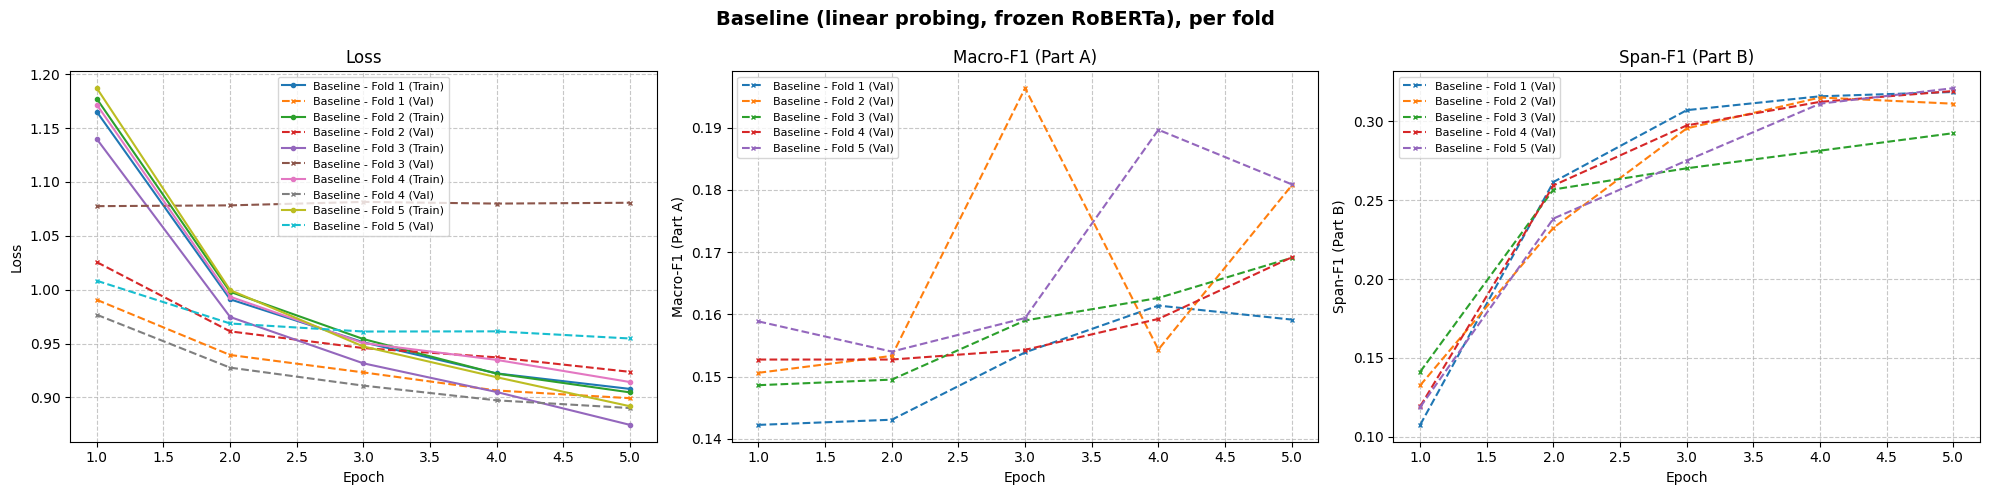

,epoch,score,macro_f1,micro_f1,span_f1,thr,tok_thr
Baseline - Fold 1,5.0,0.239,0.159,0.228,0.319,0.15,0.35
Baseline - Fold 2,3.0,0.246,0.196,0.269,0.296,0.15,0.35
Baseline - Fold 3,5.0,0.231,0.169,0.316,0.293,0.15,0.35
Baseline - Fold 4,5.0,0.244,0.169,0.248,0.319,0.15,0.35
Baseline - Fold 5,5.0,0.251,0.181,0.339,0.321,0.20,0.35



--- Baseline Cross Validation Summary (5 Folds) ---
Average Val Macro-F1: 0.175 ± 0.014
Average Val Micro-F1: 0.280 ± 0.046
Average Val Span-F1:  0.309 ± 0.014

--- Baseline Test Evaluation (5-fold ensemble, reporting only) ---
Part A  Test Macro-F1:            0.159
Part A  Test Macro-F1 (all 20):   0.143
Part A  Test Micro-F1:            0.273
Part B  Test Span-F1:             0.356  (P 0.291, R 0.460)
Per-fold test (mean ± std): macro_f1 0.174 ± 0.023 | micro_f1 0.281 ± 0.047 | span_f1 0.333 ± 0.018


In [30]:
#[9a] Baseline: linear probing (frozen RoBERTa, only the two RoBERTa heads are trained), default settings
# ------------------------------------------------------------------------------
# Run the baseline
# ------------------------------------------------------------------------------
print(f"Baseline: frozen RoBERTa + RoBERTa heads | λ={BASELINE_LAM}, pooling={BASELINE_POOLING}, "
      f"lr={PROBE_LR}, epochs≤{PROBE_EPOCHS}")
baseline_res = run_kfold_probe(tag="Baseline")

all_results.update(baseline_res["fold_histories"])
plot_experiments(baseline_res["fold_histories"], title="Baseline (linear probing, frozen RoBERTa), per fold")

bl_fold_df = pd.DataFrame(baseline_res["fold_results"]).T
display(bl_fold_df.round(3))

print(f"\n--- Baseline Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {baseline_res['summary']['macro_f1']:.3f} ± {bl_fold_df['macro_f1'].std():.3f}")
print(f"Average Val Micro-F1: {baseline_res['summary']['micro_f1']:.3f} ± {bl_fold_df['micro_f1'].std():.3f}")
print(f"Average Val Span-F1:  {baseline_res['summary']['span_f1']:.3f} ± {bl_fold_df['span_f1'].std():.3f}")

bl_test = baseline_res["test_res"]
bl_per_fold = pd.DataFrame(baseline_res["per_fold_test"]).T
print(f"\n--- Baseline Test Evaluation (5-fold ensemble, reporting only) ---")
print(f"Part A  Test Macro-F1:            {bl_test['macro_f1']:.3f}")
print(f"Part A  Test Macro-F1 (all 20):   {float(bl_test['per_class_f1'].mean()):.3f}")
print(f"Part A  Test Micro-F1:            {bl_test['micro_f1']:.3f}")
print(f"Part B  Test Span-F1:             {bl_test['span_f1']:.3f}  "
      f"(P {bl_test['span_precision']:.3f}, R {bl_test['span_recall']:.3f})")
print("Per-fold test (mean ± std): " + " | ".join(
    f"{c} {bl_per_fold[c].mean():.3f} ± {bl_per_fold[c].std():.3f}" for c in bl_per_fold.columns))

results_scores["Baseline: frozen RoBERTa + RoBERTa heads (linear probe)"] = {
    "macro_f1": bl_test["macro_f1"],
    "micro_f1": bl_test["micro_f1"],
    "accuracy": bl_test["accuracy"],
    "exact_match": bl_test["exact_match"],
    "span_f1": bl_test["span_f1"],
}

Baseline + augmentation: frozen RoBERTa + RoBERTa heads | λ=1.0, pooling=cls, lr=0.001, epochs≤5

========== Baseline+Aug | FOLD 1/5 ==========
[Baseline+Aug_F1] Epoch   1/5 | Train Loss: 1.1155 (doc 0.5725, tok 0.5430) | Val Loss: 0.9603 | Val Macro-F1: 0.148 | Val Micro-F1: 0.196 | Val Span-F1: 0.201 | Thr: 0.15/0.35
[Baseline+Aug_F1] Epoch   5/5 | Train Loss: 0.8620 (doc 0.4713, tok 0.3907) | Val Loss: 0.8806 | Val Macro-F1: 0.170 | Val Micro-F1: 0.403 | Val Span-F1: 0.321 | Thr: 0.20/0.35

========== Baseline+Aug | FOLD 2/5 ==========
[Baseline+Aug_F2] Epoch   1/5 | Train Loss: 1.1038 (doc 0.5541, tok 0.5498) | Val Loss: 0.9639 | Val Macro-F1: 0.162 | Val Micro-F1: 0.275 | Val Span-F1: 0.218 | Thr: 0.15/0.35
[Baseline+Aug_F2] Epoch   5/5 | Train Loss: 0.8524 (doc 0.4705, tok 0.3819) | Val Loss: 0.9052 | Val Macro-F1: 0.209 | Val Micro-F1: 0.427 | Val Span-F1: 0.333 | Thr: 0.20/0.35

========== Baseline+Aug | FOLD 3/5 ==========
[Baseline+Aug_F3] Epoch   1/5 | Train Loss: 1.0645 (do

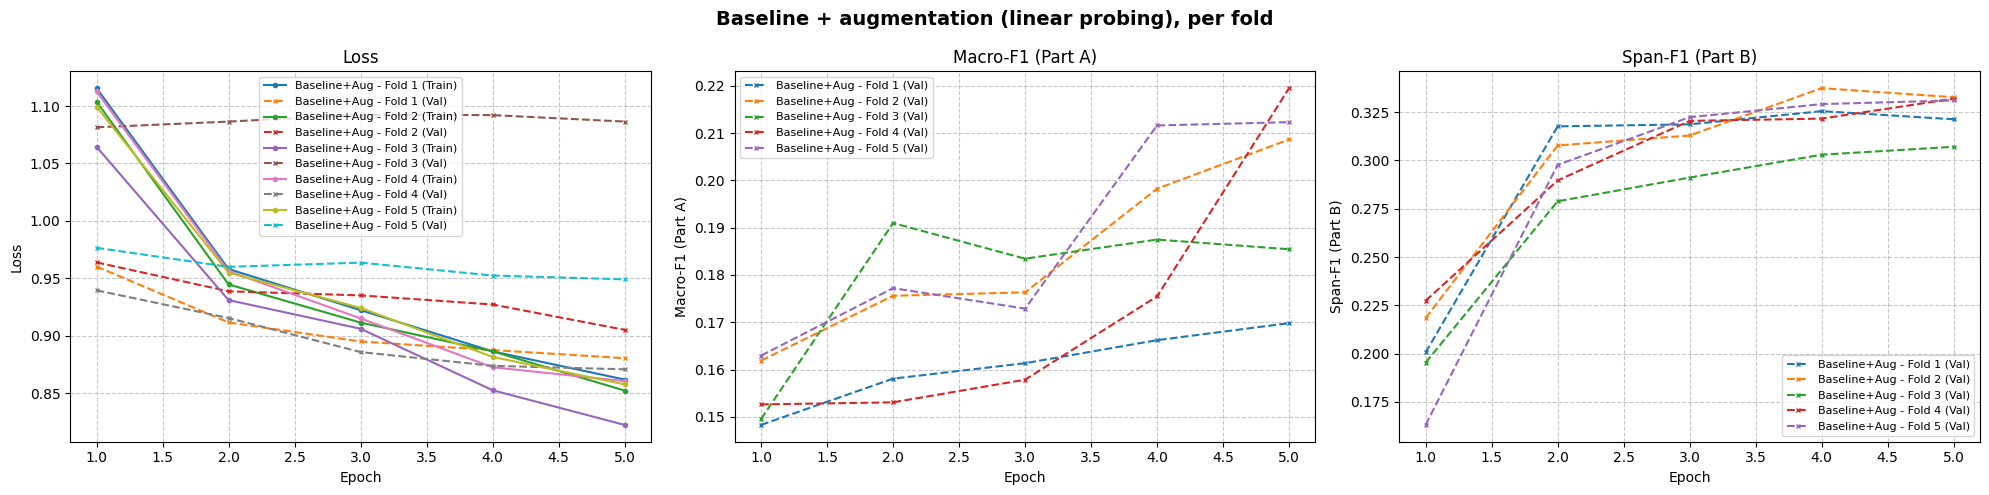

,epoch,score,macro_f1,micro_f1,span_f1,thr,tok_thr
Baseline+Aug - Fold 1,4.0,0.246,0.166,0.374,0.326,0.25,0.35
Baseline+Aug - Fold 2,5.0,0.271,0.209,0.427,0.333,0.20,0.35
Baseline+Aug - Fold 3,5.0,0.246,0.185,0.212,0.307,0.10,0.40
Baseline+Aug - Fold 4,5.0,0.276,0.220,0.321,0.332,0.15,0.35
Baseline+Aug - Fold 5,5.0,0.272,0.212,0.423,0.331,0.20,0.40



--- Baseline vs Baseline + augmentation ---


,CV Macro-F1,CV Micro-F1,CV Span-F1,Test Macro-F1,Test Micro-F1,Test Span-F1
Baseline [9a],0.175 ± 0.014,0.280 ± 0.046,0.309 ± 0.014,0.159,0.273,0.356
Baseline + augmentation,0.198 ± 0.022,0.351 ± 0.089,0.326 ± 0.011,0.221,0.379,0.373


,baseline macro,+aug macro,baseline span,+aug span,Δ macro,Δ span
Fold 1,0.159,0.166,0.319,0.326,0.007,0.007
Fold 2,0.196,0.209,0.296,0.333,0.012,0.037
Fold 3,0.169,0.185,0.293,0.307,0.016,0.015
Fold 4,0.169,0.220,0.319,0.332,0.050,0.013
Fold 5,0.181,0.212,0.321,0.331,0.031,0.010


Δ Macro-F1 (+aug − baseline): mean +0.023, better in 5/5 folds
Δ Span-F1  (+aug − baseline): mean +0.016, better in 5/5 folds


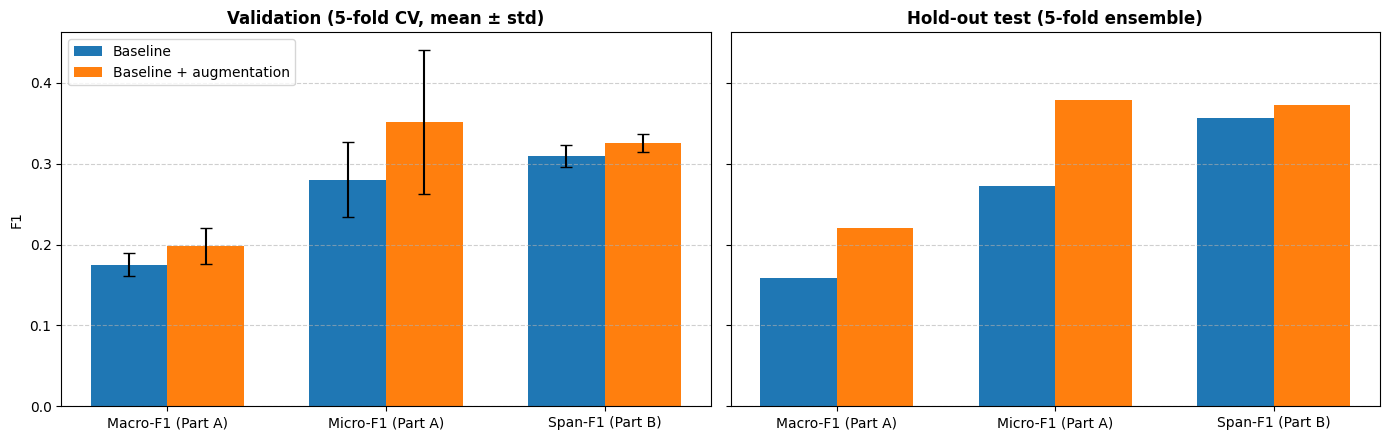

USE_AUG = True | USE_PTC = False (decided in [PTC-6])


In [31]:
#[9a-2] Baseline + augmentation: same linear probing as [9a], plus augmented copies of the training memes

from torch.utils.data import ConcatDataset

print(f"Baseline + augmentation: frozen RoBERTa + RoBERTa heads | λ={BASELINE_LAM}, pooling={BASELINE_POOLING}, "
      f"lr={PROBE_LR}, epochs≤{PROBE_EPOCHS}")
baseline_aug_res = run_kfold_probe(tag="Baseline+Aug", use_aug=True)

all_results.update(baseline_aug_res["fold_histories"])
plot_experiments(baseline_aug_res["fold_histories"], title="Baseline + augmentation (linear probing), per fold")

bla_fold_df = pd.DataFrame(baseline_aug_res["fold_results"]).T
bla_test = baseline_aug_res["test_res"]
bla_per_fold = pd.DataFrame(baseline_aug_res["per_fold_test"]).T
display(bla_fold_df.round(3))

results_scores["Baseline + augmentation (linear probe)"] = {
    "macro_f1": bla_test["macro_f1"], "micro_f1": bla_test["micro_f1"],
    "accuracy": bla_test["accuracy"], "exact_match": bla_test["exact_match"], "span_f1": bla_test["span_f1"],
}

# ------------------------------------------------------------------------------
# Comparison: baseline vs baseline + augmentation
# ------------------------------------------------------------------------------
def cv_test_row(fold_df, test_res):
    return {
        "CV Macro-F1": f"{fold_df['macro_f1'].mean():.3f} ± {fold_df['macro_f1'].std():.3f}",
        "CV Micro-F1": f"{fold_df['micro_f1'].mean():.3f} ± {fold_df['micro_f1'].std():.3f}",
        "CV Span-F1":  f"{fold_df['span_f1'].mean():.3f} ± {fold_df['span_f1'].std():.3f}",
        "Test Macro-F1": round(test_res["macro_f1"], 3),
        "Test Micro-F1": round(test_res["micro_f1"], 3),
        "Test Span-F1":  round(test_res["span_f1"], 3),
    }

print("\n--- Baseline vs Baseline + augmentation ---")
display(pd.DataFrame({"Baseline [9a]": cv_test_row(bl_fold_df, bl_test),
                      "Baseline + augmentation": cv_test_row(bla_fold_df, bla_test)}).T)

#paired fold-by-fold (same validation folds, original memes only)
paired_aug = pd.DataFrame({
    "baseline macro": bl_fold_df["macro_f1"].values, "+aug macro": bla_fold_df["macro_f1"].values,
    "baseline span":  bl_fold_df["span_f1"].values,  "+aug span":  bla_fold_df["span_f1"].values,
}, index=[f"Fold {k+1}" for k in range(len(bla_fold_df))])
paired_aug["Δ macro"] = paired_aug["+aug macro"] - paired_aug["baseline macro"]
paired_aug["Δ span"] = paired_aug["+aug span"] - paired_aug["baseline span"]
display(paired_aug.round(3))
print(f"Δ Macro-F1 (+aug − baseline): mean {paired_aug['Δ macro'].mean():+.3f}, "
      f"better in {(paired_aug['Δ macro'] > 0).sum()}/{len(paired_aug)} folds")
print(f"Δ Span-F1  (+aug − baseline): mean {paired_aug['Δ span'].mean():+.3f}, "
      f"better in {(paired_aug['Δ span'] > 0).sum()}/{len(paired_aug)} folds")

#figure: CV mean ± fold std and test, both models
metrics = [("macro_f1", "Macro-F1 (Part A)"), ("micro_f1", "Micro-F1 (Part A)"), ("span_f1", "Span-F1 (Part B)")]
x, w = np.arange(len(metrics)), 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for j, (name, fdf, tres) in enumerate([("Baseline", bl_fold_df, bl_test), ("Baseline + augmentation", bla_fold_df, bla_test)]):
    axes[0].bar(x + (j - 0.5) * w, [fdf[m].mean() for m, _ in metrics], w,
                yerr=[fdf[m].std() for m, _ in metrics], capsize=4, label=name)
    axes[1].bar(x + (j - 0.5) * w, [tres[m] for m, _ in metrics], w, label=name)
for ax, title in zip(axes, ["Validation (5-fold CV, mean ± std)", "Hold-out test (5-fold ensemble)"]):
    ax.set_xticks(x); ax.set_xticklabels([lbl for _, lbl in metrics])
    ax.set_title(title, fontsize=12, fontweight="bold"); ax.grid(axis="y", linestyle="--", alpha=0.6)
axes[0].set_ylabel("F1"); axes[0].legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Decisions used by every later training run
# ------------------------------------------------------------------------------
#augmentation improved CV Macro-F1 in 5/5 folds (mean +0.025, larger than the fold std of 0.014)
USE_AUG = True

#PTC subset: off until [PTC-6] tests it (that cell overwrites this value)
USE_PTC = False

print(f"USE_AUG = {USE_AUG} | USE_PTC = {USE_PTC} (decided in [PTC-6])")

In [32]:
#[PTC-1] PTC corpus (SemEval-2020 Task 11, news articles): articles + technique spans
PTC_ARTICLES_DIR = "PTC-data/train-articles"
PTC_LABELS_FILE = "PTC-data/train-task2-TC.labels"

ptc_labels = pd.read_csv(PTC_LABELS_FILE, sep="\t", header=None,
                         names=["article_id", "label", "start", "end"], dtype={"article_id": str})
print(ptc_labels["label"].value_counts())        #check the exact PTC label names before mapping

ptc_articles = {}
for fp in glob.glob(os.path.join(PTC_ARTICLES_DIR, "article*.txt")):
    aid = os.path.basename(fp).replace("article", "").replace(".txt", "")
    with open(fp, encoding="utf-8") as f:
        ptc_articles[aid] = f.read()

#sanity checks: every labelled article exists and every span lies inside its article
missing = set(ptc_labels["article_id"]) - set(ptc_articles)
out_of_range = sum(r.end > len(ptc_articles.get(r.article_id, "")) for r in ptc_labels.itertuples())
print(f"Articles: {len(ptc_articles)} | spans: {len(ptc_labels)} | "
      f"labelled articles missing: {len(missing)} | spans out of range: {out_of_range}")

ptc_labels["extracted_text"] = [ptc_articles[r.article_id][r.start:r.end] if r.article_id in ptc_articles else ""
                                for r in ptc_labels.itertuples()]
display(ptc_labels.head())


label
Loaded_Language                       2123
Name_Calling,Labeling                 1058
Repetition                             621
Doubt                                  493
Exaggeration,Minimisation              466
Appeal_to_fear-prejudice               294
Flag-Waving                            229
Causal_Oversimplification              209
Appeal_to_Authority                    144
Slogans                                129
Whataboutism,Straw_Men,Red_Herring     108
Black-and-White_Fallacy                107
Thought-terminating_Cliches             76
Bandwagon,Reductio_ad_hitlerum          72
Name: count, dtype: int64
Articles: 371 | spans: 6129 | labelled articles missing: 0 | spans out of range: 0


,article_id,label,start,end,extracted_text
0,111111111,Appeal_to_Authority,265,323,The next transmission could be more pronounced...
1,111111111,Appeal_to_Authority,1795,1935,when (the plague) comes again it starts from m...
2,111111111,Doubt,149,157,appeared
3,111111111,Repetition,1069,1091,"a very, very different"
4,111111111,Appeal_to_fear-prejudice,1334,1462,He also pointed to the presence of the pneumon...


In [33]:
#[PTC-2] map PTC's 14 classes onto our 20 techniques
#merged PTC classes that cover SEVERAL of our techniques are ambiguous (we cannot tell which one),
#so they are dropped, and techniques PTC cannot label are masked (not treated as absent) for PTC rows
PTC_TO_OURS = {
    "Appeal_to_Authority":         "Appeal to authority",
    "Appeal_to_fear-prejudice":    "Appeal to fear/prejudice",
    "Black-and-White_Fallacy":     "Black-and-white Fallacy/Dictatorship",
    "Causal_Oversimplification":   "Causal Oversimplification",
    "Doubt":                       "Doubt",
    "Exaggeration,Minimisation":   "Exaggeration/Minimisation",
    "Flag-Waving":                 "Flag-waving",
    "Loaded_Language":             "Loaded Language",
    "Name_Calling,Labeling":       "Name calling/Labeling",
    "Repetition":                  "Repetition",
    "Slogans":                     "Slogans",
    "Thought-terminating_Cliches": "Thought-terminating cliché",
}
PTC_AMBIGUOUS = {"Whataboutism,Straw_Men,Red_Herring", "Bandwagon,Reductio_ad_hitlerum"}

unknown = set(ptc_labels["label"]) - set(PTC_TO_OURS) - PTC_AMBIGUOUS
assert not unknown, f"PTC labels not handled: {unknown}"
assert set(PTC_TO_OURS.values()) <= set(TECHNIQUES), set(PTC_TO_OURS.values()) - set(TECHNIQUES)

PTC_MASKED = [t for t in TECHNIQUES if t not in set(PTC_TO_OURS.values())]
print(f"Techniques PTC can label: {len(TECHNIQUES) - len(PTC_MASKED)} | masked for PTC rows: {PTC_MASKED}")


Techniques PTC can label: 12 | masked for PTC rows: ['Bandwagon', 'Glittering generalities (Virtue)', "Misrepresentation of Someone's Position (Straw Man)", 'Obfuscation, Intentional vagueness, Confusion', 'Presenting Irrelevant Data (Red Herring)', 'Reductio ad hitlerum', 'Smears', 'Whataboutism']


In [34]:
#[PTC-3] split articles into sentences; keep each sentence's spans relative to the sentence
nltk.download("punkt_tab", quiet=True)
try:
    sent_tokenizer = nltk.tokenize.PunktTokenizer("english")             #pretrained English model (NLTK >= 3.8.2)
except AttributeError:
    sent_tokenizer = nltk.data.load("tokenizers/punkt/english.pickle")   #older NLTK

labels_by_article = {aid: g for aid, g in ptc_labels.groupby("article_id")}
rows = []
for aid, text in ptc_articles.items():
    labs = labels_by_article.get(aid, ptc_labels.iloc[:0])
    for s0, s1 in sent_tokenizer.span_tokenize(text):
        sentence = text[s0:s1]
        if not sentence.strip():
            continue
        spans, ambiguous = [], False
        for r in labs.itertuples():
            a, b = max(s0, r.start), min(s1, r.end)           #part of the span inside this sentence
            if a < b:
                if r.label in PTC_AMBIGUOUS:
                    ambiguous = True
                    continue
                spans.append((a - s0, b - s0, PTC_TO_OURS[r.label]))
        rows.append({"article_id": aid, "text": sentence, "spans": spans,
                     "doc_labels": sorted({t for _, _, t in spans}), "has_ambiguous": ambiguous})

ptc_sent = pd.DataFrame(rows)

#remove duplicate sentences (repeated boilerplate across articles) and any sentence identical to a meme
ptc_sent["text_key"] = ptc_sent["text"].str.replace(r"\s+", " ", regex=True).str.strip().str.lower()
ptc_sent = ptc_sent.drop_duplicates("text_key").reset_index(drop=True)
meme_keys = set(df2["text"].str.replace(r"\s+", " ", regex=True).str.strip().str.lower())
overlap = ptc_sent["text_key"].isin(meme_keys)
ptc_sent = ptc_sent[~overlap].reset_index(drop=True)

n_pos = (ptc_sent["doc_labels"].map(len) > 0).sum()
print(f"PTC sentences: {len(ptc_sent)} | with a mapped technique: {n_pos} | without: {len(ptc_sent) - n_pos} | "
      f"identical to a meme (removed): {int(overlap.sum())}")
display(ptc_sent[ptc_sent["doc_labels"].map(len) > 0].head())

#counts per technique: memes vs PTC sentences (masked techniques shown as '—')
Y_ptc = np.array([[1.0 if t in d else 0.0 for t in TECHNIQUES] for d in ptc_sent["doc_labels"]], dtype=np.float32)
count_table = pd.DataFrame({"memes": Y.sum(0).astype(int), "PTC sentences": Y_ptc.sum(0).astype(int)}, index=TECHNIQUES)
count_table.loc[PTC_MASKED, "PTC sentences"] = "—"
display(count_table)

PTC sentences: 14553 | with a mapped technique: 4475 | without: 10078 | identical to a meme (removed): 0


,article_id,text,spans,doc_labels,has_ambiguous,text_key
0,111111111,Next plague outbreak in Madagascar could be 's...,"[(149, 157, Doubt)]",[Doubt],False,next plague outbreak in madagascar could be 's...
1,111111111,"""The next transmission could be more pronounce...","[(1, 59, Appeal to authority)]",[Appeal to authority],False,"""the next transmission could be more pronounce..."
6,111111111,"But Tedros voiced alarm that ""plague in Madaga...","[(62, 84, Repetition)]",[Repetition],False,"but tedros voiced alarm that ""plague in madaga..."
9,111111111,He also pointed to the presence of the pneumon...,"[(0, 128, Appeal to fear/prejudice)]",[Appeal to fear/prejudice],False,he also pointed to the presence of the pneumon...
10,111111111,He praised the rapid response from WHO and Mad...,"[(112, 151, Appeal to fear/prejudice)]",[Appeal to fear/prejudice],False,he praised the rapid response from who and mad...


,memes,PTC sentences
Appeal to authority,13,168
Appeal to fear/prejudice,43,320
Bandwagon,2,—
Black-and-white Fallacy/Dictatorship,18,116
Causal Oversimplification,27,242
Doubt,48,600
Exaggeration/Minimisation,52,440
Flag-waving,27,227
Glittering generalities (Virtue),32,—
Loaded Language,358,1841


In [35]:
#[PTC-4] select a small, targeted PTC subset (after [PTC-1]-[PTC-3])
#goal: add examples of the techniques that are RARE in the memes, in meme-like short sentences,
#without letting news text outnumber the memes

PTC_TARGET_PER_TECHNIQUE = 60   #top each mapped technique up to ~60 examples (memes + PTC)
PTC_MAX_TOTAL = 250             #hard cap on PTC positives (~half of one fold's ~470 training memes)
PTC_NEG_FRAC = 0.2              #plus a few PTC sentences with no technique (20% of the positives)
PTC_MIN_TOK, PTC_MAX_TOK = 8, 64   #meme-like length (memes: median ~29 RoBERTa tokens)

rng = np.random.default_rng(SEED)

#length filter in RoBERTa tokens (same tokenizer as the memes)
ptc_sent["n_tok"] = [len(tokenizer(t, add_special_tokens=True)["input_ids"]) for t in ptc_sent["text"]]
cand = ptc_sent[(ptc_sent["n_tok"] >= PTC_MIN_TOK) & (ptc_sent["n_tok"] <= PTC_MAX_TOK)
                & (~ptc_sent["has_ambiguous"])].copy()

#how many memes (train+val only, never test) already have each technique
meme_counts = pd.Series(Y[idx_cv].sum(0).astype(int), index=TECHNIQUES)
mapped = [t for t in TECHNIQUES if t not in PTC_MASKED]

#quota per technique: only top up techniques the memes are short of (Loaded Language / Name calling get 0)
quota = {t: max(0, PTC_TARGET_PER_TECHNIQUE - int(meme_counts[t])) for t in mapped}

#greedy selection, rarest-in-memes technique first
selected, got = set(), {t: 0 for t in mapped}
for t in sorted(mapped, key=lambda t: meme_counts[t]):
    if quota[t] == 0:
        continue
    pool = [i for i in cand.index[cand["doc_labels"].map(lambda d: t in d)] if i not in selected]
    rng.shuffle(pool)
    for i in pool:
        if got[t] >= quota[t] or len(selected) >= PTC_MAX_TOTAL:
            break
        selected.add(i)
        for lab in cand.at[i, "doc_labels"]:
            got[lab] += 1

#a few PTC sentences with no mapped technique, so the model also sees "no technique" news text
neg_pool = cand.index[(cand["doc_labels"].map(len) == 0)].to_numpy()
n_neg = min(len(neg_pool), int(PTC_NEG_FRAC * len(selected)))
neg_sel = set(rng.choice(neg_pool, size=n_neg, replace=False)) if n_neg else set()

ptc_subset = ptc_sent.loc[sorted(selected | neg_sel)].reset_index(drop=True)
print(f"PTC subset: {len(selected)} sentences with a technique + {len(neg_sel)} without = {len(ptc_subset)} "
      f"(from {len(ptc_sent)} PTC sentences; ~{len(idx_cv) * 4 // 5} original training memes per fold)")

Y_ptc_sub = np.array([[1.0 if t in d else 0.0 for t in TECHNIQUES] for d in ptc_subset["doc_labels"]], dtype=np.float32)
sel_table = pd.DataFrame({"memes (train+val)": meme_counts,
                          "PTC added": Y_ptc_sub.sum(0).astype(int),
                          "quota": [quota.get(t, "masked") for t in TECHNIQUES]})
sel_table["total"] = sel_table["memes (train+val)"] + sel_table["PTC added"]
sel_table.loc[PTC_MASKED, ["PTC added", "total"]] = "—"
display(sel_table.sort_values("memes (train+val)"))

PTC subset: 250 sentences with a technique + 50 without = 300 (from 14553 PTC sentences; ~468 original training memes per fold)


,memes (train+val),PTC added,quota,total
Presenting Irrelevant Data (Red Herring),1,—,masked,—
Bandwagon,2,—,masked,—
"Obfuscation, Intentional vagueness, Confusion",3,—,masked,—
Repetition,7,60,53,67
Reductio ad hitlerum,8,—,masked,—
Appeal to authority,11,49,49,60
Black-and-white Fallacy/Dictatorship,15,45,45,60
Misrepresentation of Someone's Position (Straw Man),17,—,masked,—
Thought-terminating cliché,17,43,43,60
Causal Oversimplification,23,37,37,60


In [36]:
#[PTC-5] PTC dataset with "unknown" (-1) for the techniques PTC cannot label
#-1 = unknown -> excluded from the loss (NOT a negative); memes never contain -1, so they are unaffected
masked_idx = [label2id[t] for t in PTC_MASKED]

ptc_dataset = TwoHeadDataset(ptc_subset["text"].tolist(), ptc_subset["spans"].tolist(), Y_ptc_sub, tokenizer)
ptc_dataset.doc_labels[:, masked_idx] = -1.0
real_tok = ptc_dataset.tok_labels[:, :, 0] != -100                 #real (non-special, non-padding) tokens
for k in masked_idx:
    ptc_dataset.tok_labels[:, :, k][real_tok] = -1.0
print(f"PTC dataset: {len(ptc_dataset)} sentences | masked techniques per row: {len(masked_idx)}")


PTC dataset: 300 sentences | masked techniques per row: 8


In [37]:
#[PTC-6] baseline + augmentation vs baseline + augmentation + PTC subset (same folds, frozen RoBERTa)
ptc_res = run_kfold_probe(tag="Baseline+Aug+PTC", use_aug=True, use_ptc=True, verbose=False)
blp_fold_df = pd.DataFrame(ptc_res["fold_results"]).T
blp_test = ptc_res["test_res"]

display(pd.DataFrame({"Baseline + aug": cv_test_row(bla_fold_df, bla_test),
                      "Baseline + aug + PTC subset": cv_test_row(blp_fold_df, blp_test)}).T)

d_macro = blp_fold_df["macro_f1"].values - bla_fold_df["macro_f1"].values
d_span = blp_fold_df["span_f1"].values - bla_fold_df["span_f1"].values
print(f"Δ Macro-F1 (+PTC): mean {d_macro.mean():+.3f}, better in {(d_macro > 0).sum()}/5 folds")
print(f"Δ Span-F1  (+PTC): mean {d_span.mean():+.3f}, better in {(d_span > 0).sum()}/5 folds")

USE_PTC = bool(d_macro.mean() > bla_fold_df["macro_f1"].std() and (d_macro > 0).sum() >= 4)
print(f"✅ Use the PTC subset for the rest of the experiments: {USE_PTC}")

,CV Macro-F1,CV Micro-F1,CV Span-F1,Test Macro-F1,Test Micro-F1,Test Span-F1
Baseline + aug,0.198 ± 0.022,0.351 ± 0.089,0.326 ± 0.011,0.221,0.379,0.373
Baseline + aug + PTC subset,0.197 ± 0.012,0.323 ± 0.044,0.248 ± 0.016,0.199,0.337,0.295


Δ Macro-F1 (+PTC): mean -0.002, better in 2/5 folds
Δ Span-F1  (+PTC): mean -0.077, better in 0/5 folds
✅ Use the PTC subset for the rest of the experiments: False


External data (PTC, SemEval-2020 Task 11). Following MinD (Dimitrov et al., 2021), was utilized by adding a small, targeted subset of the PTC news corpus (300 sentences: techniques under represented in the memes, meme-length sentences, 8 techniques PTC cannot label masked out of the loss). On the same five folds it did not change Part A (Macro-F1 −0.002, better in 2/5 folds) and showed decrease in Part B (span F1 −0.077, worse in 5/5 folds; test span F1 0.373 → 0.295).
This shows that the langauge structure of PTC which are articles that are large paragraphs of information are not aligned with memes. There fore most probably the poor result is attributed to an annotation style mismatch: PTC is relative to the whole article and uses longer spans for clause level techniques, so its token labels teach span boundaries that do not match the memes. PTC is therefore not used in the final model. The comparison was run with a frozen encoder; we did not re-test it with fine-tuning.

In [38]:
#[PTC-7] PTC subset for the doc head only (token labels masked, like the augmented memes)
ptc_dataset_full = ptc_dataset                                   #keep the original
ptc_dataset = copy.deepcopy(ptc_dataset_full)
ptc_dataset.tok_labels[:] = -100

ptc_doc_res = run_kfold_probe(tag="Baseline+Aug+PTCdoc", use_aug=True, use_ptc=True, verbose=False)
pdoc_fold_df = pd.DataFrame(ptc_doc_res["fold_results"]).T
d_macro2 = pdoc_fold_df["macro_f1"].values - bla_fold_df["macro_f1"].values
d_span2 = pdoc_fold_df["span_f1"].values - bla_fold_df["span_f1"].values
print(f"PTC doc-only | Δ Macro-F1: {d_macro2.mean():+.3f} ({(d_macro2 > 0).sum()}/5 folds) | "
      f"Δ Span-F1: {d_span2.mean():+.3f} ({(d_span2 > 0).sum()}/5 folds)")

USE_PTC = bool(d_macro2.mean() > bla_fold_df["macro_f1"].std() and (d_macro2 > 0).sum() >= 4)
if not USE_PTC:
    ptc_dataset = ptc_dataset_full                               #restore; it is not used anyway
print(f"✅ Use the PTC subset (doc head only): {USE_PTC}")

PTC doc-only | Δ Macro-F1: -0.003 (2/5 folds) | Δ Span-F1: -0.003 (2/5 folds)
✅ Use the PTC subset (doc head only): False


### k-fold two head training function
* `run_kfold_twohead` runs two training phases for each fold. Phase 1 trains the two heads, and Phase 2 trains with the heads. The function then returns the validation results. Using the same function for both the hyperparameter searches and the final model keeps the training process consistent.


In [27]:
#[9b] two-phase training function (Phase 2 = full fine-tuning of RoBERTa + heads)
from transformers import get_linear_schedule_with_warmup


def run_kfold_twohead(lam=1.0, pooling="cls", p1_epochs=P1_EPOCHS, p2_epochs=P2_EPOCHS,
                           patience=PATIENCE, encoder_lr=2e-5, head_lr=1e-4, weight_decay=0.01,
                           warmup_frac=0.1, max_folds=K_FOLDS, tag="TwoHeadFull", verbose=True, use_aug=None, use_ptc=None):
    if use_aug is None:
        use_aug = USE_AUG       #decided in [9a-2]
    if use_ptc is None:
        use_ptc = USE_PTC       #decided in [PTC-6]
    
    fold_results, fold_states, fold_histories = {}, [], {}

    for fold, (train_idx, val_idx) in enumerate(cv_splits[:max_folds]):
        if verbose:
            print(f"\n========== {tag} | FOLD {fold + 1}/{max_folds} ==========")
        set_seed(SEED + fold)

        train_loader = DataLoader(make_train_dataset(train_idx, use_aug, use_ptc), batch_size=BATCH_SIZE, shuffle=True,
                                  generator=torch.Generator().manual_seed(SEED + fold))
        
        val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)
        val_gold = [GOLD_SPANS[i] for i in val_idx]

        model = build_two_head_model(pooling=pooling)
        doc_pw, tok_pw = fold_pos_weights(train_idx)
        model.set_loss_weights(doc_pw, tok_pw, lam)

        # ==========================================
        # PHASE 1: HEADS ONLY (encoder frozen)
        # ==========================================
        for p in model.roberta.parameters():
            p.requires_grad = False
        probe_optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
        run_experiment(model, probe_optimizer, train_loader, val_loader, val_gold,
                       epochs=p1_epochs, patience=p1_epochs, name=f"{tag}_F{fold+1}_P1", verbose=verbose)

        # ==========================================
        # PHASE 2: FULL FINE-TUNING (encoder + heads)
        # ==========================================
        torch.cuda.empty_cache()
        gc.collect()
        for p in model.roberta.parameters():
            p.requires_grad = True

        #small learning rate for the pretrained encoder, larger for the heads
        encoder_params = [p for n, p in model.named_parameters() if n.startswith("roberta.")]
        head_params = [p for n, p in model.named_parameters() if not n.startswith("roberta.")]
        ft_optimizer = optim.AdamW([{"params": encoder_params, "lr": encoder_lr},
                                    {"params": head_params, "lr": head_lr}],
                                   weight_decay=weight_decay)

        #linear warm-up then decay (stepped every batch inside train_one_epoch)
        total_steps = p2_epochs * len(train_loader)
        scheduler = get_linear_schedule_with_warmup(ft_optimizer, int(warmup_frac * total_steps), total_steps)

        history, best_info = run_experiment(model, ft_optimizer, train_loader, val_loader, val_gold,
                                            epochs=p2_epochs, patience=patience,
                                            name=f"{tag}_F{fold+1}_Full", scheduler=scheduler, verbose=verbose)

        fold_name = f"{tag} - Fold {fold+1}"
        fold_histories[fold_name] = {"history": history, "best_info": best_info}
        fold_results[fold_name] = {k: best_info[k] for k in ["epoch", "score", "macro_f1", "micro_f1",
                                                            "span_f1", "thr", "tok_thr"]}
        #best_info["state"] now holds ALL weights (encoder + heads)
        fold_states.append(best_info["state"])

        del model, probe_optimizer, ft_optimizer, scheduler, train_loader, val_loader
        torch.cuda.empty_cache()
        gc.collect()

    summary = {k: float(np.mean([r[k] for r in fold_results.values()])) for k in ["score", "macro_f1", "micro_f1", "span_f1"]}
    return {"summary": summary, "fold_results": fold_results, "fold_states": fold_states,
            "fold_histories": fold_histories,
            "config": dict(finetune="full", lam=lam, pooling=pooling, encoder_lr=encoder_lr,
                           head_lr=head_lr, weight_decay=weight_decay, warmup_frac=warmup_frac, use_aug=use_aug, use_ptc=use_ptc)}

Default two-phase model | λ=1.0, pooling=cls, Phase 1 epochs=5, Phase 2 epochs≤5 (full fine-tuning)

========== Default | FOLD 1/5 ==========
[Default_F1_P1] Epoch   1/5 | Train Loss: 1.1650 (doc 0.5724, tok 0.5927) | Val Loss: 0.9906 | Val Macro-F1: 0.142 | Val Micro-F1: 0.172 | Val Span-F1: 0.107 | Thr: 0.05/0.35
[Default_F1_P1] Epoch   5/5 | Train Loss: 0.9079 (doc 0.4999, tok 0.4080) | Val Loss: 0.8993 | Val Macro-F1: 0.159 | Val Micro-F1: 0.228 | Val Span-F1: 0.319 | Thr: 0.15/0.35
[Default_F1_Full] Epoch   1/5 | Train Loss: 0.8358 (doc 0.4588, tok 0.3771) | Val Loss: 0.8286 | Val Macro-F1: 0.206 | Val Micro-F1: 0.442 | Val Span-F1: 0.307 | Thr: 0.30/0.40
[Default_F1_Full] Epoch   5/5 | Train Loss: 0.4546 (doc 0.2389, tok 0.2157) | Val Loss: 0.8500 | Val Macro-F1: 0.291 | Val Micro-F1: 0.491 | Val Span-F1: 0.347 | Thr: 0.35/0.50

========== Default | FOLD 2/5 ==========
[Default_F2_P1] Epoch   1/5 | Train Loss: 1.1771 (doc 0.5805, tok 0.5965) | Val Loss: 1.0256 | Val Macro-F1: 0.1

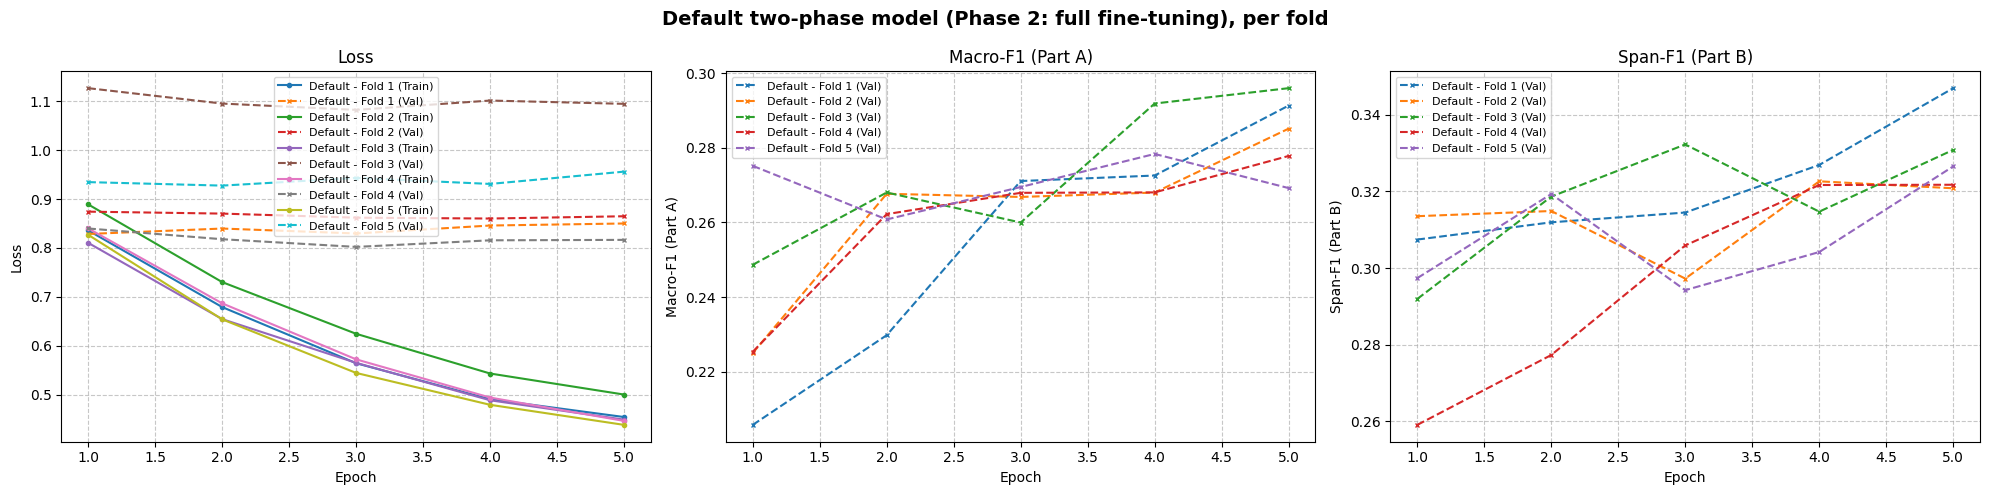

,epoch,score,macro_f1,micro_f1,span_f1,thr,tok_thr
Default - Fold 1,5.0,0.319,0.291,0.491,0.347,0.35,0.5
Default - Fold 2,5.0,0.303,0.285,0.454,0.321,0.25,0.5
Default - Fold 3,5.0,0.313,0.296,0.470,0.331,0.45,0.5
Default - Fold 4,5.0,0.300,0.278,0.467,0.322,0.30,0.4
Default - Fold 5,5.0,0.298,0.269,0.448,0.327,0.20,0.5



--- Baseline vs Default two-phase model ---


,CV Macro-F1,CV Micro-F1,CV Span-F1,Test Macro-F1,Test Macro-F1 (all 20),Test Micro-F1,Test Span-F1,Test Span P / R,Per-fold test Macro-F1
Baseline: frozen RoBERTa (≤5 epochs),0.175 ± 0.014,0.280 ± 0.046,0.309 ± 0.014,0.159,0.143,0.273,0.356,0.291 / 0.460,0.174 ± 0.023
Default: + full fine-tuning (Phase 2),0.284 ± 0.011,0.466 ± 0.017,0.329 ± 0.011,0.351,0.316,0.532,0.389,0.401 / 0.378,0.296 ± 0.008


,baseline macro,default macro,baseline span,default span,Δ macro,Δ span
Fold 1,0.159,0.291,0.319,0.347,0.132,0.028
Fold 2,0.196,0.285,0.296,0.321,0.089,0.025
Fold 3,0.169,0.296,0.293,0.331,0.127,0.038
Fold 4,0.169,0.278,0.319,0.322,0.109,0.002
Fold 5,0.181,0.269,0.321,0.327,0.088,0.005


Δ Macro-F1: mean +0.109, improved in 5/5 folds
Δ Span-F1:  mean +0.020, improved in 5/5 folds


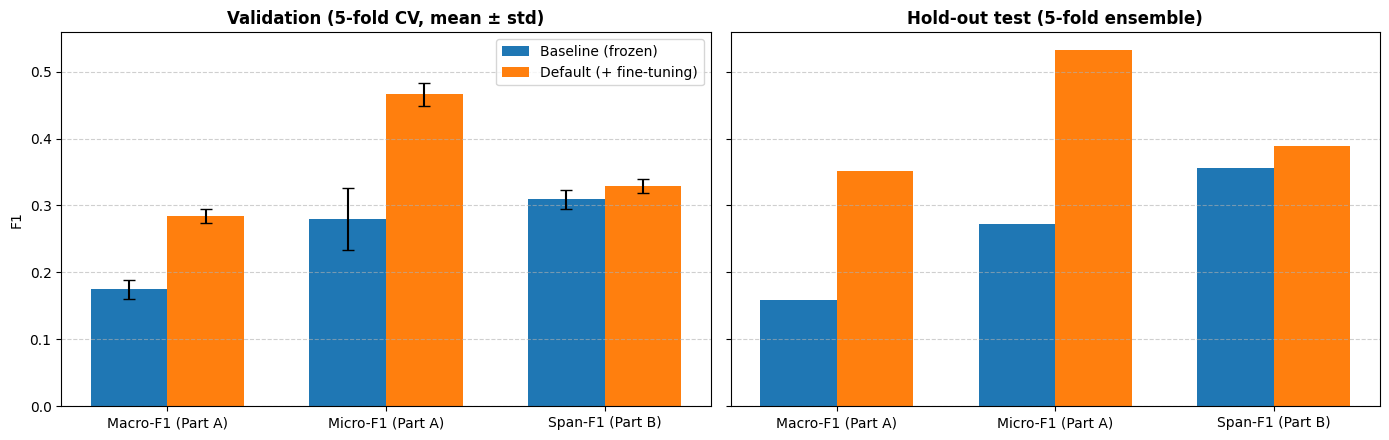

In [28]:
#[9c] default two-phase model (full fine-tuning) vs the linear-probing baseline, same defaults

#like-for-like: the baseline arm is [9a-2] (frozen RoBERTa + augmentation), because the runs below also train
#on the augmented copies (USE_AUG). Comparing with [9a] (no augmentation) would mix two changes into one Δ.
if USE_PTC:
    print("⚠️ USE_PTC is True but [9a-2] was trained without PTC: re-run the probe with PTC for a like-for-like baseline.")


# ------------------------------------------------------------------------------
# 1. Train with the same defaults as the baseline
# ------------------------------------------------------------------------------
print(f"Default two-phase model | λ={BASELINE_LAM}, pooling={BASELINE_POOLING}, "
      f"Phase 1 epochs={P1_EPOCHS}, Phase 2 epochs≤{P2_EPOCHS} (full fine-tuning)")
default_res = run_kfold_twohead(lam=BASELINE_LAM, pooling=BASELINE_POOLING, tag="Default")

all_results.update(default_res["fold_histories"])
plot_experiments(default_res["fold_histories"], title="Default two-phase model (Phase 2: full fine-tuning), per fold")

def_fold_df = pd.DataFrame(default_res["fold_results"]).T
display(def_fold_df.round(3))


# ------------------------------------------------------------------------------
# 2. Test evaluation: each fold model + 5-fold ensemble (reporting only)
# ------------------------------------------------------------------------------
def evaluate_folds_on_test(res, pooling):
    test_loader_cmp = DataLoader(Subset(full_dataset, idx_test), batch_size=BATCH_SIZE, shuffle=False)
    test_gold_cmp = [GOLD_SPANS[i] for i in idx_test]
    n = len(res["fold_states"])
    per_fold, ens_doc, ens_tok = {}, None, None

    for k, (state, fr) in enumerate(zip(res["fold_states"], res["fold_results"].values())):
        model = build_two_head_model(pooling=pooling)
        load_info = model.load_state_dict(state, strict=False)
        assert not load_info.unexpected_keys, load_info.unexpected_keys[:5]
        model.eval()

        r = evaluate_model(model, test_loader_cmp, test_gold_cmp, threshold=fr["thr"], tok_threshold=fr["tok_thr"])
        per_fold[f"Fold {k+1}"] = {"macro_f1": r["macro_f1"], "micro_f1": r["micro_f1"], "span_f1": r["span_f1"]}
        ens_doc = r["doc_probs"] / n if ens_doc is None else ens_doc + r["doc_probs"] / n
        ens_tok = [t / n for t in r["tok_probs"]] if ens_tok is None else [a + t / n for a, t in zip(ens_tok, r["tok_probs"])]
        offsets, doc_true = r["offsets"], r["doc_true"]

        del model
        torch.cuda.empty_cache()
        gc.collect()

    thr = float(np.mean([v["thr"] for v in res["fold_results"].values()]))
    tok_thr = float(np.mean([v["tok_thr"] for v in res["fold_results"].values()]))
    ens = score_predictions(doc_true, ens_doc, ens_tok, offsets, test_gold_cmp, threshold=thr, tok_threshold=tok_thr)
    return ens, pd.DataFrame(per_fold).T

def_test, def_per_fold = evaluate_folds_on_test(default_res, BASELINE_POOLING)

results_scores["Default two-phase: full fine-tuning (λ=1, cls)"] = {
    "macro_f1": def_test["macro_f1"], "micro_f1": def_test["micro_f1"],
    "accuracy": def_test["accuracy"], "exact_match": def_test["exact_match"], "span_f1": def_test["span_f1"],
}


# ------------------------------------------------------------------------------
# 3. Comparison table: baseline vs default two-phase model
# ------------------------------------------------------------------------------
def summary_row(fold_df, test_res, per_fold_test):
    return {
        "CV Macro-F1":   f"{fold_df['macro_f1'].mean():.3f} ± {fold_df['macro_f1'].std():.3f}",
        "CV Micro-F1":   f"{fold_df['micro_f1'].mean():.3f} ± {fold_df['micro_f1'].std():.3f}",
        "CV Span-F1":    f"{fold_df['span_f1'].mean():.3f} ± {fold_df['span_f1'].std():.3f}",
        "Test Macro-F1": round(test_res["macro_f1"], 3),
        "Test Macro-F1 (all 20)": round(float(test_res["per_class_f1"].mean()), 3),
        "Test Micro-F1": round(test_res["micro_f1"], 3),
        "Test Span-F1":  round(test_res["span_f1"], 3),
        "Test Span P / R": f"{test_res['span_precision']:.3f} / {test_res['span_recall']:.3f}",
        "Per-fold test Macro-F1": f"{per_fold_test['macro_f1'].mean():.3f} ± {per_fold_test['macro_f1'].std():.3f}",
    }

comparison = pd.DataFrame({
    f"Baseline: frozen RoBERTa (≤{PROBE_EPOCHS} epochs)": summary_row(bl_fold_df, bl_test, bl_per_fold),
    "Default: + full fine-tuning (Phase 2)": summary_row(def_fold_df, def_test, def_per_fold),
}).T
print("\n--- Baseline vs Default two-phase model ---")
display(comparison)


# ------------------------------------------------------------------------------
# 4. Paired fold-by-fold comparison (same validation folds for both models)
# ------------------------------------------------------------------------------
paired = pd.DataFrame({
    "baseline macro": bl_fold_df["macro_f1"].values, "default macro": def_fold_df["macro_f1"].values,
    "baseline span":  bl_fold_df["span_f1"].values,  "default span":  def_fold_df["span_f1"].values,
}, index=[f"Fold {k+1}" for k in range(len(def_fold_df))])
paired["Δ macro"] = paired["default macro"] - paired["baseline macro"]
paired["Δ span"] = paired["default span"] - paired["baseline span"]
display(paired.round(3))
print(f"Δ Macro-F1: mean {paired['Δ macro'].mean():+.3f}, improved in {(paired['Δ macro'] > 0).sum()}/{len(paired)} folds")
print(f"Δ Span-F1:  mean {paired['Δ span'].mean():+.3f}, improved in {(paired['Δ span'] > 0).sum()}/{len(paired)} folds")


# ------------------------------------------------------------------------------
# 5. Figure: CV (mean ± fold std) and test ensemble for both models
# ------------------------------------------------------------------------------
metrics = [("macro_f1", "Macro-F1 (Part A)"), ("micro_f1", "Micro-F1 (Part A)"), ("span_f1", "Span-F1 (Part B)")]
models = [("Baseline (frozen)", bl_fold_df, bl_test), ("Default (+ fine-tuning)", def_fold_df, def_test)]
x = np.arange(len(metrics))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for j, (name, fdf, tres) in enumerate(models):
    axes[0].bar(x + (j - 0.5) * w, [fdf[m].mean() for m, _ in metrics], w,
                yerr=[fdf[m].std() for m, _ in metrics], capsize=4, label=name)
    axes[1].bar(x + (j - 0.5) * w, [tres[m] for m, _ in metrics], w, label=name)
for ax, title in zip(axes, ["Validation (5-fold CV, mean ± std)", "Hold-out test (5-fold ensemble)"]):
    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _, lbl in metrics])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.6)
axes[0].set_ylabel("F1")
axes[0].legend()
plt.tight_layout()
plt.show()

In [29]:
#[9d] two-phase training function lora

def run_kfold_twohead_lora(lam=1.0, pooling="attn", head_hidden=256, lora_r=8, lora_dropout=0.1,
                      p1_epochs=P1_EPOCHS, p2_epochs=P2_EPOCHS, patience=PATIENCE,
                      ft_lr=1e-4, weight_decay=0.01, max_folds=K_FOLDS, tag="TwoHead", verbose=True, use_aug=None, use_ptc=None):
    if use_aug is None:
        use_aug = USE_AUG       #decided in [9a-2]
    if use_ptc is None:
        use_ptc = USE_PTC       #decided in [PTC-6]

    #λ = 0 switches the span task off: the token head is never trained, so its span F1 is noise.
    #Early stopping then uses doc Macro-F1 only, so noise does not choose the epoch ([10d] uses this run).
    es_metric = "macro_f1" if lam == 0 else "score"
    
    fold_results, fold_states, fold_histories = {}, [], {}

    for fold, (train_idx, val_idx) in enumerate(cv_splits[:max_folds]):
        if verbose:
            print(f"\n========== {tag} | FOLD {fold + 1}/{max_folds} ==========")
        set_seed(SEED + fold)

        train_loader = DataLoader(make_train_dataset(train_idx, use_aug, use_ptc), batch_size=BATCH_SIZE, shuffle=True,
                                  generator=torch.Generator().manual_seed(SEED + fold))
        
        val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)
        val_gold = [GOLD_SPANS[i] for i in val_idx]

        model = build_two_head_model(pooling=pooling, head_hidden=head_hidden)
        doc_pw, tok_pw = fold_pos_weights(train_idx)
        model.set_loss_weights(doc_pw, tok_pw, lam)

        # ==========================================
        # PHASE 1: HEADS ONLY (encoder frozen)
        # ==========================================
        for p in model.roberta.parameters():
            p.requires_grad = False
        probe_optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
        run_experiment(model, probe_optimizer, train_loader, val_loader, val_gold,
                       epochs=p1_epochs, patience=p1_epochs, name=f"{tag}_F{fold+1}_P1", verbose=verbose, es_metric=es_metric)

        # ==========================================
        # PHASE 2: LoRA ADAPTERS + HEADS
        # ==========================================
        torch.cuda.empty_cache()
        gc.collect()
        model = inject_lora(model, r=lora_r, lora_dropout=lora_dropout)
        ft_optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                   lr=ft_lr, weight_decay=weight_decay)
        history, best_info = run_experiment(model, ft_optimizer, train_loader, val_loader, val_gold,
                                            epochs=p2_epochs, patience=patience,
                                            name=f"{tag}_F{fold+1}_LoRA", verbose=verbose, es_metric=es_metric)

        fold_name = f"{tag} - Fold {fold+1}"
        fold_histories[fold_name] = {"history": history, "best_info": best_info}
        fold_results[fold_name] = {k: best_info[k] for k in ["epoch", "score", "macro_f1", "micro_f1",
                                                            "span_f1", "thr", "tok_thr"]}
        fold_states.append(best_info["state"])

        del model, probe_optimizer, ft_optimizer, train_loader, val_loader
        torch.cuda.empty_cache()
        gc.collect()

    summary = {k: float(np.mean([r[k] for r in fold_results.values()])) for k in ["score", "macro_f1", "micro_f1", "span_f1"]}
    return {"summary": summary, "fold_results": fold_results, "fold_states": fold_states,
            "fold_histories": fold_histories,
            "config": dict(lam=lam, pooling=pooling, head_hidden=head_hidden, lora_r=lora_r,
                           lora_dropout=lora_dropout, ft_lr=ft_lr, weight_decay=weight_decay, use_aug=use_aug, use_ptc=use_ptc)}


Step 2b: Tune LoRA rank (λ=1.0, pooling=cls)
r= 2: trainable 0.99M | CV Macro-F1 0.2268 | CV Span-F1 0.2907 | score 0.2587 ± 0.0155
r= 8: trainable 1.21M | CV Macro-F1 0.2573 | CV Span-F1 0.2862 | score 0.2718 ± 0.0070
r=32: trainable 2.10M | CV Macro-F1 0.2741 | CV Span-F1 0.2897 | score 0.2819 ± 0.0134

✅ Best score: r=32. Selected LoRA rank for final model: r=8 (smallest rank within one std of the best)


,trainable_params_M,macro_f1,micro_f1,span_f1,score,score_std
r=2,0.9908,0.2268,0.3879,0.2907,0.2587,0.0155
r=8,1.2119,0.2573,0.4315,0.2862,0.2718,0.0070
r=32,2.0967,0.2741,0.4488,0.2897,0.2819,0.0134


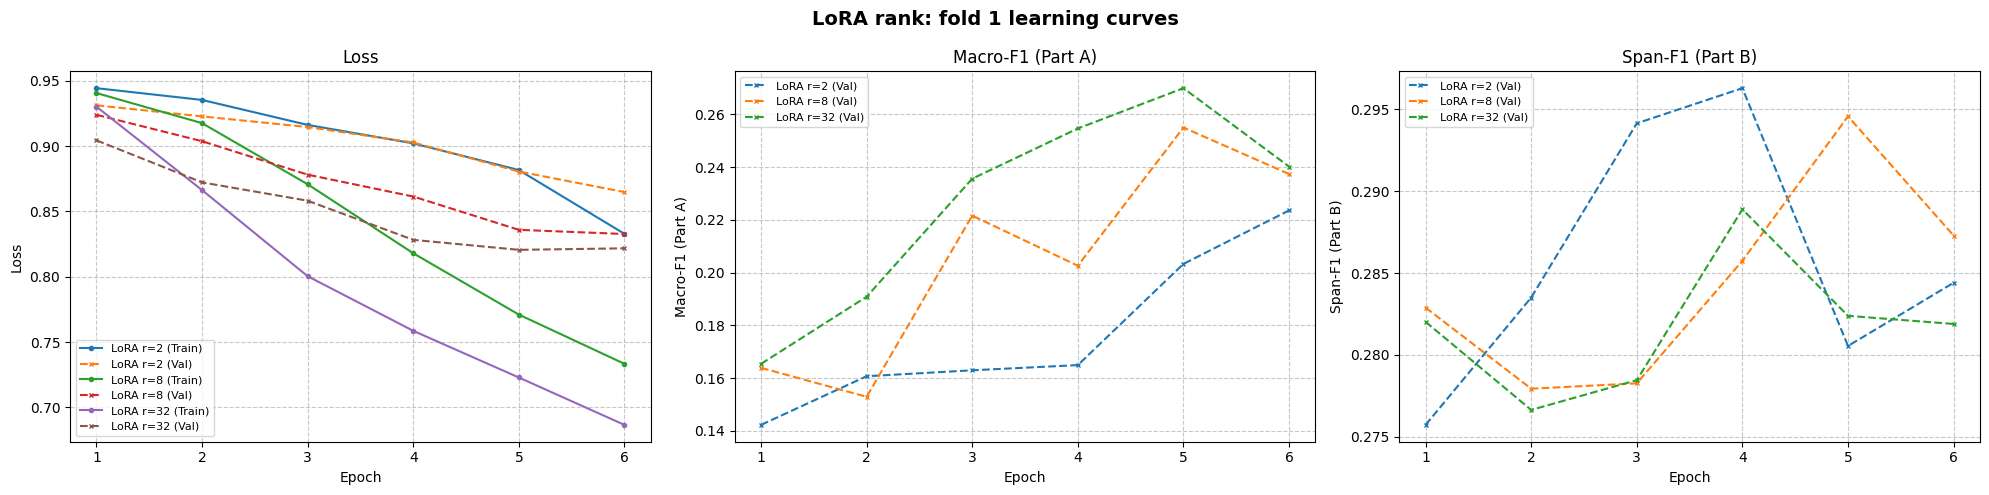

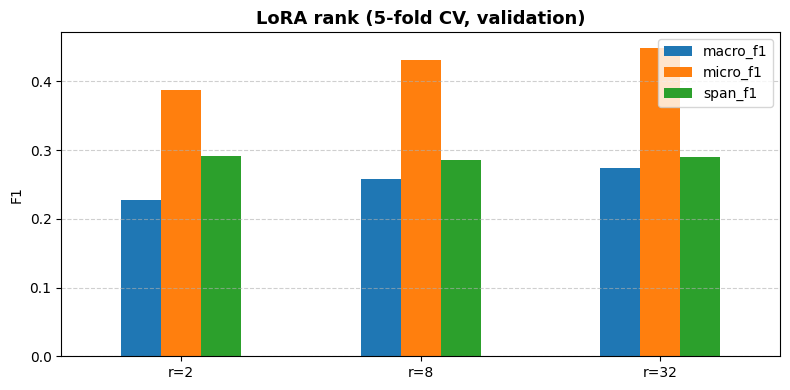

In [30]:
#[9e] Step 2b: LoRA rank search

SEARCH_P1, SEARCH_P2, SEARCH_FOLDS = 2, 6, K_FOLDS

lora_ranks = [2, 8, 32]
rank_results = {}
rank_curves = {}                 #fold 1 learning curves per rank, for plot_experiments

print(f"Step 2b: Tune LoRA rank (λ={BASELINE_LAM}, pooling={BASELINE_POOLING})")
for r in lora_ranks:
    #trainable parameters for this rank (heads + LoRA adapters)
    tmp = inject_lora(build_two_head_model(pooling=BASELINE_POOLING), r=r)
    total_p, trainable_p, _ = count_parameters(tmp)
    del tmp
    torch.cuda.empty_cache()

    res = run_kfold_twohead_lora(lam=BASELINE_LAM, pooling=BASELINE_POOLING, lora_r=r,
                            p1_epochs=SEARCH_P1, p2_epochs=SEARCH_P2, patience=SEARCH_P2,
                            max_folds=SEARCH_FOLDS, tag=f"LoRA r={r}", verbose=False)
    fold_scores = [v["score"] for v in res["fold_results"].values()]
    rank_results[f"r={r}"] = {**res["summary"], "score_std": float(np.std(fold_scores, ddof=1)),
                              "trainable_params_M": trainable_p / 1e6, "r": r}
    rank_curves[f"LoRA r={r}"] = list(res["fold_histories"].values())[0]
    print(f"r={r:2d}: trainable {trainable_p/1e6:.2f}M | CV Macro-F1 {res['summary']['macro_f1']:.4f} | "
          f"CV Span-F1 {res['summary']['span_f1']:.4f} | score {res['summary']['score']:.4f} ± {rank_results[f'r={r}']['score_std']:.4f}")
    del res
    gc.collect()

#smallest rank within one fold-std of the best score (cheaper, less overfitting)
best_key = max(rank_results, key=lambda k: rank_results[k]["score"])
cutoff = rank_results[best_key]["score"] - rank_results[best_key]["score_std"]
best_r = min(v["r"] for v in rank_results.values() if v["score"] >= cutoff)
print(f"\n✅ Best score: {best_key}. Selected LoRA rank for final model: r={best_r} "
      f"(smallest rank within one std of the best)")

rank_df = pd.DataFrame(rank_results).T[["trainable_params_M", "macro_f1", "micro_f1", "span_f1", "score", "score_std"]].astype(float)
display(rank_df.round(4))

#learning curves (fold 1) for each rank
plot_experiments(rank_curves, title="LoRA rank: fold 1 learning curves")

#CV scores per rank with fold std
ax = rank_df[["macro_f1", "micro_f1", "span_f1"]].plot.bar(figsize=(8, 4), rot=0)
ax.set_title("LoRA rank (5-fold CV, validation)", fontsize=13, fontweight="bold")
ax.set_ylabel("F1")
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

LoRA model | r=32, dropout=0.1, wd=0.01, lr=0.0001, λ=1.0, pooling=cls, Phase 1 epochs=5, Phase 2 epochs≤5, patience=5

========== LoRA r32 | FOLD 1/5 ==========
[LoRA r32_F1_P1] Epoch   1/5 | Train Loss: 1.1650 (doc 0.5724, tok 0.5927) | Val Loss: 0.9906 | Val Macro-F1: 0.142 | Val Micro-F1: 0.172 | Val Span-F1: 0.107 | Thr: 0.05/0.35
[LoRA r32_F1_P1] Epoch   5/5 | Train Loss: 0.9079 (doc 0.4999, tok 0.4080) | Val Loss: 0.8993 | Val Macro-F1: 0.159 | Val Micro-F1: 0.228 | Val Span-F1: 0.319 | Thr: 0.15/0.35
[LoRA r32_F1_LoRA] Epoch   1/5 | Train Loss: 0.8455 (doc 0.4649, tok 0.3806) | Val Loss: 0.8591 | Val Macro-F1: 0.212 | Val Micro-F1: 0.402 | Val Span-F1: 0.301 | Thr: 0.20/0.35
[LoRA r32_F1_LoRA] Epoch   5/5 | Train Loss: 0.6153 (doc 0.3248, tok 0.2905) | Val Loss: 0.8870 | Val Macro-F1: 0.228 | Val Micro-F1: 0.460 | Val Span-F1: 0.300 | Thr: 0.20/0.40

========== LoRA r32 | FOLD 2/5 ==========
[LoRA r32_F2_P1] Epoch   1/5 | Train Loss: 1.1771 (doc 0.5805, tok 0.5965) | Val Loss: 

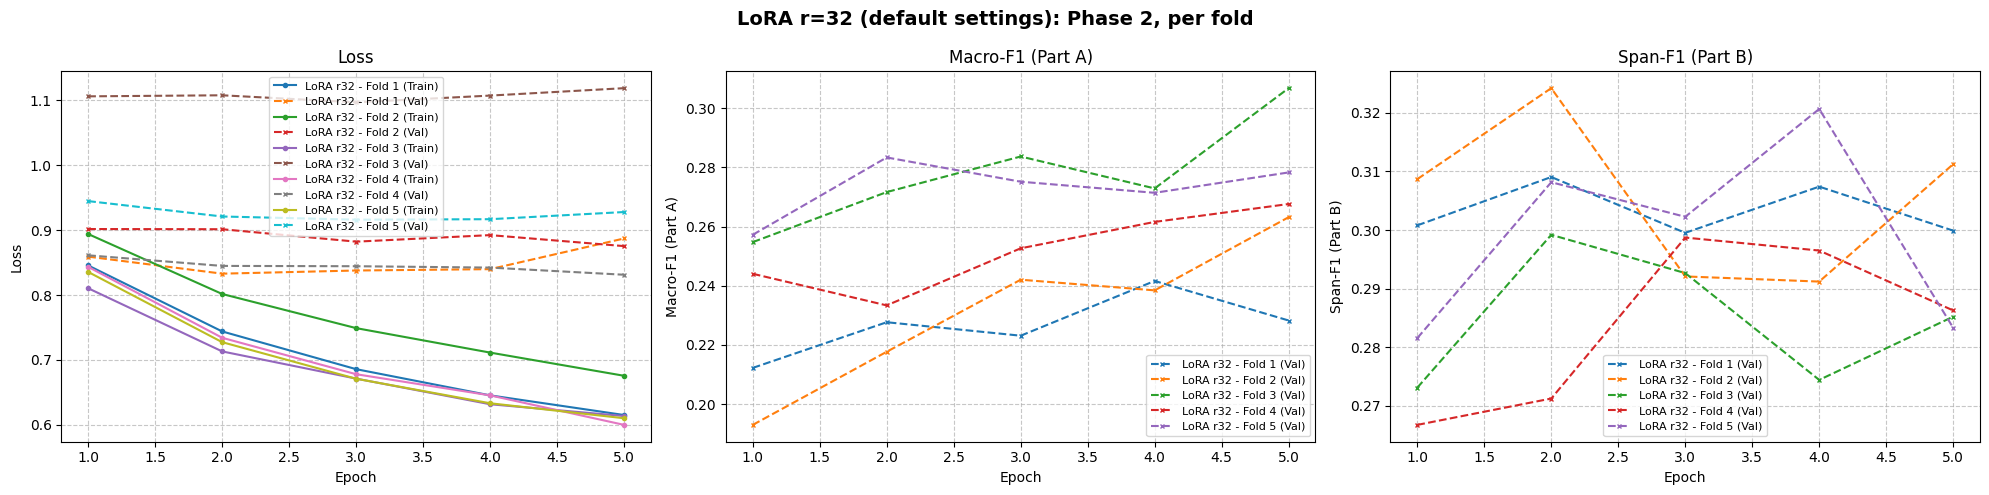

,epoch,score,macro_f1,micro_f1,span_f1,thr,tok_thr
LoRA r32 - Fold 1,4.0,0.275,0.242,0.471,0.307,0.35,0.50
LoRA r32 - Fold 2,5.0,0.287,0.263,0.439,0.311,0.30,0.45
LoRA r32 - Fold 3,5.0,0.296,0.307,0.451,0.285,0.25,0.45
LoRA r32 - Fold 4,4.0,0.279,0.262,0.426,0.297,0.25,0.40
LoRA r32 - Fold 5,4.0,0.296,0.271,0.432,0.321,0.40,0.45



--- Baseline vs Full fine-tuning vs LoRA (default settings) ---


,CV Macro-F1,CV Micro-F1,CV Span-F1,Test Macro-F1,Test Macro-F1 (all 20),Test Micro-F1,Test Span-F1,Test Span P / R,Per-fold test Macro-F1,Phase 2 trainable params (M)
Baseline: frozen RoBERTa (≤5 epochs),0.175 ± 0.014,0.280 ± 0.046,0.309 ± 0.014,0.159,0.143,0.273,0.356,0.291 / 0.460,0.174 ± 0.023,heads only
Full fine-tuning [9c],0.284 ± 0.011,0.466 ± 0.017,0.329 ± 0.011,0.351,0.316,0.532,0.389,0.401 / 0.378,0.296 ± 0.008,125.0
LoRA r=32 (defaults),0.269 ± 0.024,0.444 ± 0.018,0.304 ± 0.014,0.31,0.279,0.485,0.386,0.378 / 0.395,0.288 ± 0.020,2.10


LoRA training time (5 folds): 5.7 min | peak GPU memory during LoRA training: 1795 MB


,full macro,LoRA macro,full span,LoRA span,Δ macro (LoRA − full),Δ span (LoRA − full)
Fold 1,0.291,0.242,0.347,0.307,-0.050,-0.039
Fold 2,0.285,0.263,0.321,0.311,-0.022,-0.010
Fold 3,0.296,0.307,0.331,0.285,0.011,-0.046
Fold 4,0.278,0.262,0.322,0.297,-0.016,-0.025
Fold 5,0.269,0.271,0.327,0.321,0.002,-0.006


Δ Macro-F1 (LoRA − full): mean -0.015, LoRA better in 2/5 folds
Δ Span-F1  (LoRA − full): mean -0.025, LoRA better in 0/5 folds


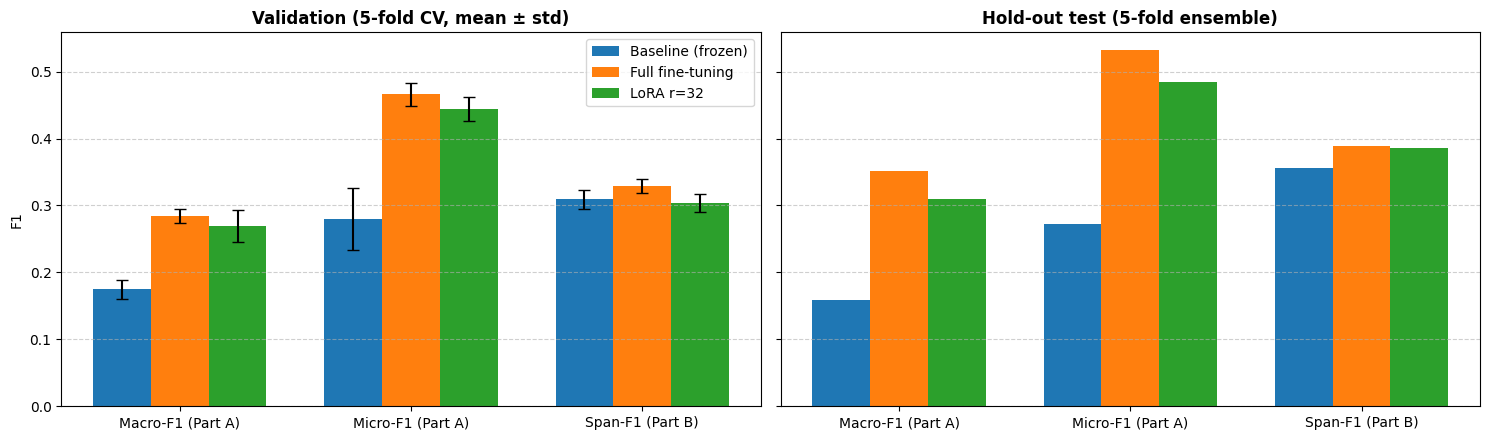

In [32]:
#[9f] LoRA (r = 32) vs full fine-tuning ([9c]), same default settings
import time

#like-for-like: the baseline arm is [9a-2] (frozen RoBERTa + augmentation), because the runs below also train
#on the augmented copies (USE_AUG). Comparing with [9a] (no augmentation) would mix two changes into one Δ.
if USE_PTC:
    print("⚠️ USE_PTC is True but [9a-2] was trained without PTC: re-run the probe with PTC for a like-for-like baseline.")
import time
BEST_R = best_r               #from [9e]: smallest rank within one fold-std of the best CV score
DEFAULT_LORA_DROPOUT = 0.1    #run_kfold_twohead_lora default (not tuned yet)
DEFAULT_WD = 0.01             #same as [9c]
DEFAULT_LR = 1e-4             #run_kfold_twohead_lora default (not tuned yet)

# ------------------------------------------------------------------------------
# 1. Train LoRA with the [9c] defaults (only Phase 2 differs)
# ------------------------------------------------------------------------------
print(f"LoRA model | r={BEST_R}, dropout={DEFAULT_LORA_DROPOUT}, wd={DEFAULT_WD}, lr={DEFAULT_LR}, "
      f"λ={BASELINE_LAM}, pooling={BASELINE_POOLING}, "
      f"Phase 1 epochs={P1_EPOCHS}, Phase 2 epochs≤{P2_EPOCHS}, patience={PATIENCE}")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
t0 = time.time()
lora_res = run_kfold_twohead_lora(lam=BASELINE_LAM, pooling=BASELINE_POOLING, lora_r=BEST_R,
                                  lora_dropout=DEFAULT_LORA_DROPOUT, weight_decay=DEFAULT_WD, ft_lr=DEFAULT_LR,
                                  p1_epochs=P1_EPOCHS, p2_epochs=P2_EPOCHS, patience=PATIENCE,
                                  tag="LoRA r32")
lora_train_min = (time.time() - t0) / 60
lora_peak_mb = torch.cuda.max_memory_allocated() / 2**20 if torch.cuda.is_available() else float("nan")

all_results.update(lora_res["fold_histories"])
plot_experiments(lora_res["fold_histories"], title=f"LoRA r={BEST_R} (default settings): Phase 2, per fold")

lora_fold_df = pd.DataFrame(lora_res["fold_results"]).T
display(lora_fold_df.round(3))


# ------------------------------------------------------------------------------
# 2. Test evaluation for LoRA models (rebuild with LoRA before loading the weights)
# ------------------------------------------------------------------------------
def evaluate_lora_folds_on_test(res, pooling, lora_r, lora_dropout):
    test_loader_cmp = DataLoader(Subset(full_dataset, idx_test), batch_size=BATCH_SIZE, shuffle=False)
    test_gold_cmp = [GOLD_SPANS[i] for i in idx_test]
    n = len(res["fold_states"])
    per_fold, ens_doc, ens_tok = {}, None, None

    for k, (state, fr) in enumerate(zip(res["fold_states"], res["fold_results"].values())):
        model = inject_lora(build_two_head_model(pooling=pooling), r=lora_r, lora_dropout=lora_dropout)
        load_info = model.load_state_dict(state, strict=False)
        #saved state = heads + LoRA adapters; missing keys are the frozen pretrained RoBERTa weights
        assert not load_info.unexpected_keys, load_info.unexpected_keys[:5]
        model.eval()

        r = evaluate_model(model, test_loader_cmp, test_gold_cmp, threshold=fr["thr"], tok_threshold=fr["tok_thr"])
        per_fold[f"Fold {k+1}"] = {"macro_f1": r["macro_f1"], "micro_f1": r["micro_f1"], "span_f1": r["span_f1"]}
        ens_doc = r["doc_probs"] / n if ens_doc is None else ens_doc + r["doc_probs"] / n
        ens_tok = [t / n for t in r["tok_probs"]] if ens_tok is None else [a + t / n for a, t in zip(ens_tok, r["tok_probs"])]
        offsets, doc_true = r["offsets"], r["doc_true"]

        del model
        torch.cuda.empty_cache()
        gc.collect()

    thr = float(np.mean([v["thr"] for v in res["fold_results"].values()]))
    tok_thr = float(np.mean([v["tok_thr"] for v in res["fold_results"].values()]))
    ens = score_predictions(doc_true, ens_doc, ens_tok, offsets, test_gold_cmp, threshold=thr, tok_threshold=tok_thr)
    return ens, pd.DataFrame(per_fold).T

lora_test, lora_per_fold = evaluate_lora_folds_on_test(lora_res, BASELINE_POOLING, BEST_R, DEFAULT_LORA_DROPOUT)

results_scores[f"LoRA r={BEST_R}, default settings (λ=1, cls)"] = {
    "macro_f1": lora_test["macro_f1"], "micro_f1": lora_test["micro_f1"],
    "accuracy": lora_test["accuracy"], "exact_match": lora_test["exact_match"], "span_f1": lora_test["span_f1"],
}


# ------------------------------------------------------------------------------
# 3. Comparison table: baseline vs full fine-tuning vs LoRA (summary_row from [9c])
# ------------------------------------------------------------------------------
comparison_lora = pd.DataFrame({
    f"Baseline: frozen RoBERTa (≤{PROBE_EPOCHS} epochs)": summary_row(bl_fold_df, bl_test, bl_per_fold),
    "Full fine-tuning [9c]": summary_row(def_fold_df, def_test, def_per_fold),
    f"LoRA r={BEST_R} (defaults)": summary_row(lora_fold_df, lora_test, lora_per_fold),
}).T

#cost of each approach: trainable parameters in Phase 2
tmp_full = build_two_head_model(pooling=BASELINE_POOLING)
full_total, _, _ = count_parameters(tmp_full)
tmp_lora = inject_lora(build_two_head_model(pooling=BASELINE_POOLING), r=BEST_R, lora_dropout=DEFAULT_LORA_DROPOUT)
_, lora_trainable, _ = count_parameters(tmp_lora)
del tmp_full, tmp_lora
torch.cuda.empty_cache()

comparison_lora["Phase 2 trainable params (M)"] = ["heads only", f"{full_total/1e6:.1f}", f"{lora_trainable/1e6:.2f}"]
print("\n--- Baseline vs Full fine-tuning vs LoRA (default settings) ---")
display(comparison_lora)
print(f"LoRA training time (5 folds): {lora_train_min:.1f} min | peak GPU memory during LoRA training: {lora_peak_mb:.0f} MB")


# ------------------------------------------------------------------------------
# 4. Paired fold-by-fold comparison: LoRA vs full fine-tuning (same validation folds)
# ------------------------------------------------------------------------------
paired_lora = pd.DataFrame({
    "full macro": def_fold_df["macro_f1"].values, "LoRA macro": lora_fold_df["macro_f1"].values,
    "full span":  def_fold_df["span_f1"].values,  "LoRA span":  lora_fold_df["span_f1"].values,
}, index=[f"Fold {k+1}" for k in range(len(lora_fold_df))])
paired_lora["Δ macro (LoRA − full)"] = paired_lora["LoRA macro"] - paired_lora["full macro"]
paired_lora["Δ span (LoRA − full)"] = paired_lora["LoRA span"] - paired_lora["full span"]
display(paired_lora.round(3))
print(f"Δ Macro-F1 (LoRA − full): mean {paired_lora['Δ macro (LoRA − full)'].mean():+.3f}, "
      f"LoRA better in {(paired_lora['Δ macro (LoRA − full)'] > 0).sum()}/{len(paired_lora)} folds")
print(f"Δ Span-F1  (LoRA − full): mean {paired_lora['Δ span (LoRA − full)'].mean():+.3f}, "
      f"LoRA better in {(paired_lora['Δ span (LoRA − full)'] > 0).sum()}/{len(paired_lora)} folds")


# ------------------------------------------------------------------------------
# 5. Figure: CV (mean ± fold std) and test ensemble for all three models
# ------------------------------------------------------------------------------
metrics = [("macro_f1", "Macro-F1 (Part A)"), ("micro_f1", "Micro-F1 (Part A)"), ("span_f1", "Span-F1 (Part B)")]
models_cmp = [("Baseline (frozen)", bl_fold_df, bl_test),
              ("Full fine-tuning", def_fold_df, def_test),
              (f"LoRA r={BEST_R}", lora_fold_df, lora_test)]
x = np.arange(len(metrics))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for j, (name, fdf, tres) in enumerate(models_cmp):
    axes[0].bar(x + (j - 1) * w, [fdf[m].mean() for m, _ in metrics], w,
                yerr=[fdf[m].std() for m, _ in metrics], capsize=4, label=name)
    axes[1].bar(x + (j - 1) * w, [tres[m] for m, _ in metrics], w, label=name)
for ax, title in zip(axes, ["Validation (5-fold CV, mean ± std)", "Hold-out test (5-fold ensemble)"]):
    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _, lbl in metrics])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.6)
axes[0].set_ylabel("F1")
axes[0].legend()
plt.tight_layout()
plt.show()

In [33]:
#helper for the sequential hyperparameter search
SELECT_METRIC = "score"   # the metric early stopping already uses; set to "macro_f1" to match your old search

def run_search(
    stage_name, 
    param_name, 
    values,
    lam, 
    pooling, 
    lora_r, 
    lora_dropout, 
    weight_decay, 
    ft_lr,
    p1_epochs,
    p2_epochs, 
    patience, 
    max_folds, 
    label_fmt="{}",
    head_hidden=256,
):
    
    """Runs run_kfold_twohead_lora for each value of one hyperparameter and returns
    (best_value, best_metric, results_df).
    A value may also be a dict of several settings, e.g. {"head_hidden": 256}.
    results_df keeps the fold-to-fold std and the per-fold scores, so later cells can apply the
    paired decision rule (see beats_default in [11]). Only summaries are kept, not model states."""
    rows = []
    best_val, best_metric = None, -1.0

    for v in values:
        label = f"{param_name}={label_fmt.format(v)}"
        print(f"\n{'='*40}\n{stage_name} | Testing {label}\n{'='*40}")

        settings = dict(lam=lam, pooling=pooling, head_hidden=head_hidden, lora_r=lora_r,
                        lora_dropout=lora_dropout, weight_decay=weight_decay, ft_lr=ft_lr)
        
        if isinstance(v, dict):
            settings.update(v)
            label = ",".join(f"{k}={val}" for k, val in v.items())
        else:
            settings[param_name] = v
            label = label_fmt.format(v)
        print(f"\n{'='*40}\n{stage_name} | Testing {param_name}={label}\n{'='*40}")

        res = run_kfold_twohead_lora(
            **settings,
            p1_epochs=p1_epochs,
            p2_epochs=p2_epochs,
            patience=patience,
            max_folds=max_folds,
            tag=f"{stage_name}_{param_name}={label}",
            verbose=False)
        
        s = res["summary"]
        folds = list(res["fold_results"].values())
        sd = lambda key: float(np.std([f[key] for f in folds], ddof=1)) if len(folds) > 1 else 0.0
        rows.append({**s, "score_std": sd("score"), "macro_std": sd("macro_f1"), "micro_std": sd("micro_f1"),
                     "span_std": sd("span_f1"),
                     "fold_score": [f["score"] for f in folds],
                     "fold_macro": [f["macro_f1"] for f in folds],
                     "fold_span": [f["span_f1"] for f in folds]})
        index.append(label if isinstance(v, dict) else v)
        print(f"CV score {s['score']:.4f} ± {rows[-1]['score_std']:.4f} | macro F1 {s['macro_f1']:.4f} | "
              f"micro F1 {s['micro_f1']:.4f} | span F1 {s['span_f1']:.4f}")

        if s[SELECT_METRIC] > best_metric:
            best_metric, best_val = s[SELECT_METRIC], v

        del res
        torch.cuda.empty_cache()
        gc.collect()

    results_df = pd.DataFrame(rows, index=pd.Index(index, name=param_name))
    shown = ["score", "score_std", "macro_f1", "micro_f1", "span_f1"]
    display(results_df[shown].style.highlight_max(axis=0, subset=["score", "macro_f1", "micro_f1", "span_f1"]))
    return best_val, best_metric, results_df

In [34]:
# [10a]: Best LoRA Dropout Search
dropout_rates = [0.00, 0.05, 0.10, 0.15]

print("Stage 1: Tune LoRA Dropout")
best_dropout, best_score_drop, dropout_results = run_search(
    "Stage1", 
    "lora_dropout", 
    dropout_rates,
    lam=BASELINE_LAM, 
    pooling=BASELINE_POOLING, 
    lora_r=BEST_R,
    lora_dropout=0.1,            
    weight_decay=0.01, 
    ft_lr=1e-4,
    p1_epochs=SEARCH_P1, 
    p2_epochs=SEARCH_P2, 
    patience=SEARCH_P2, 
    max_folds=SEARCH_FOLDS,

)
print(f"\n✅ Best dropout for Stage 2: {best_dropout} ({SELECT_METRIC}: {best_score_drop:.4f})")

Stage 1: Tune LoRA Dropout

Stage1 | Testing lora_dropout=0.0
CV score 0.2847 | macro F1 0.2769 | micro F1 0.4512 | span F1 0.2925

Stage1 | Testing lora_dropout=0.05
CV score 0.2831 | macro F1 0.2755 | micro F1 0.4591 | span F1 0.2907

Stage1 | Testing lora_dropout=0.1
CV score 0.2819 | macro F1 0.2741 | micro F1 0.4488 | span F1 0.2897

Stage1 | Testing lora_dropout=0.15
CV score 0.2813 | macro F1 0.2737 | micro F1 0.4509 | span F1 0.2890


,score,macro_f1,micro_f1,span_f1
lora_dropout,,,,
0.000000,0.284727,0.276932,0.451193,0.292521
0.050000,0.283123,0.275500,0.459091,0.290745
0.100000,0.281899,0.274086,0.448766,0.289712
0.150000,0.281334,0.273661,0.450891,0.289007



✅ Best dropout for Stage 2: 0.0 (score: 0.2847)


In [35]:
# [10b]: Best Weight Decay Search
weight_decays = [0.0, 1e-4, 1e-3, 0.01]

print(f"Stage 2: Tune Weight Decay (dropout={best_dropout})")
best_wd, best_score_wd, wd_results = run_search(
    "Stage2", 
    "weight_decay", 
    weight_decays,
    lam=BASELINE_LAM, 
    pooling=BASELINE_POOLING, 
    lora_r=BEST_R,
    lora_dropout=best_dropout,   #from [10a]
    weight_decay=0.01,      #replaced by each value being tested 
    ft_lr=1e-4,
    p1_epochs=SEARCH_P1, p2_epochs=SEARCH_P2, patience=SEARCH_P2, max_folds=SEARCH_FOLDS,
    label_fmt="{:g}",
)
print(f"\n✅ Best weight decay for Stage 3: {best_wd} ({SELECT_METRIC}: {best_score_wd:.4f})")

Stage 2: Tune Weight Decay (dropout=0.0)

Stage2 | Testing weight_decay=0
CV score 0.2810 | macro F1 0.2705 | micro F1 0.4643 | span F1 0.2914

Stage2 | Testing weight_decay=0.0001
CV score 0.2810 | macro F1 0.2705 | micro F1 0.4643 | span F1 0.2914

Stage2 | Testing weight_decay=0.001
CV score 0.2852 | macro F1 0.2761 | micro F1 0.4625 | span F1 0.2943

Stage2 | Testing weight_decay=0.01
CV score 0.2847 | macro F1 0.2769 | micro F1 0.4512 | span F1 0.2925


,score,macro_f1,micro_f1,span_f1
weight_decay,,,,
0.000000,0.280959,0.270540,0.464345,0.291378
0.000100,0.280959,0.270540,0.464345,0.291378
0.001000,0.285194,0.276098,0.462530,0.294290
0.010000,0.284727,0.276932,0.451193,0.292521



✅ Best weight decay for Stage 3: 0.001 (score: 0.2852)


In [36]:
# [10c]: Best Learning Rate Search
learning_rates = [1e-5, 3e-5, 5e-5, 1e-4]

print(f"Stage 3: Tune Learning Rate (dropout={best_dropout}, WD={best_wd})")
best_lr, best_score_lr, lr_results = run_search(
    "Stage3", 
    "ft_lr", 
    learning_rates,
    lam=BASELINE_LAM, 
    pooling=BASELINE_POOLING, 
    lora_r=BEST_R,
    lora_dropout=best_dropout,   #from [10a]
    weight_decay=best_wd,        #from [10b]
    ft_lr=1e-4,                  #replaced by each value being tested
    p1_epochs=SEARCH_P1, p2_epochs=SEARCH_P2, patience=SEARCH_P2, max_folds=SEARCH_FOLDS,
    label_fmt="{:.0e}",
)
print(f"\n✅ Best LR: {best_lr} ({SELECT_METRIC}: {best_score_lr:.4f})")
print(f"Best config: lora_dropout={best_dropout}, weight_decay={best_wd}, ft_lr={best_lr}")

with open("twohead_hparam_search.json", "w") as f:
    json.dump({"lora_dropout": best_dropout, "weight_decay": best_wd, "ft_lr": best_lr,
               "select_metric": SELECT_METRIC}, f, indent=1)

Stage 3: Tune Learning Rate (dropout=0.0, WD=0.001)

Stage3 | Testing ft_lr=1e-05
CV score 0.2208 | macro F1 0.1697 | micro F1 0.2783 | span F1 0.2720

Stage3 | Testing ft_lr=3e-05
CV score 0.2597 | macro F1 0.2455 | micro F1 0.4237 | span F1 0.2739

Stage3 | Testing ft_lr=5e-05
CV score 0.2724 | macro F1 0.2606 | micro F1 0.4435 | span F1 0.2842

Stage3 | Testing ft_lr=1e-04
CV score 0.2852 | macro F1 0.2761 | micro F1 0.4625 | span F1 0.2943


,score,macro_f1,micro_f1,span_f1
ft_lr,,,,
0.000010,0.220845,0.169714,0.278321,0.271975
0.000030,0.259678,0.245478,0.423722,0.273878
0.000050,0.272360,0.260560,0.443490,0.284159
0.000100,0.285194,0.276098,0.462530,0.294290



✅ Best LR: 0.0001 (score: 0.2852)
Best config: lora_dropout=0.0, weight_decay=0.001, ft_lr=0.0001


Step 1: Tune λ (weight of the span loss)
λ=0.0: CV Macro-F1 0.2819 | CV Micro-F1 0.4581 | CV Span-F1 0.0840 | score 0.1830
λ=0.5: CV Macro-F1 0.2829 | CV Micro-F1 0.4682 | CV Span-F1 0.2905 | score 0.2867
λ=1.0: CV Macro-F1 0.2872 | CV Micro-F1 0.4630 | CV Span-F1 0.2928 | score 0.2900
λ=2.0: CV Macro-F1 0.2890 | CV Micro-F1 0.4633 | CV Span-F1 0.3010 | score 0.2950

✅ Best λ selected for Step 2: 2.0 (score 0.2950)


,macro_f1,micro_f1,span_f1,score
λ=0.0,0.2819,0.4581,0.0840,0.1830
λ=0.5,0.2829,0.4682,0.2905,0.2867
λ=1.0,0.2872,0.4630,0.2928,0.2900
λ=2.0,0.2890,0.4633,0.3010,0.2950


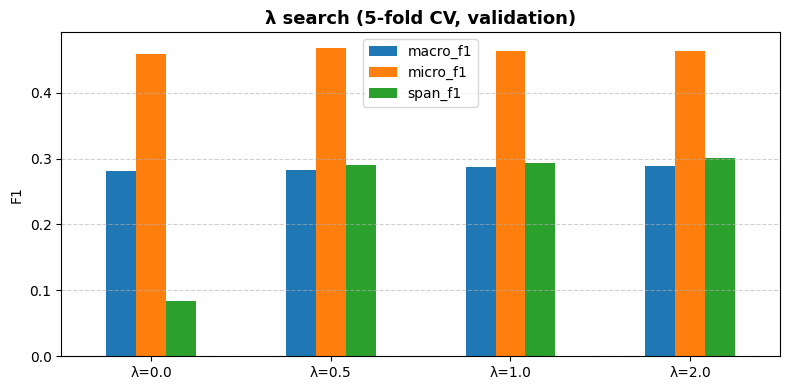

In [37]:
#[10d] Step 1: λ search with lora settings tuned
from torch.utils.data import DataLoader, Subset

#[10d] Step 1: λ search (with the tuned LoRA settings)

lambdas = [0.0, 0.5, 1.0, 2.0]

print(f"Step 1: Tune λ (r={BEST_R}, dropout={best_dropout}, wd={best_wd}, lr={best_lr}, pooling={BASELINE_POOLING})")
_, _, lambda_df = run_search(
    "Step1", "lam", lambdas,
    lam=BASELINE_LAM,            #replaced by each value being tested
    pooling=BASELINE_POOLING,
    lora_r=BEST_R,
    lora_dropout=best_dropout,   #[10a]
    weight_decay=best_wd,        #[10b]
    ft_lr=best_lr,               #[10c]
    p1_epochs=SEARCH_P1, p2_epochs=SEARCH_P2, patience=SEARCH_P2, max_folds=SEARCH_FOLDS,
)

#(1) λ for the final system: best combined score among λ > 0
lam_pos = lambda_df[lambda_df.index > 0]
best_lambda = float(lam_pos["score"].idxmax())
print(f"\n✅ Best λ (λ > 0, combined score): {best_lambda} "
      f"(score {lam_pos.loc[best_lambda, 'score']:.4f} ± {lam_pos.loc[best_lambda, 'score_std']:.4f})")

#(2) does the span task help Part A? paired by fold, same rule as [9a-2] and [PTC-6]
macro_off = np.array(lambda_df.loc[0.0, "fold_macro"])
macro_on = np.array(lambda_df.loc[best_lambda, "fold_macro"])
d_mt = macro_on - macro_off
std_off = float(lambda_df.loc[0.0, "macro_std"])
SPAN_TASK_HELPS_PART_A = bool(d_mt.mean() > std_off and (d_mt > 0).sum() >= 4)
SPAN_TASK_HURTS_PART_A = bool(-d_mt.mean() > std_off and (d_mt < 0).sum() >= 4)
print(f"Doc Macro-F1  λ=0 (span task off): {macro_off.mean():.3f} ± {std_off:.3f} | "
      f"λ={best_lambda}: {macro_on.mean():.3f} ± {lambda_df.loc[best_lambda, 'macro_std']:.3f}")
print(f"Paired Δ (λ={best_lambda} − λ=0): mean {d_mt.mean():+.3f}, better in {(d_mt > 0).sum()}/{len(d_mt)} folds")
print(f"Span task clearly helps Part A: {SPAN_TASK_HELPS_PART_A} | clearly hurts Part A: {SPAN_TASK_HURTS_PART_A}")
if not SPAN_TASK_HURTS_PART_A:
    print("-> Sharing one encoder costs Part A nothing measurable, and halves the model size and inference time "
          "compared with two separate fine-tuned encoders.")

#figure: CV F1 per λ (span F1 at λ = 0 is shown but is meaningless) + paired fold view for Part A
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
lambda_df[["macro_f1", "micro_f1", "span_f1"]].plot.bar(ax=axes[0], rot=0,
    yerr=lambda_df[["macro_std", "micro_std", "span_std"]].values.T, capsize=3)
axes[0].set_title("λ search (5-fold CV, validation, mean ± fold std)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("F1")
axes[0].annotate("span F1 at λ=0:\ntoken head untrained", xy=(0.17, lambda_df.loc[0.0, "span_f1"]),
                 xytext=(0.4, 0.9), textcoords="axes fraction", fontsize=8, arrowprops=dict(arrowstyle="->"))
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

folds_x = np.arange(1, len(d_mt) + 1)
axes[1].plot(folds_x, macro_off, "o--", label="λ = 0 (span task off)")
axes[1].plot(folds_x, macro_on, "s-", label=f"λ = {best_lambda}")
axes[1].set_xticks(folds_x)
axes[1].set_xlabel("fold")
axes[1].set_ylabel("validation doc Macro-F1 (Part A)")
axes[1].set_title("Does the span task help Part A? (paired by fold)", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Step 2: Pooling
With λ from [10d] and the stock heads, this compares how the meme is summarised before the doc head: the first token (`cls`, the standard RoBERTa / Volta set-up), the `mean` of all tokens, or the learned `attn` pooling designed here. `cls` is the default; `mean` or `attn` replace it only if they pass the same paired rule used for augmentation and PTC: a mean fold-by-fold gain larger than the default's fold std, and better in at least 4 of the 5 folds.

Step 2: Tune pooling (λ=1.0, r=32, dropout=0.0, wd=0.001, lr=0.0001)

Step2 | Testing pooling=cls
CV score 0.2852 | macro F1 0.2761 | micro F1 0.4625 | span F1 0.2943

Step2 | Testing pooling=mean
CV score 0.2902 | macro F1 0.2864 | micro F1 0.4548 | span F1 0.2940

Step2 | Testing pooling=attn
CV score 0.2900 | macro F1 0.2805 | micro F1 0.4563 | span F1 0.2996


,score,macro_f1,micro_f1,span_f1
pooling,,,,
cls,0.285194,0.276098,0.462530,0.294290
mean,0.290221,0.286414,0.454788,0.294029
attn,0.290040,0.280503,0.456271,0.299577



✅ Best pooling selected for final model: mean (score: 0.2902)


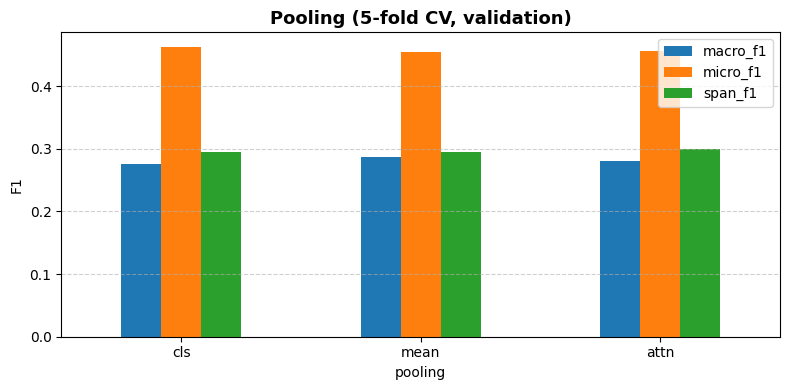

In [38]:
#[11] Step 2: pooling search with the stock heads (using the λ selected in [10d])

def beats_default(results_df, cand, default, metric="score"):
    '''Decision rule used throughout ([9a-2], [PTC-6]): the candidate replaces the default only if its
    mean paired fold gain is larger than the default's fold std AND it is better in at least 4 of 5 folds.
    Returns (replace?, mean paired gain, folds where the candidate is better).'''
    col = {"score": "fold_score", "macro_f1": "fold_macro", "span_f1": "fold_span"}[metric]
    cand_f = np.array(results_df.loc[cand, col])
    def_f = np.array(results_df.loc[default, col])
    d = cand_f - def_f
    std_default = float(np.std(def_f, ddof=1)) if len(def_f) > 1 else 0.0
    replace = bool(d.mean() > std_default and (d > 0).sum() >= min(4, len(d)))
    return replace, float(d.mean()), int((d > 0).sum())


pooling_options = ["cls", "mean", "attn"]

print(f"Step 2: Tune pooling (λ={best_lambda}, r={BEST_R}, dropout={best_dropout}, "
      f"wd={best_wd}, lr={best_lr})")
_, _, design_df = run_search(
    "Step2", "pooling",
    pooling_options,
    lam=best_lambda,             #[10d]
    pooling=BASELINE_POOLING,    #replaced by each value being tested
    lora_r=BEST_R,               #[9e]
    lora_dropout=best_dropout,   #[10a]
    weight_decay=best_wd,        #[10b]
    ft_lr=best_lr,               #[10c]
    p1_epochs=SEARCH_P1,
    p2_epochs=SEARCH_P2,
    patience=SEARCH_P2,
    max_folds=SEARCH_FOLDS,
)

#cls is the default; mean / attn replace it only if they pass the paired rule (best-scoring candidate first)
best_pooling = BASELINE_POOLING
for cand in sorted([p for p in pooling_options if p != BASELINE_POOLING], key=lambda p: -design_df.loc[p, "score"]):
    ok, gain, n_better = beats_default(design_df, cand, BASELINE_POOLING)
    print(f"{cand} vs {BASELINE_POOLING}: mean paired Δ score {gain:+.4f}, better in {n_better}/{SEARCH_FOLDS} folds "
          f"-> {'replaces ' + BASELINE_POOLING if ok else 'does not pass the rule'}")
    if ok and best_pooling == BASELINE_POOLING:
        best_pooling = cand
print(f"\n✅ Pooling selected for the final model: {best_pooling}")

ax = design_df[["macro_f1", "micro_f1", "span_f1"]].plot.bar(figsize=(8, 4), rot=0)
ax.set_title("Pooling (5-fold CV, validation)", fontsize=13, fontweight="bold")
ax.set_ylabel("F1")
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Step 3: Final two-head model (full training with the selected settings)

Final config: λ=1.0, pooling=mean, LoRA r=32, dropout=0.0, weight decay=0.001, lr=0.0001, heads=RoBERTa baseline

========== TwoHead | FOLD 1/5 ==========
[TwoHead_F1_P1] Epoch   1/5 | Train Loss: 1.1603 (doc 0.5675, tok 0.5928) | Val Loss: 0.9798 | Val Macro-F1: 0.147 | Val Micro-F1: 0.174 | Val Span-F1: 0.108 | Thr: 0.05/0.35
[TwoHead_F1_P1] Epoch   5/5 | Train Loss: 0.7917 (doc 0.3842, tok 0.4075) | Val Loss: 0.8705 | Val Macro-F1: 0.262 | Val Micro-F1: 0.472 | Val Span-F1: 0.318 | Thr: 0.30/0.35
[TwoHead_F1_LoRA] Epoch   1/5 | Train Loss: 0.7990 (doc 0.3876, tok 0.4113) | Val Loss: 0.8680 | Val Macro-F1: 0.292 | Val Micro-F1: 0.458 | Val Span-F1: 0.296 | Thr: 0.35/0.35
[TwoHead_F1_LoRA] Epoch   5/5 | Train Loss: 0.5833 (doc 0.2613, tok 0.3220) | Val Loss: 0.8831 | Val Macro-F1: 0.260 | Val Micro-F1: 0.513 | Val Span-F1: 0.317 | Thr: 0.30/0.40

========== TwoHead | FOLD 2/5 ==========
[TwoHead_F2_P1] Epoch   1/5 | Train Loss: 1.1654 (doc 0.5689, tok 0.5965) | Val Loss: 1.0186 | Val 

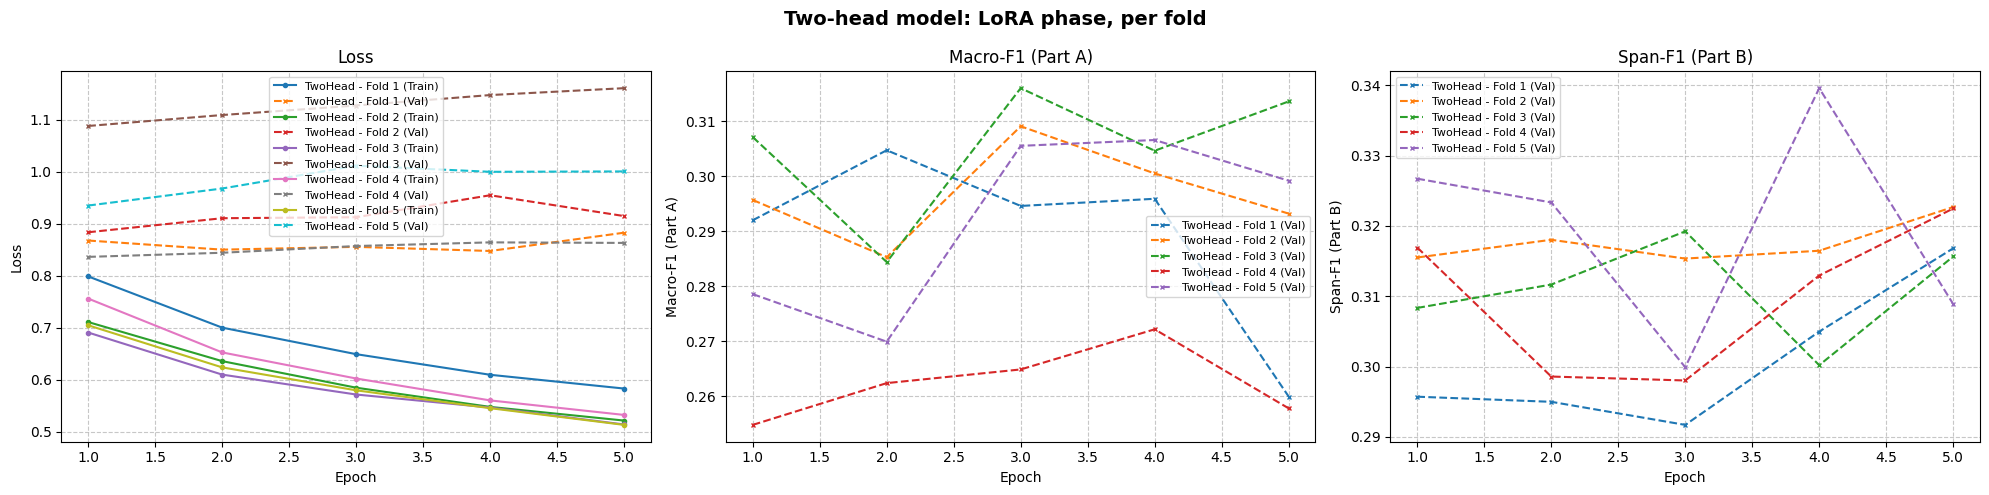

,epoch,score,macro_f1,micro_f1,span_f1,thr,tok_thr
TwoHead - Fold 1,4.0,0.300,0.296,0.487,0.305,0.45,0.45
TwoHead - Fold 2,3.0,0.312,0.309,0.469,0.315,0.35,0.50
TwoHead - Fold 3,3.0,0.318,0.316,0.440,0.319,0.25,0.45
TwoHead - Fold 4,4.0,0.293,0.272,0.442,0.313,0.15,0.40
TwoHead - Fold 5,4.0,0.323,0.307,0.470,0.340,0.25,0.50



--- Cross Validation Summary (5 Folds) ---
Average Val Macro-F1: 0.300 ± 0.017
Average Val Micro-F1: 0.462 ± 0.020
Average Val Span-F1:  0.318 ± 0.013


In [39]:
#[12] Step 3: final 5-fold training with every selected setting

print(f"Final config: λ={best_lambda}, pooling={best_pooling}, LoRA r={BEST_R}, "
      f"dropout={best_dropout}, weight decay={best_wd}, lr={best_lr}")

final_res = run_kfold_twohead_lora(
    lam=best_lambda,                  #[10d]
    pooling=best_pooling,             #[11]
    lora_r=BEST_R,                    #[9e]
    lora_dropout=best_dropout,        #[10a]
    weight_decay=best_wd,             #[10b]
    ft_lr=best_lr,                    #[10c]
    p1_epochs=P1_EPOCHS,
    p2_epochs=P2_EPOCHS,
    patience=PATIENCE,
    tag="TwoHead")

with open("twohead_final_config.json", "w") as f:
    json.dump(final_res["config"], f, indent=1)

all_results.update(final_res["fold_histories"])
plot_experiments(final_res["fold_histories"], title="Two-head model: LoRA phase, per fold")

fold_df = pd.DataFrame(final_res["fold_results"]).T
display(fold_df.round(3))

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {final_res['summary']['macro_f1']:.3f} ± {fold_df['macro_f1'].std():.3f}")
print(f"Average Val Micro-F1: {final_res['summary']['micro_f1']:.3f} ± {fold_df['micro_f1'].std():.3f}")
print(f"Average Val Span-F1:  {final_res['summary']['span_f1']:.3f} ± {fold_df['span_f1'].std():.3f}")

### Final test evaluation (hold-out 15%, used once)
* Each of the 5 fold models predicts the test memes; the **ensemble** averages their probabilities and uses the mean of the five validation thresholds. Averaging the folds is preferred to picking the single best fold, whose validation score is optimistically biased by being the maximum of five.
* The per-fold test scores are also reported to show how much the result depends on which memes a model was trained on.

In [40]:
#[13] final test evaluation: per-fold models and the 5-fold ensemble

test_loader = DataLoader(Subset(full_dataset, idx_test), batch_size=BATCH_SIZE, shuffle=False)
test_gold = [GOLD_SPANS[i] for i in idx_test]
cfg = final_res["config"]

def load_fold_model(state):
    model = build_two_head_model(pooling=cfg["pooling"], head_type=cfg.get("head_type", "roberta"),
                                 head_hidden=cfg.get("head_hidden", 256))
    if cfg.get("finetune", "lora") == "lora":
        model = inject_lora(model, r=cfg["lora_r"], lora_dropout=cfg["lora_dropout"])
    load_info = model.load_state_dict(state, strict=False)
    #every saved weight must find its place in the rebuilt model
    assert not load_info.unexpected_keys, load_info.unexpected_keys[:5]
    model.eval()
    return model

per_fold_test = {}
ens_doc, ens_tok = None, None
for k, (state, fr) in enumerate(zip(final_res["fold_states"], final_res["fold_results"].values())):
    model = load_fold_model(state)
    model.set_loss_weights(None, None, cfg["lam"])
    r = evaluate_model(model, test_loader, test_gold, threshold=fr["thr"], tok_threshold=fr["tok_thr"])
    per_fold_test[f"Fold {k+1}"] = {"macro_f1": r["macro_f1"], "micro_f1": r["micro_f1"], "span_f1": r["span_f1"]}
    ens_doc = r["doc_probs"] / K_FOLDS if ens_doc is None else ens_doc + r["doc_probs"] / K_FOLDS
    ens_tok = [t / K_FOLDS for t in r["tok_probs"]] if ens_tok is None else [a + t / K_FOLDS for a, t in zip(ens_tok, r["tok_probs"])]
    test_offsets, test_doc_true = r["offsets"], r["doc_true"]
    del model
    torch.cuda.empty_cache()
    gc.collect()

ens_thr = float(np.mean([fr["thr"] for fr in final_res["fold_results"].values()]))
ens_tok_thr = float(np.mean([fr["tok_thr"] for fr in final_res["fold_results"].values()]))
test_res = score_predictions(test_doc_true, ens_doc, ens_tok, test_offsets, test_gold,
                             threshold=ens_thr, tok_threshold=ens_tok_thr)

#stricter Macro-F1: all 20 techniques, absent ones count as 0
macro_all20 = float(test_res["per_class_f1"].mean())

per_fold_df = pd.DataFrame(per_fold_test).T
display(per_fold_df.round(3))
print("Per-fold test (mean ± std): " + " | ".join(
    f"{c} {per_fold_df[c].mean():.3f} ± {per_fold_df[c].std():.3f}" for c in per_fold_df.columns))

print(f"\n--- Final Test Evaluation (5-fold ensemble) ---")
print(f"Doc threshold / token threshold: {ens_thr:.2f} / {ens_tok_thr:.2f}")
print(f"Part A  Test Macro-F1:            {test_res['macro_f1']:.3f}   (techniques present in test)")
print(f"Part A  Test Macro-F1 (all 20):   {macro_all20:.3f}")
print(f"Part A  Test Micro-F1:            {test_res['micro_f1']:.3f}   (official SemEval Subtask 1 measure)")
print(f"Part A  Test Accuracy:            {test_res['accuracy']:.3f}")
print(f"Part A  Exact Match:              {test_res['exact_match']:.3f}")
print(f"Part B  Test Span-F1:             {test_res['span_f1']:.3f}")
print(f"Part B  Test Span-Precision:      {test_res['span_precision']:.3f}")
print(f"Part B  Test Span-Recall:         {test_res['span_recall']:.3f}")

results_scores["RoBERTa Two-Head LoRA (ensemble)"] = {
    "macro_f1": test_res["macro_f1"],
    "micro_f1": test_res["micro_f1"],
    "accuracy": test_res["accuracy"],
    "exact_match": test_res["exact_match"],
    "span_f1": test_res["span_f1"],
}
display(pd.DataFrame(results_scores).T.round(3))

,macro_f1,micro_f1,span_f1
Fold 1,0.269,0.488,0.309
Fold 2,0.304,0.485,0.315
Fold 3,0.302,0.478,0.355
Fold 4,0.259,0.455,0.350
Fold 5,0.376,0.492,0.343


Per-fold test (mean ± std): macro_f1 0.302 ± 0.046 | micro_f1 0.480 ± 0.015 | span_f1 0.334 ± 0.021

--- Final Test Evaluation (5-fold ensemble) ---
Doc threshold / token threshold: 0.29 / 0.46
Part A  Test Macro-F1:            0.321   (techniques present in test)
Part A  Test Macro-F1 (all 20):   0.289
Part A  Test Micro-F1:            0.511   (official SemEval Subtask 1 measure)
Part A  Test Accuracy:            0.874
Part A  Exact Match:              0.136
Part B  Test Span-F1:             0.357
Part B  Test Span-Precision:      0.361
Part B  Test Span-Recall:         0.354


,macro_f1,micro_f1,accuracy,exact_match,span_f1
Baseline: frozen RoBERTa + RoBERTa heads (linear probe),0.159,0.273,0.578,0.000,0.356
"Default two-phase: full fine-tuning (λ=1, cls)",0.351,0.532,0.880,0.117,0.389
"LoRA r=32, default settings (λ=1, cls)",0.310,0.485,0.860,0.107,0.386
RoBERTa Two-Head LoRA (ensemble),0.321,0.511,0.874,0.136,0.357


,test memes,train+val memes,Part A F1,Part B span F1,predicted (Part A)
Loaded Language,54,304,0.769,0.442,76
Name calling/Labeling,33,185,0.688,0.390,60
Smears,30,170,0.591,0.359,58
Exaggeration/Minimisation,8,44,0.231,0.000,18
Doubt,7,41,0.320,0.024,18
Slogans,7,37,0.345,0.198,22
Appeal to fear/prejudice,6,37,0.273,0.116,16
Whataboutism,6,34,0.345,0.000,23
Glittering generalities (Virtue),5,27,0.133,0.000,10
Causal Oversimplification,4,23,0.111,0.000,14


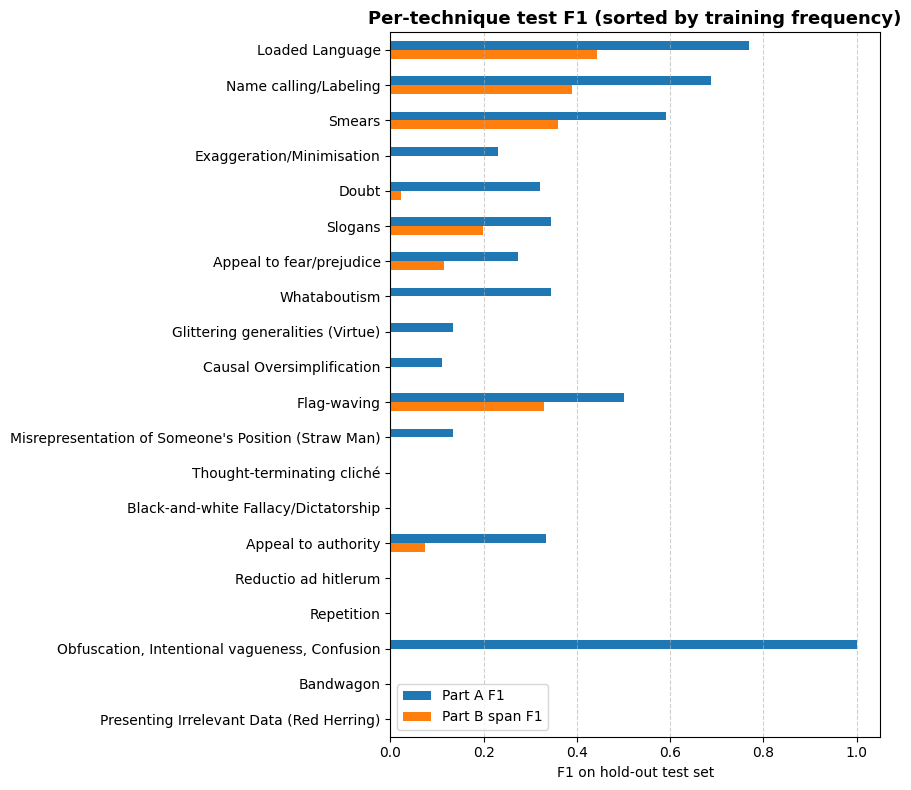

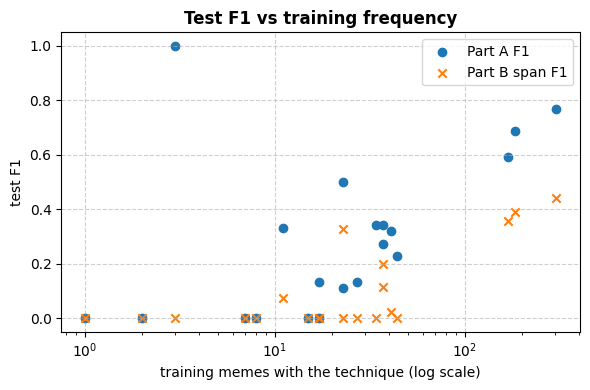

In [42]:
#[14] per-technique results on the test set (Part A vs Part B)

def span_f1_for(technique):
    return span_prf([[s for s in S if s[2] == technique] for S in test_res["span_preds"]],
                    [[g for g in G if g[2] == technique] for G in test_gold])["f1"]

per_tech = pd.DataFrame({
    "test memes": Y[idx_test].sum(0).astype(int),
    "train+val memes": Y[idx_cv].sum(0).astype(int),
    "Part A F1": test_res["per_class_f1"],
    "Part B span F1": [span_f1_for(t) for t in TECHNIQUES],
    "predicted (Part A)": test_res["doc_preds"].sum(0).astype(int),
}, index=TECHNIQUES).sort_values("train+val memes", ascending=False)
display(per_tech.round(3))

ax = per_tech[["Part A F1", "Part B span F1"]].plot.barh(figsize=(9, 8))
ax.invert_yaxis()
ax.set_xlabel("F1 on hold-out test set")
ax.set_title("Per-technique test F1 (sorted by training frequency)", fontsize=13, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#does performance follow training frequency?
plt.figure(figsize=(6, 4))
plt.scatter(per_tech["train+val memes"], per_tech["Part A F1"], label="Part A F1")
plt.scatter(per_tech["train+val memes"], per_tech["Part B span F1"], label="Part B span F1", marker="x")
plt.xscale("log")
plt.xlabel("training memes with the technique (log scale)")
plt.ylabel("test F1")
plt.title("Test F1 vs training frequency", fontsize=12, fontweight="bold")
plt.legend()
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### C3 preview: do the label head and the span head agree?

,either head,both,label only,span only,disagree rate
Loaded Language,77,49,27,1,0.364
Smears,68,48,10,10,0.294
Name calling/Labeling,62,34,26,2,0.452
Whataboutism,26,4,19,3,0.846
Slogans,22,1,21,0,0.955
Doubt,19,6,12,1,0.684
Exaggeration/Minimisation,18,1,17,0,0.944
Appeal to fear/prejudice,17,2,14,1,0.882
Causal Oversimplification,14,0,14,0,1.000
Misrepresentation of Someone's Position (Straw Man),12,0,12,0,1.000


Overall disagreement rate: 0.594


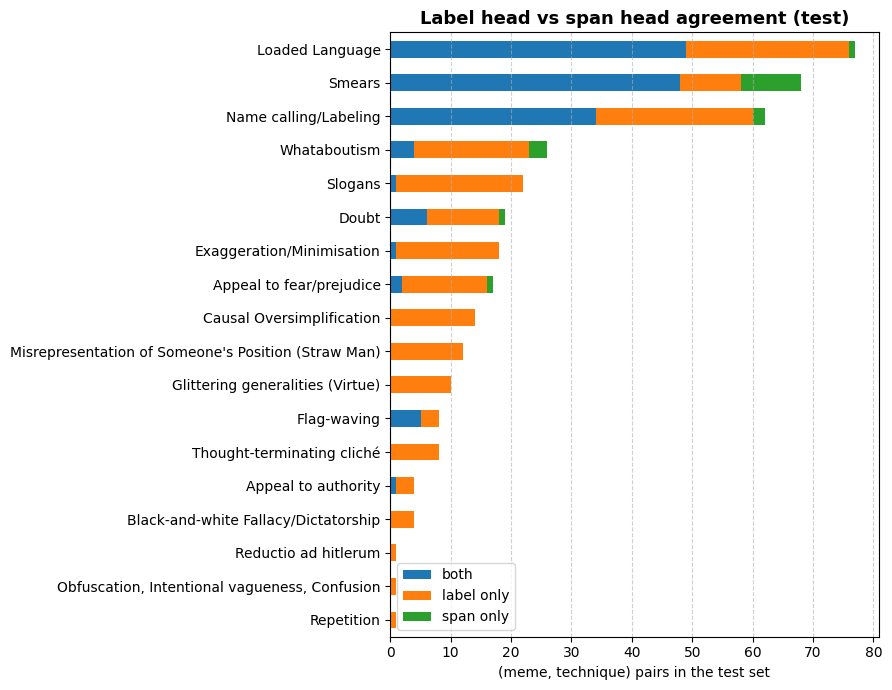

In [43]:
#[15] C3: label head vs span head agreement on the test set

label_on = test_res["doc_preds"].astype(bool)
span_on = np.zeros_like(label_on)
for d, S in enumerate(test_res["span_preds"]):
    for _, _, t in S:
        span_on[d, label2id[t]] = True
either = label_on | span_on

c3 = pd.DataFrame({
    "either head": either.sum(0),
    "both": (label_on & span_on).sum(0),
    "label only": (label_on & ~span_on).sum(0),
    "span only": (~label_on & span_on).sum(0),
}, index=TECHNIQUES)
c3["disagree rate"] = ((c3["label only"] + c3["span only"]) / c3["either head"].replace(0, np.nan)).round(3)
c3 = c3.sort_values("either head", ascending=False)
display(c3)

overall_disagree = (c3["label only"].sum() + c3["span only"].sum()) / max(c3["either head"].sum(), 1)
print(f"Overall disagreement rate: {overall_disagree:.3f}")

ax = c3[c3["either head"] > 0][["both", "label only", "span only"]].plot.barh(stacked=True, figsize=(9, 7))
ax.invert_yaxis()
ax.set_xlabel("(meme, technique) pairs in the test set")
ax.set_title("Label head vs span head agreement (test)", fontsize=13, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
#######################

In [ ]:
#process used in Ng et al. (2019) subsequently used in (Ghadery et al., 2021) - 
#"LIIR at SemEval-2021 task 6: Detection of Persuasion Techniques In Texts and Images using CLIP features"


# 1. Translation helper using Facebook WMT19 models
def translate(text, model_name, sample=False):
    # Use Auto classes as WMT19 uses FSMT architecture, not Marian
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    
    # Introduce sampling to create variation rather than exact literal matches
    if sample:
        outputs = model.generate(
            **inputs, 
            do_sample=True, 
            temperature=0.8, 
            top_p=0.9,
            max_new_tokens=50
        )
    else:
        outputs = model.generate(**inputs, max_new_tokens=50)
        
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Run back-translation using the models referenced in the paper
original = "If Trump isn't Hitler, Then I'm a Moron"

# English to German (Standard generation)
german = translate(original, "facebook/wmt19-en-de")

# German back to English (Enable sampling here to force varied phrasing)
back_translated = translate(german, "facebook/wmt19-de-en", sample=True)

print(f"German: {german}")
print(f"Back-translated: {back_translated}\n")

# 2. Validation Metrics
edit_distance = Levenshtein.distance(original, back_translated)

bleu_score = nltk.translate.bleu_score.sentence_bleu(
    [original.lower().split()], 
    back_translated.lower().split(),
    weights=(0.5, 0.5, 0, 0)
)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([original, back_translated])
semantic_similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

print(f"Original: {original}")
print(f"Paraphrase: {back_translated}")
print(f"Edit Distance: {edit_distance}")
print(f"BLEU Overlap: {bleu_score:.4f}")
print(f"Semantic Similarity: {semantic_similarity:.4f}")

German: Wenn Trump nicht Hitler ist, dann bin ich ein Idiot
Back-translated: If Trump isn't Hitler, then I'm an idiot

Original: If Trump isn't Hitler, Then I'm a Moron
Paraphrase: If Trump isn't Hitler, then I'm an idiot
Edit Distance: 6
BLEU Overlap: 0.7319
Semantic Similarity: 0.6328


In [ ]:
# Process used in Ng et al. (2019), subsequently used in (Ghadery et al., 2021)
# "LIIR at SemEval-2021 task 6: Detection of Persuasion Techniques In Texts and Images using CLIP features"

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers.utils import logging as transformers_logging

# Suppress Transformers output
transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()


def get_wordnet_pos(tag):
    """Maps NLTK POS tags to WordNet POS tags."""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return None


def substitute_synonyms(text, replacement_prob=0.20):
    """
    Replaces words in a sentence with random WordNet synonyms based on POS tags.
    replacement_prob controls the probability (e.g., 20%) that an eligible word gets swapped.
    """
    words = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(words)

    new_words = []
    for word, tag in pos_tags:
        wn_pos = get_wordnet_pos(tag)

        # Skip short words, punctuation, or non-matching POS tags
        if wn_pos and len(word) > 2 and random.random() < replacement_prob:
            synsets = wordnet.synsets(word, pos=wn_pos)
            lemmas = [
                l.name().replace('_', ' ')
                for s in synsets
                for l in s.lemmas()
                if l.name().lower() != word.lower()
            ]

            if lemmas:
                new_words.append(random.choice(lemmas))
                continue

        new_words.append(word)

    return " ".join(new_words)


# -------------------------------------------------------------------
# Load translation models once
# -------------------------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

en_de_model_name = "facebook/wmt19-en-de"
de_en_model_name = "facebook/wmt19-de-en"

# English -> German
en_de_tokenizer = AutoTokenizer.from_pretrained(en_de_model_name)
en_de_model = AutoModelForSeq2SeqLM.from_pretrained(en_de_model_name).to(device)
en_de_model.eval()

# German -> English
de_en_tokenizer = AutoTokenizer.from_pretrained(de_en_model_name)
de_en_model = AutoModelForSeq2SeqLM.from_pretrained(de_en_model_name).to(device)
de_en_model.eval()


def translate_batch(texts, tokenizer, model, sample=False):
    """Translates a batch using an already-loaded model."""
    
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.inference_mode():
        if sample:
            outputs = model.generate(
                **inputs,
                do_sample=True,
                temperature=0.8,
                top_p=0.9,
                max_new_tokens=64
            )
        else:
            outputs = model.generate(
                **inputs,
                max_new_tokens=64
            )

    return tokenizer.batch_decode(
        outputs,
        skip_special_tokens=True
    )


# -------------------------------------------------------------------
# Process in batches
# -------------------------------------------------------------------

batch_size = 16
augmented_rows = []

for i in range(0, len(df), batch_size):
    batch_df = df.iloc[i:i + batch_size]
    original_texts = batch_df['text'].tolist()

    # English -> German
    german_texts = translate_batch(
        original_texts,
        en_de_tokenizer,
        en_de_model,
        sample=False
    )

    # German -> English
    paraphrased_texts = translate_batch(
        german_texts,
        de_en_tokenizer,
        de_en_model,
        sample=True
    )

    # Apply synonym replacement across the paraphrased batch
    final_texts = [
        substitute_synonyms(text, replacement_prob=0.20)
        for text in paraphrased_texts
    ]

    # Reconstruct augmented rows preserving original labels
    for (_, row), final_text in zip(batch_df.iterrows(), final_texts):
        augmented_rows.append({
            'id': f"{row['id']}_aug_de",
            'labels': row['labels'],
            'text': final_text,
            'text_key': (
                f"{row['text_key']}_aug_de"
                if pd.notna(row['text_key'])
                else f"{row['id']}_aug_de"
            )
        })


# -------------------------------------------------------------------
# Combine original and augmented data
# -------------------------------------------------------------------

# df_combined = pd.concat(
#     [df, pd.DataFrame(augmented_rows)],
#     ignore_index=True
# )

In [ ]:
def verify_augmentation(df_original, augmented_data):
    """
    Compares original and augmented texts row-by-row to verify differences.
    
    Parameters:
    - df_original: pandas.DataFrame (the original input dataframe)
    - augmented_data: list or pandas.DataFrame (the generated augmented rows)
    
    Returns:
    - comparison_df: pandas.DataFrame with side-by-side comparison and metrics
    """
    # Convert augmented_data list to DataFrame if necessary
    if isinstance(augmented_data, list):
        df_aug = pd.DataFrame(augmented_data)
    else:
        df_aug = augmented_data.copy()
        
    # Build side-by-side comparison DataFrame
    comparison_df = pd.DataFrame({
        'original_id': df_original['id'].values,
        'augmented_id': df_aug['id'].values,
        'original_text': df_original['text'].values,
        'augmented_text': df_aug['text'].values,
    })
    
    # Check for exact string matches (ignoring leading/trailing whitespace)
    comparison_df['is_exact_match'] = (
        comparison_df['original_text'].str.strip() == comparison_df['augmented_text'].str.strip()
    )
    
    # Measure character-level edit distance
    comparison_df['edit_distance'] = [
        Levenshtein.distance(orig, aug) 
        for orig, aug in zip(comparison_df['original_text'], comparison_df['augmented_text'])
    ]
    
    # Calculate summary metrics
    total_samples = len(comparison_df)
    exact_matches = comparison_df['is_exact_match'].sum()
    unique_paraphrases = total_samples - exact_matches
    uniqueness_rate = (unique_paraphrases / total_samples) * 100 if total_samples > 0 else 0
    avg_edit_dist = comparison_df['edit_distance'].mean()
    
    # Print summary report
    print("=== Augmentation Verification Report ===")
    print(f"Total samples evaluated:     {total_samples}")
    print(f"Successfully paraphrased:    {unique_paraphrases} ({uniqueness_rate:.2f}%)")
    print(f"Identical texts remaining:   {exact_matches} ({100 - uniqueness_rate:.2f}%)")
    print(f"Average edit distance:       {avg_edit_dist:.2f} characters\n")
    
    if exact_matches > 0:
        print(f"⚠️  Notice: {exact_matches} text(s) did not change during back-translation.")
    else:
        print("✅ Success: All augmented texts are distinct from the original entries!")
        
    return comparison_df

# --- Usage Example (Run directly after Option 2) ---
comparison_results = verify_augmentation(df, augmented_rows)

# View all identical entries (if any exist):
duplicates = comparison_results[comparison_results['is_exact_match']]
print(duplicates[['original_id', 'original_text', 'augmented_text']])

=== Augmentation Verification Report ===
Total samples evaluated:     688
Successfully paraphrased:    685 (99.56%)
Identical texts remaining:   3 (0.44%)
Average edit distance:       44.55 characters

⚠️  Notice: 3 text(s) did not change during back-translation.
     original_id                 original_text              augmented_text
95            78  ISIS Employee of the Month\n  ISIS Employee of the Month
393  420_batch_2      DANCE My Bitches Dance\n      DANCE My Bitches Dance
614  786_batch_2             Juanita Brazile\n             Juanita Brazile


In [ ]:
#drop the few that are not the same
df_aug = pd.DataFrame(augmented_rows)
df_aug_filtered = df_aug[~comparison_results['is_exact_match']].copy()


display(df_aug_filtered.head())

,id,labels,text,text_key
0,128_aug_de,[Black-and-white Fallacy/Dictatorship],THERE ARE ONLY TWO GENTER MEN,THERE ARE ONLY TWO GENDERS FEMALE MALE_aug_de
1,189_aug_de,[],This is no coincidence !,This is not an accident!_aug_de
2,96_aug_de,"[Loaded Language, Name calling/Labeling, Sloga...",SO BERNIE BROS HAS NO fierceness EXCEPT ? MAKE...,SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH? ...
3,154_aug_de,"[Causal Oversimplification, Loaded Language, N...",PATHETICsThe Cowardly AssholeWeak Failure ! ! ...,PATHETIC The Cowardly Asshole Weak Failure!!! ...
4,15_aug_de,[],WHO TRUMP REPRESENTSWHO DEMOCRATIZES REPRESENT,WHO TRUMP REPRESENTS WHO DEMOCRATS REPRESENT_a...


In [ ]:
#combine unique augmented to 
df_augmented_combined = pd.concat([df, df_aug_filtered], ignore_index=True)

print(f"Original dataset size: {len(df)}")
print(f"Filtered augmented samples added: {len(df_aug_filtered)}")
print(f"Final combined dataset size: {len(df_augmented_combined)}")

Original dataset size: 688
Filtered augmented samples added: 685
Final combined dataset size: 1373


In [ ]:
# ------------------------------------------------------------------------------
# 4. Metric Utilities & Training Functions
# ------------------------------------------------------------------------------
def f1_stats(y_true, y_pred):
    """
    Calculate multilabel classification metrics. (UNCHANGED)
    """
    tp = (y_true * y_pred).sum(axis=0)
    fp = ((1 - y_true) * y_pred).sum(axis=0)
    fn = (y_true * (1 - y_pred)).sum(axis=0)

    den = 2 * tp + fp + fn

    per_class = np.divide(
        2 * tp,
        den,
        out=np.zeros_like(den, dtype=np.float64),
        where=den > 0
    )

    observed = y_true.sum(axis=0) > 0
    macro_f1 = float(per_class[observed].mean()) if observed.any() else 0.0
    micro_f1 = float(2 * tp.sum() / max(den.sum(), 1))
    exact_match = float((y_true == y_pred).all(axis=1).mean())
    accuracy = float((y_true == y_pred).mean())

    return macro_f1, micro_f1, exact_match, accuracy, per_class

def best_threshold(y_true, probs):
    """
    Find the threshold that gives the highest validation Macro-F1. (UNCHANGED)
    """
    scores = []
    # Ensure THRESHOLDS is defined in your global scope (e.g., np.arange(0.1, 0.9, 0.05))
    for threshold in THRESHOLDS:
        preds = (probs >= threshold).astype(np.float32)
        macro_f1 = f1_stats(y_true, preds)[0]
        scores.append(macro_f1)

    best_idx = int(np.argmax(scores))
    return float(THRESHOLDS[best_idx]), float(scores[best_idx])

def train_one_epoch(model, loader, optimizer):
    """
    Train the model for one epoch. (UPDATED for Token Classification)
    """
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass: Custom model calculates loss internally
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs["loss"]
        
        # Only backward if loss is valid (handles edge case where batch has no active tokens)
        if loss is not None and loss.requires_grad:
            loss.backward()
            optimizer.step()

            batch_size = len(labels)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / max(total_samples, 1)

def evaluate_model(model, loader, threshold=None):
    """
    Evaluate a model. (UPDATED to mask out padding and flatten 3D logits)
    """
    model.eval()
    total_loss = 0.0
    total_samples = 0

    all_probs = []
    all_labels = []

    with torch.inference_mode():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs["loss"]
            logits = outputs["logits"]
            num_classes = logits.shape[-1]

            if loss is not None:
                batch_size = len(labels)
                total_loss += loss.item() * batch_size
                total_samples += batch_size

            # -------------------------------------------------------------
            # TOKEN CLASSIFICATION MASKING & FLATTENING
            # -------------------------------------------------------------
            # Create boolean mask: Keep tokens where attention == 1 AND label != -100
            active_mask = (attention_mask.view(-1) == 1) & (labels.view(-1, num_classes)[:, 0] != -100)
            
            # Apply mask to flatten inputs down to just the valid tokens
            active_logits = logits.view(-1, num_classes)[active_mask]
            active_labels = labels.view(-1, num_classes)[active_mask]

            # Apply sigmoid only to the valid tokens
            probs = torch.sigmoid(active_logits)

            all_probs.append(probs.cpu())
            all_labels.append(active_labels.cpu())

    # Concatenate all batches
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Select threshold from validation data when no threshold is supplied
    if threshold is None:
        threshold, _ = best_threshold(all_labels, all_probs)

    all_preds = (all_probs >= threshold).astype(np.float32)

    macro_f1, micro_f1, exact_match, accuracy, per_class_f1 = f1_stats(all_labels, all_preds)

    return {
        "loss": total_loss / max(total_samples, 1),
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "exact_match": exact_match,
        "accuracy": accuracy,
        "threshold": threshold,
        "per_class_f1": per_class_f1,
        "probs": all_probs,
        "targets": all_labels,
        "preds": all_preds,
    }

def run_experiment(
    model,
    optimizer,
    criterion,       # Left for signature compatibility, but it is IGNORED inside
    train_loader,
    val_loader,
    epochs=10,
    patience=5,
    name="Model",
    scheduler=None
):
    """
    Train with early stopping based on validation Macro-F1. (UPDATED function calls)
    """
    history = {
        "train_loss": [], "val_loss": [], "val_macro": [],
        "val_micro": [], "val_exact": [], "val_accuracy": []
    }

    best_info = {"epoch": 0, "score": -1.0, "thr": 0.5, "state": None}
    epochs_no_improve = 0

    best_info["state"] = {k: v.detach().clone() for k, v in model.state_dict().items()}

    for epoch in range(1, epochs + 1):

        # Criterion is no longer passed down
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_res = evaluate_model(model, val_loader, threshold=None)

        val_loss = val_res["loss"]
        val_macro = val_res["macro_f1"]
        val_micro = val_res["micro_f1"]
        val_exact = val_res["exact_match"]
        val_accuracy = val_res["accuracy"]
        val_threshold = val_res["threshold"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro"].append(val_macro)
        history["val_micro"].append(val_micro)
        history["val_exact"].append(val_exact)
        history["val_accuracy"].append(val_accuracy)

        if val_macro > best_info["score"] + 1e-4:
            best_info = {
                "epoch": epoch,
                "score": val_macro,
                "thr": val_threshold,
                "state": {k: v.detach().clone() for k, v in model.state_dict().items()}
            }
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if scheduler is not None:
            scheduler.step()

        if epoch % 5 == 0 or epoch == 1: # Adjusted print frequency slightly to reduce console spam
            print(
                f"[{name}] Epoch {epoch:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Macro-F1: {val_macro:.3f} | "
                f"Val Micro-F1: {val_micro:.3f} | "
                f"Val Acc: {val_accuracy:.3f} | "
                f"Threshold: {val_threshold:.2f}"
            )

        if epochs_no_improve >= patience:
            print(f"[{name}] Early stopping at epoch {epoch}. Best Val Macro-F1: {best_info['score']:.3f}")
            break

    model.load_state_dict(best_info["state"])
    return history, best_info

In [ ]:
#check the size of the number of tokens for the train dataset "df"
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Tokenize all texts without truncating or padding
tokenized_data = tokenizer(df["text"].astype(str).tolist(), add_special_tokens=True)

# Count the tokens in each sequence
token_lengths = [len(seq) for seq in tokenized_data["input_ids"]]

# Find the absolute maximum
max_tokens = max(token_lengths)
print(f"The longest text has {max_tokens} tokens.")

# Optional: View the distribution to see if the max is just an outlier
lengths_series = pd.Series(token_lengths)
print("\nToken Length Distribution:")
print(lengths_series.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

The longest text has 142 tokens.

Token Length Distribution:
count    688.000000
mean      33.052326
std       19.484108
min        3.000000
50%       29.000000
75%       41.000000
90%       58.000000
95%       71.650000
99%      101.260000
max      142.000000
dtype: float64


In [ ]:
all_results = {}
results_scores = {}
EPOCHS_AMT = 100
PATIENCE_AMT = 20
MAX_LENGTH = 128
SEED = 42
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

Extracting features...
[RoBERTa Probe (mean)] Epoch   1/100 | Train Loss: 0.8220 | Val Loss: 0.7724 | Val Macro-F1: 0.172 | Val Micro-F1: 0.187 | Val Acc: 0.567 | Val Exact: 0.000 | Threshold: 0.50
[RoBERTa Probe (mean)] Epoch  20/100 | Train Loss: 0.5204 | Val Loss: 0.6964 | Val Macro-F1: 0.270 | Val Micro-F1: 0.370 | Val Acc: 0.896 | Val Exact: 0.160 | Threshold: 0.70
[RoBERTa Probe (mean)] Epoch  40/100 | Train Loss: 0.4044 | Val Loss: 0.6555 | Val Macro-F1: 0.249 | Val Micro-F1: 0.374 | Val Acc: 0.918 | Val Exact: 0.198 | Threshold: 0.80
[RoBERTa Probe (mean)] Early stopping at epoch 40. Best epoch: 20, Best Val Macro-F1: 0.270, Best Threshold: 0.70


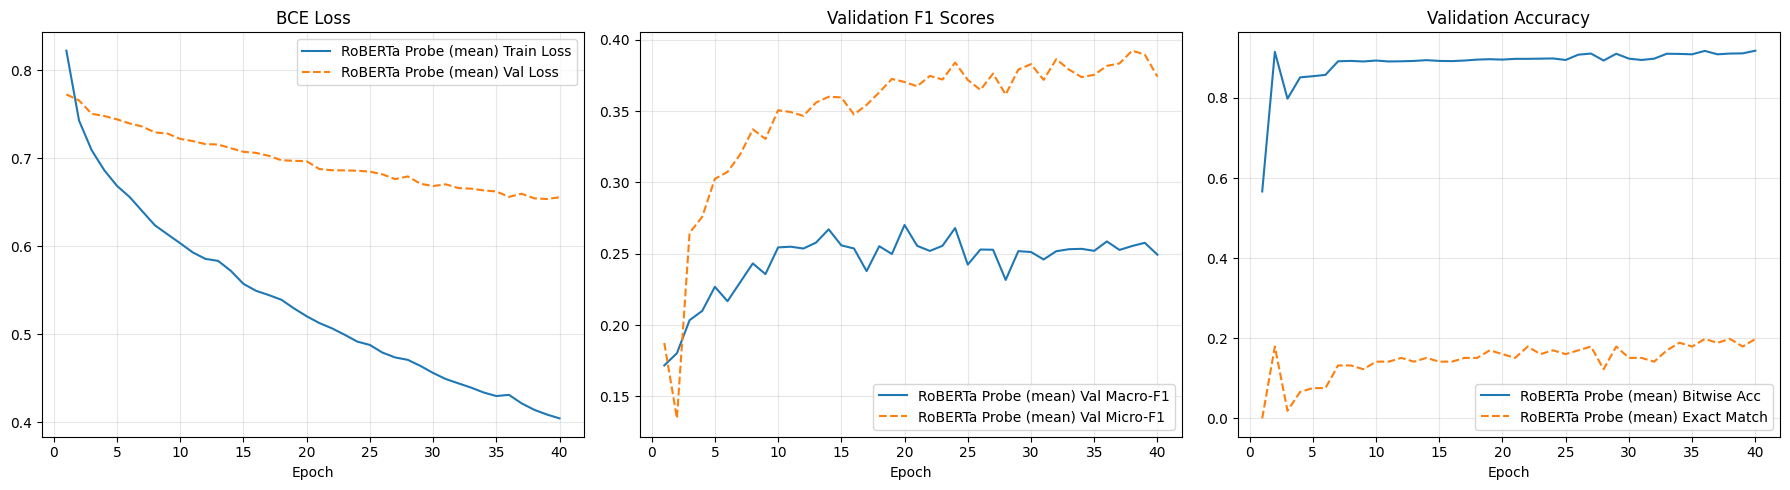


--- Final Test Evaluation ---
Best Validation Epoch: 20
Best Validation Macro-F1: 0.270
Validation Threshold:     0.70
Test Macro-F1:            0.267
Test Micro-F1:            0.420
Test Accuracy:            0.906
Test Exact Match:         0.115


In [ ]:
#[1]base linear probing RoBERTa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Split
# ------------------------------------------------------------------------------
# Filter out classes with 0 positives and ensure clean lists
observed_labels = {l for ls in df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]

keep_set = set(CLASSES)
clean_labels = [[l for l in ls if l in keep_set] for ls in df["labels"]]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep all rows, including memes with no technique
has_label = np.ones(len(Y), dtype=bool)

Y_strat = np.hstack([Y, (Y.sum(axis=1) == 0)[:, None]])  

texts = [t for t, k in zip(df["text"].astype(str), has_label) if k]
Y = Y[has_label]

idx = np.arange(len(texts))

#MultilabelStratifiedShuffleSplit
tr, tmp = next(MSSS(n_splits=1, test_size=0.30, random_state=SEED).split(idx, Y_strat))
v, t = next(MSSS(n_splits=1, test_size=0.50, random_state=SEED).split(tmp, Y_strat[tmp]))
va, te = tmp[v], tmp[t]

X_tr_text, y_train = [texts[i] for i in tr], Y[tr]
X_va_text, y_val = [texts[i] for i in va], Y[va]
X_te_text, y_test = [texts[i] for i in te], Y[te]


# ------------------------------------------------------------------------------
# 2. Feature Extraction & Normalization
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=MAX_LENGTH, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features...")
train_feats = extract_features(X_tr_text)
val_feats = extract_features(X_va_text)
test_feats = extract_features(X_te_text)

# Choose pooling type ('mean' or 'cls')
POOLING = "mean"
X_tr, X_va, X_te = train_feats[POOLING], val_feats[POOLING], test_feats[POOLING]

# Standardize using TRAIN statistics only
mu, sd = X_tr.mean(axis=0, keepdims=True), X_tr.std(axis=0, keepdims=True) + 1e-6
X_tr_norm = (X_tr - mu) / sd
X_va_norm = (X_va - mu) / sd
X_te_norm = (X_te - mu) / sd

# ------------------------------------------------------------------------------
# 3. Dataset & Model Definition
# ------------------------------------------------------------------------------

train_ds = FeatureDataset(X_tr_norm, y_train)
val_ds = FeatureDataset(X_va_norm, y_val)
test_ds = FeatureDataset(X_te_norm, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Tamed pos_weights calculation
pos_counts = y_train.sum(axis=0)
pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)

#BCEWithLogitsLoss is used for multi label classification - to handle multiple independant tags at the same time
#pos_weight only applies to +'ve weights of a particular class and balances the ratio of the single binary decision:
#for example - ground truth =1 -> loss is x's pos_weight, else =0 -> weight not applied, hence focuses on the things
#that are in label setup
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# ------------------------------------------------------------------------------
# 4. Metric Utilities & Training Functions
# ------------------------------------------------------------------------------
THRESHOLDS = np.arange(0.05, 0.96, 0.05)

# ------------------------------------------------------------------------------
# 5. Execution
# ------------------------------------------------------------------------------
probe_model = LinearProbe(
    in_features=X_tr_norm.shape[1],
    num_classes=len(CLASSES)
).to(device)

optimizer = optim.Adam(
    probe_model.parameters(),
    lr=1e-3
)

history, best_info = run_experiment(
    probe_model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=EPOCHS_AMT,
    patience=PATIENCE_AMT,
    name=f"RoBERTa Probe ({POOLING})"
)

# Store experiment results
all_results[f"RoBERTa Probe ({POOLING})"] = {
    "history": history,
    "best_info": best_info
}

# Plot training history
plot_experiments(all_results)

# ------------------------------------------------------------------------------
# Final Test Evaluation
# Use ONLY the threshold selected on the validation set
# ------------------------------------------------------------------------------
test_res = evaluate_model(
    probe_model,
    test_loader,
    criterion,
    threshold=best_info["thr"]
)

print("\n--- Final Test Evaluation ---")
print(f"Best Validation Epoch: {best_info['epoch']}")
print(f"Best Validation Macro-F1: {best_info['score']:.3f}")
print(f"Validation Threshold:     {best_info['thr']:.2f}")
print(f"Test Macro-F1:            {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:            {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:            {test_res['accuracy']:.3f}")
print(f"Test Exact Match:         {test_res['exact_match']:.3f}")

Extracting features for the entire dataset...

========== FOLD 1/5 ==========
[Fold_1] Epoch   1/100 | Train Loss: 0.7991 | Val Loss: 0.7829 | Val Macro-F1: 0.192 | Val Micro-F1: 0.256 | Val Acc: 0.746 | Val Exact: 0.042 | Threshold: 0.60
[Fold_1] Epoch  20/100 | Train Loss: 0.4383 | Val Loss: 0.6304 | Val Macro-F1: 0.222 | Val Micro-F1: 0.365 | Val Acc: 0.832 | Val Exact: 0.042 | Threshold: 0.55
[Fold_1] Epoch  40/100 | Train Loss: 0.2957 | Val Loss: 0.5631 | Val Macro-F1: 0.227 | Val Micro-F1: 0.403 | Val Acc: 0.852 | Val Exact: 0.076 | Threshold: 0.50
[Fold_1] Early stopping at epoch 55. Best epoch: 35, Best Val Macro-F1: 0.251, Best Threshold: 0.60

========== FOLD 2/5 ==========
[Fold_2] Epoch   1/100 | Train Loss: 0.7991 | Val Loss: 0.7543 | Val Macro-F1: 0.202 | Val Micro-F1: 0.264 | Val Acc: 0.835 | Val Exact: 0.104 | Threshold: 0.65
[Fold_2] Epoch  20/100 | Train Loss: 0.4335 | Val Loss: 0.6274 | Val Macro-F1: 0.253 | Val Micro-F1: 0.421 | Val Acc: 0.895 | Val Exact: 0.148 | T

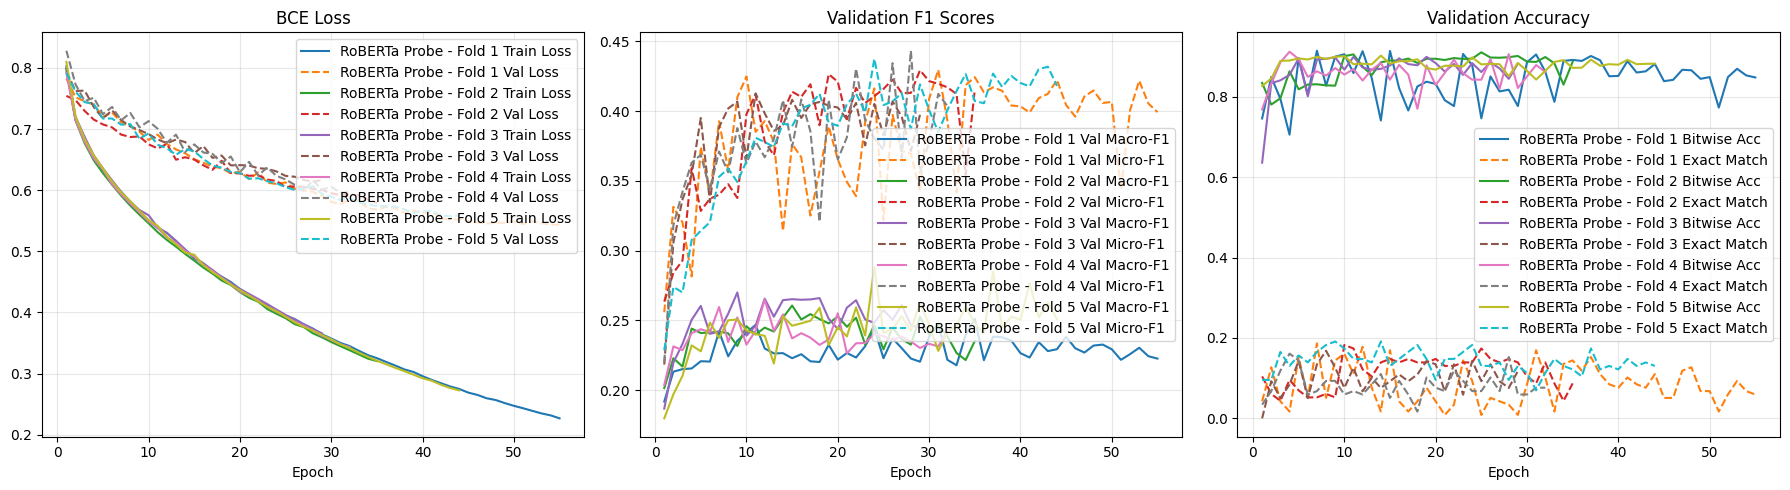


--- Cross Validation Summary (5 Folds) ---
Average Val Macro-F1: 0.267
Average Val Micro-F1: 0.410

Evaluating on Final Hold-out Test Set using model from RoBERTa Probe - Fold 5...

--- Final Test Evaluation ---
Test Macro-F1:  0.349
Test Micro-F1:  0.479
Test Accuracy:  0.900
Exact Match:    0.087


In [ ]:
#apply kfold validation with the df_augmented_combined dataset kfold stratification

# Make sure you have imported the iterative stratification modules
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

# Set seed & device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Setup
# ------------------------------------------------------------------------------
observed_labels = {l for ls in df_augmented_combined["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]
keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in df_augmented_combined["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep all rows including ones with no label
has_label = np.ones(len(Y), dtype=bool)

#Capture the original indices from the dataframe for mapping later
texts = df_augmented_combined.loc[has_label, "text"].astype(str).tolist()
valid_df_indices = df_augmented_combined.index[has_label].to_numpy()
Y = Y[has_label]

idx = np.arange(len(texts))

# ------------------------------------------------------------------------------
# 2. Feature Extraction (Optimized: Done once for ALL text)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=MAX_LENGTH, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features for the entire dataset...")
all_feats = extract_features(texts)

POOLING = "mean"
X_all = all_feats[POOLING]

# ------------------------------------------------------------------------------
# 3. split ORIGINAL memes,
#    then add augmented copies to the TRAIN side only
# ------------------------------------------------------------------------------
ids = df_augmented_combined.loc[has_label, "id"].astype(str)
is_aug = ids.str.endswith("_aug_de").to_numpy()
groups = ids.str.replace(r"_aug_de$", "", regex=True).to_numpy()   # aug copy -> its original's id
orig_idx = np.where(~is_aug)[0]

# extra "no technique" column, for splitting only
Y_strat = np.hstack([Y, (Y.sum(axis=1) == 0)[:, None]])

# A. Hold out 15% of ORIGINAL memes as the final test set (no augmented text in test)
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
o_tv, o_te = next(msss.split(orig_idx, Y_strat[orig_idx]))
idx_test = orig_idx[o_te]
tv_orig = orig_idx[o_tv]

X_test, y_test = X_all[idx_test], Y[idx_test]

# B. 5-fold CV on the remaining originals
K_FOLDS = 5
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

cv_splits = []
for tr, va in mskf.split(tv_orig, Y_strat[tv_orig]):
    train_idx = np.where(np.isin(groups, groups[tv_orig[tr]]))[0]  # originals + their aug copies
    val_idx = tv_orig[va]                                           # originals only
    cv_splits.append((train_idx, val_idx))

experiment_splits = {
    "test_indices": valid_df_indices[idx_test].tolist(),
    "cv_folds": {}
}

# ------------------------------------------------------------------------------
# 4. K-Fold Execution Loop
# ------------------------------------------------------------------------------
fold_results = {}
fold_models = []
fold_criterions = []

all_results_fold = {} # Assuming this holds results for plot_experiments

for fold, (train_idx, val_idx) in enumerate(cv_splits):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    original_train_idx = valid_df_indices[train_idx].tolist()
    original_val_idx = valid_df_indices[val_idx].tolist()
    
    experiment_splits["cv_folds"][f"fold_{fold+1}"] = {
        "train_indices": original_train_idx,
        "val_indices": original_val_idx
    }
    
    X_tr, y_train = X_all[train_idx], Y[train_idx]
    X_va, y_val = X_all[val_idx], Y[val_idx]

    # Standardize using current fold's TRAIN statistics
    mu = X_tr.mean(axis=0, keepdims=True)
    sd = X_tr.std(axis=0, keepdims=True) + 1e-6
    X_tr_norm = (X_tr - mu) / sd
    X_va_norm = (X_va - mu) / sd

    train_ds = FeatureDataset(X_tr_norm, y_train)
    val_ds = FeatureDataset(X_va_norm, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Dynamic pos_weights for current fold
    pos_counts = y_train.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
    optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

    history, best_info = run_experiment(
        probe_model, optimizer, criterion, train_loader, val_loader,
        epochs=EPOCHS_AMT, patience=PATIENCE_AMT, name=f"Fold_{fold+1}"
    )

    # Store results for this fold
    fold_name = f"RoBERTa Probe - Fold {fold+1}"
    all_results_fold[fold_name] = {
        "history": history,
        "best_info": best_info,
    }

# Get the 0-based index of the best epoch to retrieve other metrics
    best_epoch_idx = best_info["epoch"] - 1 

    fold_results[fold_name] = {
        "macro_f1": best_info["score"], # 'score' holds the best macro_f1
        "micro_f1": history["val_micro"][best_epoch_idx], # Retrieve from history
        "thr": best_info["thr"],
        "mu": mu,
        "sd": sd
    }

    # Keep copies of models/criterions for final test set evaluation
    fold_models.append(copy.deepcopy(probe_model.state_dict()))
    fold_criterions.append(criterion)

# Plot training curves for all folds
plot_experiments(all_results_fold)

# ------------------------------------------------------------------------------
# 5. Final Evaluation
# ------------------------------------------------------------------------------
# Calculate average CV metrics
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select the best performing model from the CV process for the hold-out test
best_fold_idx = np.argmax([res["macro_f1"] for res in fold_results.values()])
best_fold_name = f"RoBERTa Probe - Fold {best_fold_idx+1}"
print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name}...")

# Normalize test set strictly using the BEST fold's statistics
best_mu = fold_results[best_fold_name]["mu"]
best_sd = fold_results[best_fold_name]["sd"]
best_thr = fold_results[best_fold_name]["thr"]

X_te_norm = (X_test - best_mu) / best_sd

test_ds = FeatureDataset(X_te_norm, y_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
#init model
best_model = LinearProbe(in_features=X_te_norm.shape[1], num_classes=len(CLASSES)).to(device)
#load saved state
best_model.load_state_dict(fold_models[best_fold_idx])

# Load the saved state_dict into the model
best_criterion = fold_criterions[best_fold_idx]

test_res = evaluate_model(best_model, test_loader, best_criterion, threshold=best_thr)

results_scores['RoBERTa linear Probe: train, augmented'] = {
    "macro_f1": test_res["macro_f1"],
    "micro_f1": test_res["micro_f1"],
    "accuracy": test_res["accuracy"],
    "exact_match": test_res["exact_match"],
}

print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [ ]:
'''
################ Save the splits to disk for future experiments ################
with open("dataset_splits.json", "w") as f:
    json.dump(experiment_splits, f, indent=4)
    
print("\nSplits successfully saved to 'dataset_splits.json'")
################################################################################################

################  to load from disk ################
with open("dataset_splits.json", "r") as f:
    saved_splits = json.load(f)

# Reconstruct Test Set
test_df = df_augmented_combined.loc[saved_splits["test_indices"]]

# Reconstruct Fold 1 Train/Val sets
fold1_train = df_augmented_combined.loc[saved_splits["cv_folds"]["fold_1"]["train_indices"]]
fold1_val = df_augmented_combined.loc[saved_splits["cv_folds"]["fold_1"]["val_indices"]]
################################################################################################
'''

'\n################ Save the splits to disk for future experiments ################\nwith open("dataset_splits.json", "w") as f:\n    json.dump(experiment_splits, f, indent=4)\n    \nprint("\nSplits successfully saved to \'dataset_splits.json\'")\n################################################################################################\n\n################  to load from disk ################\nwith open("dataset_splits.json", "r") as f:\n    saved_splits = json.load(f)\n\n# Reconstruct Test Set\ntest_df = df_augmented_combined.loc[saved_splits["test_indices"]]\n\n# Reconstruct Fold 1 Train/Val sets\nfold1_train = df_augmented_combined.loc[saved_splits["cv_folds"]["fold_1"]["train_indices"]]\nfold1_val = df_augmented_combined.loc[saved_splits["cv_folds"]["fold_1"]["val_indices"]]\n################################################################################################\n'

### Step 2: Fine-tuning — Transfer learning - unfreeze the backbone and continue training the Combined Data set

Pre-tokenizing entire dataset in batch mode...

========== FOLD 1/5 ==========
Phase 1: Linear Probing (Classifier Head Only)...
[Fold_1_Probe] Epoch   1/5 | Train Loss: 0.5522 | Val Loss: 0.5182 | Val Macro-F1: 0.178 | Val Micro-F1: 0.236 | Val Acc: 0.504 | Val Exact: 0.000 | Threshold: 0.15
Transitioning to Phase 2: Injecting LoRA Adapters...
trainable params: 900,884 || all params: 125,561,896 || trainable%: 0.7175
Phase 2: Fine-Tuning with LoRA...
[Fold_1_FT_LoRA] Epoch   1/20 | Train Loss: 0.4347 | Val Loss: 0.4702 | Val Macro-F1: 0.206 | Val Micro-F1: 0.488 | Val Acc: 0.878 | Val Exact: 0.102 | Threshold: 0.35
[Fold_1_FT_LoRA] Early stopping at epoch 16. Best epoch: 11, Best Val Macro-F1: 0.294, Best Threshold: 0.50

========== FOLD 2/5 ==========
Phase 1: Linear Probing (Classifier Head Only)...
[Fold_2_Probe] Epoch   1/5 | Train Loss: 0.5503 | Val Loss: 0.5244 | Val Macro-F1: 0.155 | Val Micro-F1: 0.233 | Val Acc: 0.459 | Val Exact: 0.000 | Threshold: 0.15
Transitioning to Phas

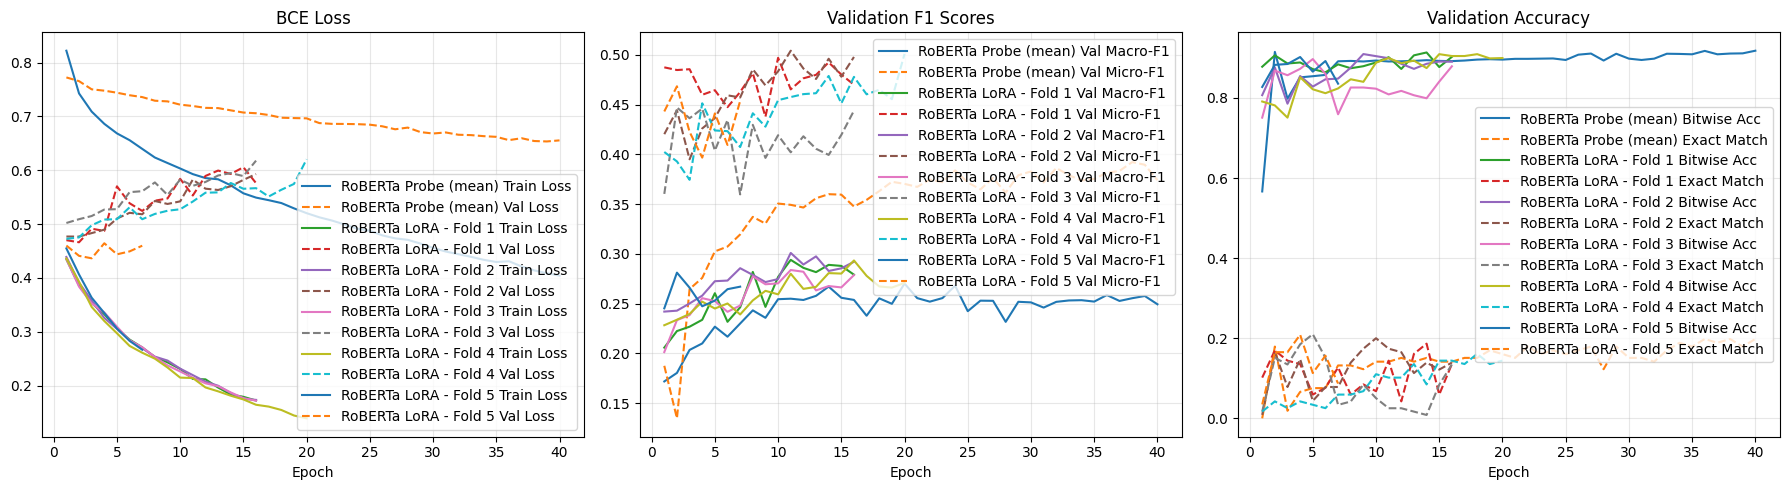


--- Cross Validation Summary (5 Folds) ---
Average Val Macro-F1: 0.291
Average Val Micro-F1: 0.464

Evaluating on Final Hold-out Test Set using model from RoBERTa LoRA - Fold 2 (Threshold: 0.350)...

--- Final Test Evaluation ---
Test Macro-F1:  0.527
Test Micro-F1:  0.650
Test Accuracy:  0.927
Exact Match:    0.291


In [ ]:
# Define LoRA Configuration once so it can be reused in Step 3 and Step 4
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)


# ------------------------------------------------------------------------------
# 1. Pre-Tokenization (Done ONCE for the whole dataset)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Pre-tokenizing entire dataset in batch mode...")
full_encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

class PreTokenizedDataset(Dataset):
    def __init__(self, encodings, labels, indices):
        self.input_ids = encodings["input_ids"][indices]
        self.attention_mask = encodings["attention_mask"][indices]
        self.labels = torch.tensor(labels[indices], dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

# ------------------------------------------------------------------------------
# 2. Re-use Data Splits from Step 1
# ------------------------------------------------------------------------------
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_tv, idx_test = next(msss.split(idx, Y))

y_tv, y_test = Y[idx_tv], Y[idx_test]

# Test Dataset Setup (batch_size=16 for safety)
test_ds = PreTokenizedDataset(full_encodings, Y, idx_test)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

K_FOLDS = 5

# ------------------------------------------------------------------------------
# 3. K-Fold Execution Loop (Linear Probing -> LoRA Fine-Tuning)
# ------------------------------------------------------------------------------
fold_results = {}
fold_state_dicts = []
fold_criterions = []

for fold, (global_train_idx, global_val_idx) in enumerate(cv_splits):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    train_ds = PreTokenizedDataset(full_encodings, Y, global_train_idx)
    val_ds = PreTokenizedDataset(full_encodings, Y, global_val_idx)

    # Batch size set to 16 to avoid CUDA OOM
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    # Dynamic Pos-Weights for current fold
    y_train_fold = Y[global_train_idx]
    pos_counts = y_train_fold.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train_fold) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    # Initialize fresh base model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(CLASSES),
        problem_type="multi_label_classification"
    ).to(device)

    # ==========================================
    # PHASE 1: LINEAR PROBING
    # ==========================================
    for param in model.base_model.parameters():
        param.requires_grad = False

    print("Phase 1: Linear Probing (Classifier Head Only)...")
    probe_optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-3
    )
    
    probe_history, _ = run_experiment(
        model, probe_optimizer, criterion, train_loader, val_loader,
        epochs=5, name=f"Fold_{fold+1}_Probe"
    )

    # ==========================================
    # TRANSITION: INJECT LORA ADAPTERS
    # ==========================================
    print("Transitioning to Phase 2: Injecting LoRA Adapters...")
    
    # Clear cache to free up RAM before attaching LoRA
    torch.cuda.empty_cache()
    gc.collect()

    # Wrap the model (which now has a trained Phase 1 classifier head) with LoRA
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    # ==========================================
    # PHASE 2: FINE-TUNING (LoRA + Classifier Head)
    # ==========================================
    print("Phase 2: Fine-Tuning with LoRA...")
    ft_optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-4, 
        weight_decay=0.01
    )

    ft_history, ft_best_info = run_experiment(
        model, ft_optimizer, criterion, train_loader, val_loader,
        epochs=20, patience=5, name=f"Fold_{fold+1}_FT_LoRA"
    )

    fold_name = f"RoBERTa LoRA - Fold {fold+1}"
    all_results[fold_name] = {
        "history": ft_history,
        "best_info": ft_best_info,
    }

    best_epoch_idx = ft_best_info["epoch"] - 1

    fold_results[fold_name] = {
        "macro_f1": ft_best_info["score"],
        "micro_f1": ft_history["val_micro"][best_epoch_idx],
        "thr": ft_best_info.get("thr", 0.5),
    }

    # Store state dict on CPU to save GPU RAM
    if "best_state_dict" in ft_best_info:
        cpu_state_dict = {k: v.cpu() for k, v in ft_best_info["best_state_dict"].items()}
        fold_state_dicts.append(copy.deepcopy(cpu_state_dict))
    else:
        fold_state_dicts.append(copy.deepcopy(model.cpu().state_dict()))

    fold_criterions.append(criterion)

plot_experiments(all_results)

# ------------------------------------------------------------------------------
# 4. Final Evaluation on Hold-Out Test Set
# ------------------------------------------------------------------------------
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select best performing model fold
best_fold_idx = int(np.argmax([res["macro_f1"] for res in fold_results.values()]))
best_fold_name = f"RoBERTa LoRA - Fold {best_fold_idx+1}"
best_thr = fold_results[best_fold_name]["thr"]

print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name} (Threshold: {best_thr:.3f})...")

# 1. Initialize clean base model
best_base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CLASSES),
    problem_type="multi_label_classification"
)

# 2. Wrap base model with LoRA so structure matches saved state dict
best_model = get_peft_model(best_base_model, lora_config).to(device)

# 3. Load saved weights into the LoRA model
best_model.load_state_dict(fold_state_dicts[best_fold_idx])
best_criterion = fold_criterions[best_fold_idx]

# Evaluate using tuned threshold
test_res = evaluate_model(best_model, test_loader, best_criterion, threshold=best_thr)

# Store results
results_scores['RoBERTa LoRA Fine-Tuned: train, augmented'] = {
    "macro_f1": test_res["macro_f1"],
    "micro_f1": test_res["micro_f1"],
    "accuracy": test_res["accuracy"],
    "exact_match": test_res["exact_match"],
}

print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

### Step 3: Fine-tuning — Regularization techniques: Best Drop out, Best Weight Decay, Optimaization: Best Learning Technique

In [ ]:
import gc
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from transformers import AutoConfig, AutoModelForSequenceClassification
from peft import LoraConfig, TaskType, get_peft_model

def run_kfold_twostage(
    d_rate=0.1,
    weight_decay=0.01,
    ft_lr=1e-4,
    p1_epochs=2,
    p2_epochs=2,
    k_folds=5
):
    """
    Runs a fast K-Fold cross-validation over Phase 1 (Linear Probe) and Phase 2 (LoRA)
    for a given set of hyperparameters.
    """
    fold_f1_scores = []

    for fold, (global_train_idx, global_val_idx) in enumerate(cv_splits):

        train_ds = PreTokenizedDataset(full_encodings, Y, global_train_idx)
        val_ds = PreTokenizedDataset(full_encodings, Y, global_val_idx)

        train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

        # Class weights calculation
        y_train_fold = Y[global_train_idx]
        pos_counts = y_train_fold.sum(axis=0)
        pos_weights_arr = np.sqrt((len(y_train_fold) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
        pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

        # 1. Load RoBERTa Config with tuned Dropout Rate
        config = AutoConfig.from_pretrained(
            MODEL_NAME,
            num_labels=len(CLASSES),
            problem_type="multi_label_classification",
            classifier_dropout=d_rate,
            hidden_dropout_prob=d_rate
        )

        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            config=config
        ).to(device)

        # ----------------------------
        # PHASE 1: LINEAR PROBING
        # ----------------------------
        for param in model.base_model.parameters():
            param.requires_grad = False

        probe_optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
        
        _, _ = run_experiment(
            model, probe_optimizer, criterion, train_loader, val_loader,
            epochs=p1_epochs, name=f"Search_P1_Fold{fold+1}"
        )

        # ----------------------------
        # PHASE 2: LoRA FINE-TUNING
        # ----------------------------
        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=8,
            lora_alpha=16,
            lora_dropout=d_rate,  # Apply dropout to LoRA adapters as well
            target_modules=["query", "value"]
        )

        model = get_peft_model(model, lora_config)

        ft_optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=ft_lr,
            weight_decay=weight_decay
        )

        # Cosine Annealing Scheduler
        # T_max is usually the total number of epochs (or total steps if stepping per batch)
        ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            ft_optimizer, 
            T_max=p2_epochs, 
            eta_min=1e-6 # The minimum learning rate it will decay to
        )

        ft_history, ft_best_info = run_experiment(
            model, ft_optimizer, criterion, train_loader, val_loader,
            epochs=p2_epochs, patience=5, name=f"Search_P2_Fold{fold+1}",
            scheduler=ft_scheduler
        )

        # Save best macro F1 score for this fold
        fold_f1_scores.append(ft_best_info["score"])

        # Prevent GPU memory leak between folds
        del model, ft_optimizer, probe_optimizer, train_loader, val_loader, train_ds, val_ds
        torch.cuda.empty_cache()
        gc.collect()

    return np.mean(fold_f1_scores)

In [ ]:
# 1: Best Dropout Search for RoBERTa
dropout_rates = [0.00, 0.05, 0.10, 0.15] # Adjusted for typical NLP ranges
dropout_results = {}

print("Stage 1: Tune Dropout for RoBERTa LoRA")
best_macro_f1 = -1.0
best_dropout = dropout_rates[0]

for d_rate in dropout_rates:
    print(f"\n{'='*40}")
    print(f"Testing Dropout = {d_rate}")
    print(f"{'='*40}")
    
    # Ensure reproducibility for each run
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # ⚡ FAST SEARCH: Call your custom RoBERTa function
    # It already handles model initialization, looping folds, and VRAM cleanup
    avg_macro_f1 = run_kfold_twostage(
        d_rate=d_rate,
        weight_decay=0.01,
        ft_lr=1e-4,
        p1_epochs=2,  # Short epochs for fast search
        p2_epochs=2,  
        k_folds=5
    )
    
    dropout_results[f"Drop={d_rate}"] = avg_macro_f1
    print(f"Avg CV Macro F1 for Dropout {d_rate}: {avg_macro_f1:.4f}")
    
    # Track the best score
    if avg_macro_f1 > best_macro_f1:
        best_macro_f1 = avg_macro_f1
        best_dropout = d_rate
        
    # ⚡ PREVENT MEMORY BOTTLENECK: Clear VRAM
    torch.cuda.empty_cache()
    gc.collect()

print(f"\n✅ Best Dropout selected for Step 2: {best_dropout} (Macro F1: {best_macro_f1:.4f})")
print("Results summary:", dropout_results)

Stage 1: Tune Dropout for RoBERTa LoRA

Testing Dropout = 0.0
[Search_P1_Fold1] Epoch   1/2 | Train Loss: 0.5721 | Val Loss: 0.5319 | Val Macro-F1: 0.205 | Val Micro-F1: 0.269 | Val Acc: 0.433 | Val Exact: 0.000 | Threshold: 0.15
[Search_P2_Fold1] Epoch   1/2 | Train Loss: 0.4898 | Val Loss: 0.5041 | Val Macro-F1: 0.265 | Val Micro-F1: 0.380 | Val Acc: 0.677 | Val Exact: 0.000 | Threshold: 0.20
[Search_P1_Fold2] Epoch   1/2 | Train Loss: 0.5518 | Val Loss: 0.5456 | Val Macro-F1: 0.175 | Val Micro-F1: 0.196 | Val Acc: 0.153 | Val Exact: 0.000 | Threshold: 0.05
[Search_P2_Fold2] Epoch   1/2 | Train Loss: 0.4778 | Val Loss: 0.5228 | Val Macro-F1: 0.236 | Val Micro-F1: 0.372 | Val Acc: 0.688 | Val Exact: 0.000 | Threshold: 0.20
[Search_P1_Fold3] Epoch   1/2 | Train Loss: 0.5664 | Val Loss: 0.5414 | Val Macro-F1: 0.224 | Val Micro-F1: 0.303 | Val Acc: 0.495 | Val Exact: 0.000 | Threshold: 0.15
[Search_P2_Fold3] Epoch   1/2 | Train Loss: 0.5114 | Val Loss: 0.5226 | Val Macro-F1: 0.222 | Val 

In [ ]:
# 2: Best Weight Decay Search for RoBERTa
weight_decays = [0.0, 1e-4, 1e-3, 0.01] # Added 0.01 since it was default in your function
wd_results = {}

print(f"\nStage 2: Tune Weight Decay (Using Best Dropout: {best_dropout})")
best_macro_f1_wd = -1.0
best_wd = weight_decays[0]

for w_d in weight_decays:
    print(f"\n{'='*40}")
    print(f"Testing Weight Decay = {w_d}")
    print(f"{'='*40}")
    
    # Ensure reproducibility for each run
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # ⚡ FAST SEARCH: Call your custom RoBERTa function
    # Passing best_dropout from Stage 1 and iterating over w_d
    avg_macro_f1 = run_kfold_twostage(
        d_rate=best_dropout,
        weight_decay=w_d,
        ft_lr=1e-4,
        p1_epochs=2,  # Short epochs for fast search
        p2_epochs=2,  
        k_folds=5
    )
    
    wd_results[f"WD={w_d}"] = avg_macro_f1
    print(f"Avg CV Macro F1 for Weight Decay {w_d}: {avg_macro_f1:.4f}")
    
    # Track the best score based on Macro F1 (higher is better)
    if avg_macro_f1 > best_macro_f1_wd:
        best_macro_f1_wd = avg_macro_f1
        best_wd = w_d
        
    # ⚡ PREVENT MEMORY BOTTLENECK: Clear VRAM
    torch.cuda.empty_cache()
    gc.collect()

print(f"\n✅ Best Weight Decay selected for Step 3: {best_wd} (Macro F1: {best_macro_f1_wd:.4f})")
print("Results summary:", wd_results)

In [ ]:
# 3: Best Learning Rate Search for RoBERTa
learning_rates = [1e-5, 3e-5, 5e-5, 1e-4] # Added 1e-4 as it was the default earlier

lr_results = {}

print(f"\nStage 3: Tune Learning Rate (Drop={best_dropout}, WD={best_wd})")
best_macro_f1_lr = -1.0
best_lr = learning_rates[0]

for lr in learning_rates:
    print(f"\n{'='*40}")
    print(f"Testing Learning Rate = {lr}")
    print(f"{'='*40}")
    
    # Ensure reproducibility
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # ⚡ FAST SEARCH: Call your custom RoBERTa function
    avg_macro_f1 = run_kfold_twostage(
        d_rate=best_dropout,
        weight_decay=best_wd,
        ft_lr=lr,
        p1_epochs=5,  # Increased to 5 as requested in your snippet
        p2_epochs=5,  
        k_folds=5
    )
    
    lr_results[f"LR={lr}"] = avg_macro_f1
    print(f"Avg CV Macro F1 for LR {lr}: {avg_macro_f1:.4f}")
    
    if avg_macro_f1 > best_macro_f1_lr:
        best_macro_f1_lr = avg_macro_f1
        best_lr = lr

    # Clear VRAM
    torch.cuda.empty_cache()
    gc.collect()

print(f"\n✅ Best fine-tuned learning rate: {best_lr} (Macro F1: {best_macro_f1_lr:.4f})")
print(f"Best Config: Dropout={best_dropout}, WD={best_wd}, Peak LR={best_lr}")
print("Results summary:", lr_results)

### 3.3 Part B — Showing the student where

* With Multi-Label Token Classification, spans can overlap for example a string might be "Name-Calling" and over lap with "Loaded Language".
* Consistency: Using two separate models can lead to contradictory predictions. For instance, the Part A model might classify a meme as containing “Name-Calling,”
  while the Part B model identifies no spans associated with that technique. Using a single model ensures that the document-level and token-level predictions maintains consistentcy.
* Efficiency: Training and maintaining a single RoBERTa model reduces memory usage and computational costs compared with training separate sequence-classification and token-classification models.
* Architecture Choice: A multi-label token-classification model, as used in Part B, can also work with Part A without requiring a separate model. If at least one token is predicted to contain a particular technique, then the meme can be considered to contain that technique. Therefore, document-level predictions can be obtained by applying a logical OR (or equivalently, taking the mathematical max()) across the token-level predictions.

In [ ]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import gc
import copy
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaPreTrainedModel, RobertaTokenizerFast, AutoConfig
from peft import get_peft_model, LoraConfig, TaskType
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

# ==============================================================================
# Global Configuration & Constants
# ==============================================================================
MODEL_NAME = "roberta-base"
MAX_LENGTH = 512
SEED = 42
K_FOLDS = 5
THRESHOLDS = np.arange(0.1, 0.9, 0.05)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_results = {}

# ==============================================================================
# 1. Custom Model Definition
# ==============================================================================
class RobertaForMultiLabelTokenClassification(RobertaPreTrainedModel):
    def __init__(self, config, pos_weight=None):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = RobertaModel(config, add_pooling_layer=False)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        self.pos_weight = pos_weight 
        
        # Initialize weights and set up attributes required by transformers v5+
        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = self.roberta(input_ids, attention_mask=attention_mask, **kwargs)
        sequence_output = self.dropout(outputs[0]) 
        logits = self.classifier(sequence_output)  
        
        loss = None
        if labels is not None:
            loss_fct = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)
            
            # Filter out padding/special tokens using the attention mask & -100 labels
            active_loss = (attention_mask.view(-1) == 1) & (labels.view(-1, self.num_labels)[:, 0] != -100)
            active_logits = logits.view(-1, self.num_labels)[active_loss]
            active_labels = labels.view(-1, self.num_labels)[active_loss]
            
            if active_logits.shape[0] > 0:
                loss = loss_fct(active_logits, active_labels.float())
            else:
                loss = torch.tensor(0.0, requires_grad=True).to(logits.device)
                
        return {"loss": loss, "logits": logits}

# ==============================================================================
# 2. Metric Utilities & Training Functions
# ==============================================================================
def f1_stats(y_true, y_pred):
    tp = (y_true * y_pred).sum(axis=0)
    fp = ((1 - y_true) * y_pred).sum(axis=0)
    fn = (y_true * (1 - y_pred)).sum(axis=0)

    den = 2 * tp + fp + fn
    per_class = np.divide(2 * tp, den, out=np.zeros_like(den, dtype=np.float64), where=den > 0)

    observed = y_true.sum(axis=0) > 0
    macro_f1 = float(per_class[observed].mean()) if observed.any() else 0.0
    micro_f1 = float(2 * tp.sum() / max(den.sum(), 1))
    exact_match = float((y_true == y_pred).all(axis=1).mean())
    accuracy = float((y_true == y_pred).mean())

    return macro_f1, micro_f1, exact_match, accuracy, per_class

def best_threshold(y_true, probs):
    scores = []
    for threshold in THRESHOLDS:
        preds = (probs >= threshold).astype(np.float32)
        macro_f1 = f1_stats(y_true, preds)[0]
        scores.append(macro_f1)

    best_idx = int(np.argmax(scores))
    return float(THRESHOLDS[best_idx]), float(scores[best_idx])

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs["loss"]
        
        if loss is not None and loss.requires_grad:
            loss.backward()
            optimizer.step()

            batch_size = len(labels)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / max(total_samples, 1)

def evaluate_model(model, loader, threshold=None):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_probs = []
    all_labels = []

    with torch.inference_mode():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs["loss"]
            logits = outputs["logits"]
            num_classes = logits.shape[-1]

            if loss is not None:
                batch_size = len(labels)
                total_loss += loss.item() * batch_size
                total_samples += batch_size

            # Flatten to valid active tokens only
            active_mask = (attention_mask.view(-1) == 1) & (labels.view(-1, num_classes)[:, 0] != -100)
            active_logits = logits.view(-1, num_classes)[active_mask]
            active_labels = labels.view(-1, num_classes)[active_mask]
            probs = torch.sigmoid(active_logits)

            all_probs.append(probs.cpu())
            all_labels.append(active_labels.cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    if threshold is None:
        threshold, _ = best_threshold(all_labels, all_probs)

    all_preds = (all_probs >= threshold).astype(np.float32)
    macro_f1, micro_f1, exact_match, accuracy, per_class_f1 = f1_stats(all_labels, all_preds)

    return {
        "loss": total_loss / max(total_samples, 1),
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "exact_match": exact_match,
        "accuracy": accuracy,
        "threshold": threshold,
        "per_class_f1": per_class_f1,
        "probs": all_probs,
        "targets": all_labels,
        "preds": all_preds,
    }

def run_experiment(model, optimizer, criterion, train_loader, val_loader, epochs=10, patience=5, name="Model", scheduler=None):
    history = {"train_loss": [], "val_loss": [], "val_macro": [], "val_micro": [], "val_exact": [], "val_accuracy": []}
    best_info = {"epoch": 0, "score": -1.0, "thr": 0.5, "state": None}
    epochs_no_improve = 0

    best_info["state"] = {k: v.detach().clone() for k, v in model.state_dict().items()}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_res = evaluate_model(model, val_loader, threshold=None)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_res["loss"])
        history["val_macro"].append(val_res["macro_f1"])
        history["val_micro"].append(val_res["micro_f1"])
        history["val_exact"].append(val_res["exact_match"])
        history["val_accuracy"].append(val_res["accuracy"])

        if val_res["macro_f1"] > best_info["score"] + 1e-4:
            best_info = {
                "epoch": epoch,
                "score": val_res["macro_f1"],
                "thr": val_res["threshold"],
                "state": {k: v.detach().clone() for k, v in model.state_dict().items()}
            }
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if scheduler is not None:
            scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f"[{name}] Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_res['loss']:.4f} | Val Macro-F1: {val_res['macro_f1']:.3f} | Val Micro-F1: {val_res['micro_f1']:.3f} | Threshold: {val_res['threshold']:.2f}")

        if epochs_no_improve >= patience:
            print(f"[{name}] Early stopping at epoch {epoch}. Best Val Macro-F1: {best_info['score']:.3f}")
            break

    model.load_state_dict(best_info["state"])
    return history, best_info

# ==============================================================================
# 3. Data Loading & Preprocessing
# ==============================================================================
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

print("Loading Task 2 Data...")
with open("training_set_task2.txt", "r", encoding="utf-8") as f:
    data = json.load(f)

unique_techniques = set(label["technique"] for item in data for label in item.get("labels", []))
techniques_list = sorted(list(unique_techniques))
label2id = {label: idx for idx, label in enumerate(techniques_list)}
CLASSES = techniques_list

texts = []
span_labels = []
doc_level_labels = []

for item in data:
    texts.append(item["text"])
    spans = []
    doc_label_vector = [0.0] * len(techniques_list)
    
    for label in item.get("labels", []):
        tech_idx = label2id[label["technique"]]
        spans.append({"start": label["start"], "end": label["end"], "class_id": tech_idx})
        doc_label_vector[tech_idx] = 1.0
        
    span_labels.append(spans)
    doc_level_labels.append(doc_label_vector)

Y = np.array(doc_level_labels)

# ==============================================================================
# 4. Token Dataset Class
# ==============================================================================
class Task2TokenDataset(Dataset):
    def __init__(self, texts, span_labels, tokenizer, max_len=512, num_classes=14):
        self.texts = texts
        self.span_labels = span_labels 
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.num_classes = num_classes

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        spans = self.span_labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_offsets_mapping=True,
            return_tensors='pt'
        )

        labels = torch.zeros((self.max_len, self.num_classes), dtype=torch.float)
        offsets = encoding['offset_mapping'][0]

        for i, (start_char, end_char) in enumerate(offsets):
            if start_char == 0 and end_char == 0:
                labels[i, :] = -100 
                continue
            for span in spans:
                if not (end_char <= span['start'] or start_char >= span['end']):
                    labels[i, span['class_id']] = 1.0

        item = {key: val.squeeze(0) for key, val in encoding.items() if key != 'offset_mapping'}
        item['labels'] = labels
        return item

full_dataset = Task2TokenDataset(texts, span_labels, tokenizer, MAX_LENGTH, len(CLASSES))

# ==============================================================================
# 5. Holdout & K-Fold Splitting
# ==============================================================================
# 1. Split 15% Holdout Test Set BEFORE Cross-Validation
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_cv, idx_test = next(msss.split(np.arange(len(Y)), Y))

test_ds = torch.utils.data.Subset(full_dataset, idx_test)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

# 2. Update Y to only contain the Cross-Validation indices
Y_cv = Y[idx_cv]

# 3. Create global CV splits using ONLY the 85% training data
kf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
cv_splits = []
for fold_train_idx, fold_val_idx in kf.split(np.arange(len(Y_cv)), Y_cv):
    # Map back to the original dataset indices
    cv_splits.append((idx_cv[fold_train_idx], idx_cv[fold_val_idx]))

# ==============================================================================
# 6. K-Fold Execution Loop
# ==============================================================================
lora_config = LoraConfig(
    task_type=TaskType.TOKEN_CLS, 
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

fold_results = {}
fold_state_dicts = []

for fold, (train_idx, val_idx) in enumerate(cv_splits):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    train_ds = torch.utils.data.Subset(full_dataset, train_idx)
    val_ds = torch.utils.data.Subset(full_dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    # Dynamic Pos-Weights (Calculated on document level for stability)
    y_train_fold = Y[train_idx]
    pos_counts = y_train_fold.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train_fold) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)

    # Initialize Custom Base Model for Token Classification
    config = AutoConfig.from_pretrained(MODEL_NAME, num_labels=len(CLASSES))
    model = RobertaForMultiLabelTokenClassification.from_pretrained(
        MODEL_NAME, 
        config=config, 
        pos_weight=pos_weights, 
        ignore_mismatched_sizes=True
    ).to(device)

    # ==========================================
    # PHASE 1: LINEAR PROBING
    # ==========================================
    for param in model.roberta.parameters():
        param.requires_grad = False

    print("Phase 1: Linear Probing (Classifier Head Only)...")
    probe_optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    
    probe_history, _ = run_experiment(
        model, probe_optimizer, None, train_loader, val_loader, 
        epochs=5, name=f"Fold_{fold+1}_Probe"
    )

    # ==========================================
    # PHASE 2: FINE-TUNING (LoRA + Classifier Head)
    # ==========================================
    print("Transitioning to Phase 2: Injecting LoRA Adapters...")
    torch.cuda.empty_cache()
    gc.collect()

    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    ft_optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=0.01)

    ft_history, ft_best_info = run_experiment(
        model, ft_optimizer, None, train_loader, val_loader,
        epochs=20, patience=5, name=f"Fold_{fold+1}_FT_LoRA"
    )
    fold_name = f"RoBERTa LoRA - Fold {fold+1}"
    all_results[fold_name] = {
        "history": ft_history,
        "best_info": ft_best_info,
    }

    best_epoch_idx = ft_best_info["epoch"] - 1

    fold_results[fold_name] = {
        "macro_f1": ft_best_info["score"],
        "micro_f1": ft_history["val_micro"][best_epoch_idx],
        "thr": ft_best_info.get("thr", 0.5),
    }

    # Store state dict directly from best_info to save RAM
    fold_state_dicts.append(copy.deepcopy(ft_best_info["state"]))
    

Loading Task 2 Data...

========== FOLD 1/5 ==========
Phase 1: Linear Probing (Classifier Head Only)...
[Fold_1_Probe] Epoch   1/5 | Train Loss: 0.5748 | Val Loss: 0.4097 | Val Macro-F1: 0.073 | Val Micro-F1: 0.076 | Threshold: 0.10
[Fold_1_Probe] Epoch   5/5 | Train Loss: 0.3382 | Val Loss: 0.3374 | Val Macro-F1: 0.086 | Val Micro-F1: 0.160 | Threshold: 0.15
Transitioning to Phase 2: Injecting LoRA Adapters...
trainable params: 310,292 || all params: 124,380,712 || trainable%: 0.2495
[Fold_1_FT_LoRA] Epoch   1/20 | Train Loss: 0.3296 | Val Loss: 0.3352 | Val Macro-F1: 0.089 | Val Micro-F1: 0.186 | Threshold: 0.15
[Fold_1_FT_LoRA] Epoch   5/20 | Train Loss: 0.2522 | Val Loss: 0.3131 | Val Macro-F1: 0.132 | Val Micro-F1: 0.282 | Threshold: 0.20
[Fold_1_FT_LoRA] Epoch  10/20 | Train Loss: 0.2102 | Val Loss: 0.2998 | Val Macro-F1: 0.160 | Val Micro-F1: 0.316 | Threshold: 0.30
[Fold_1_FT_LoRA] Epoch  15/20 | Train Loss: 0.1865 | Val Loss: 0.3074 | Val Macro-F1: 0.169 | Val Micro-F1: 0.343


--- Cross Validation Summary (5 Folds) ---
Average Val Macro-F1: 0.190
Average Val Micro-F1: 0.303

Evaluating on Final Hold-out Test Set using model from RoBERTa LoRA - Fold 3 (Threshold: 0.200)...

--- Final Test Evaluation ---
Test Macro-F1:  0.170
Test Micro-F1:  0.331
Test Accuracy:  0.921
Exact Match:    0.225


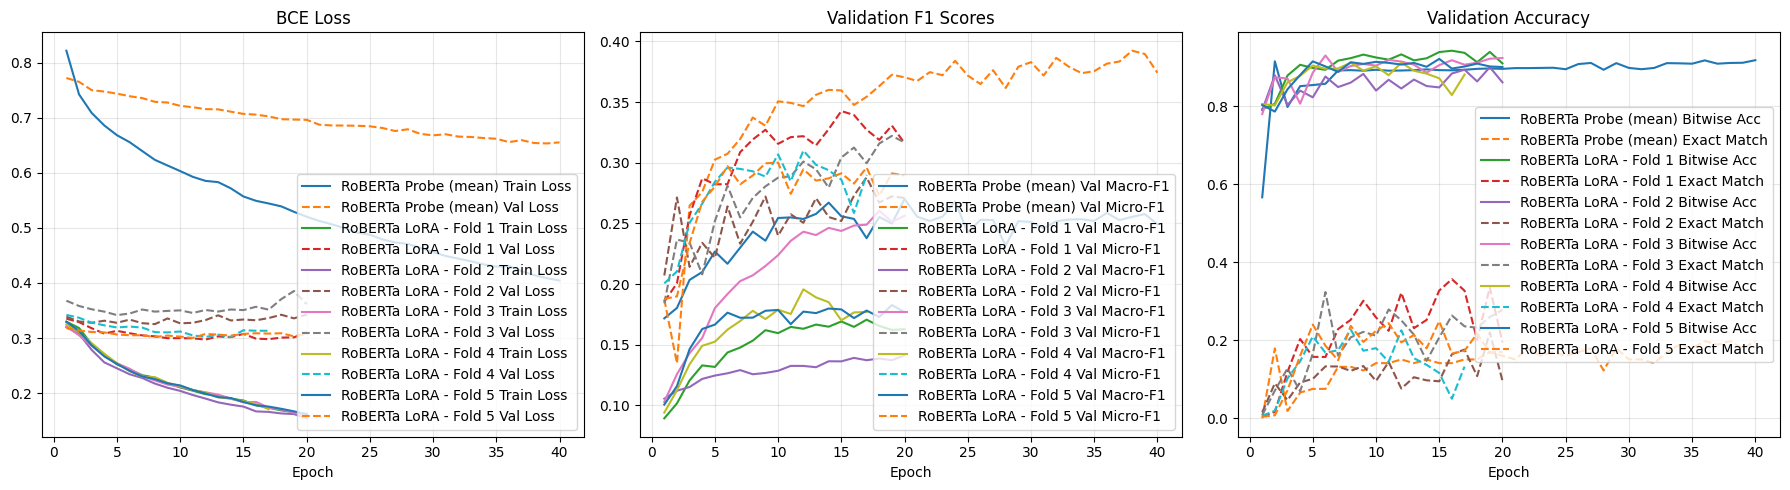

In [ ]:
# ==============================================================================
# 7. Final Evaluation on Hold-Out Test Set
# ==============================================================================
# Initialize results dictionary if it doesn't exist yet
if 'results_scores' not in locals():
    results_scores = {}

cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select best performing model fold
best_fold_idx = int(np.argmax([res["macro_f1"] for res in fold_results.values()]))
best_fold_name = f"RoBERTa LoRA - Fold {best_fold_idx+1}"
best_thr = fold_results[best_fold_name]["thr"]

print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name} (Threshold: {best_thr:.3f})...")

# 1. Initialize clean custom base model for Token Classification
# Note: pos_weight is required by __init__, but dummy 1s are fine for evaluation 
# since we only care about the prediction metrics on the test set, not the loss.
dummy_pos_weights = torch.ones(len(CLASSES), dtype=torch.float32).to(device)
config = AutoConfig.from_pretrained(MODEL_NAME, num_labels=len(CLASSES))

best_base_model = RobertaForMultiLabelTokenClassification.from_pretrained(
    MODEL_NAME, 
    config=config, 
    pos_weight=dummy_pos_weights, 
    ignore_mismatched_sizes=True
).to(device)

# 2. Wrap base model with LoRA so structure matches saved state dict
best_model = get_peft_model(best_base_model, lora_config).to(device)

# 3. Load saved weights into the LoRA model
best_model.load_state_dict(fold_state_dicts[best_fold_idx])

# 4. Evaluate using tuned threshold (Notice: no criterion passed!)
test_res = evaluate_model(best_model, test_loader, threshold=best_thr)

# Store results
results_scores['RoBERTa LoRA Fine-Tuned (Token Class)'] = {
    "macro_f1": test_res["macro_f1"],
    "micro_f1": test_res["micro_f1"],
    "accuracy": test_res["accuracy"],
    "exact_match": test_res["exact_match"],
}

print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

# Optional: plot your experiments if your plot function is defined
plot_experiments(all_results)

In [ ]:
######################################################

In [ ]:
'''
#### google.colab.  File paths
articles_dir = '/content/drive/MyDrive/assignment2/PTC-data/train-articles'
labels_file = '/content/drive/MyDrive/assignment2/PTC-data/train-task2-TC.labels'
'''

In [ ]:
#### File paths
articles_dir = 'PTC-data/train-articles'
labels_file = 'PTC-data/train-task2-TC.labels'

In [ ]:
#extract the text span from the articles to check with the span looks like

# 1. Read labels file directly
labels_df = pd.read_csv(
    labels_file,
    sep='\t',
    header=None,
    names=['article_id', 'label', 'start', 'end']
)
labels_df['article_id'] = labels_df['article_id'].astype(str)

# 2. Gather full article text contents
articles_data = []
for file_path in glob.glob(os.path.join(articles_dir, 'article*.txt')):
    filename = os.path.basename(file_path)
    article_id = filename.replace('article', '').replace('.txt', '')

    with open(file_path, 'r', encoding='utf-8') as file:
        text_content = file.read()

    articles_data.append({
        'article_id': article_id,
        'text': text_content
    })

articles_df = pd.DataFrame(articles_data)

# 3. Merge raw label entries with article texts
ptc_df = pd.merge(labels_df, articles_df, on='article_id', how='left')

# 4. Extract snippet by slicing text using character offsets
ptc_df['extracted_text'] = ptc_df.apply(
    lambda row: row['text'][int(row['start']):int(row['end'])] if pd.notna(row['text']) else '',
    axis=1
)

# 5. Clean up columns order
ptc_df = ptc_df[['article_id', 'label', 'start', 'end', 'extracted_text']]

# Display result
display(ptc_df.head())

We can see that the context is lost if only extracting the span text related to the label. MinD in (Da San Martino et al., 2020) mentions that there models performed particulary bad on certain labels such as "Repetition" (page 1086. Table. 7), Red Herring. They also used Sentence Boundary Segmentation where the split of the text is at the sentence level encapsulating the label position span and the start and end of that sentence.


In [ ]:

# Ensure the punkt tokenizer models are downloaded
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
tokenizer = PunktSentenceTokenizer()


# 1. Read labels file directly
labels_df = pd.read_csv(
    labels_file,
    sep='\t',
    header=None,
    names=['article_id', 'label', 'start', 'end']
)
labels_df['article_id'] = labels_df['article_id'].astype(str)

# 2. Gather full article texts AND perform sentence segmentation
sentence_data = []
for file_path in glob.glob(os.path.join(articles_dir, 'article*.txt')):
    filename = os.path.basename(file_path)
    article_id = filename.replace('article', '').replace('.txt', '')

    with open(file_path, 'r', encoding='utf-8') as file:
        text_content = file.read()

    # Use span_tokenize to get the start and end character indices of each sentence
    for sent_start, sent_end in tokenizer.span_tokenize(text_content):
        sentence_data.append({
            'article_id': article_id,
            'sent_start': sent_start,
            'sent_end': sent_end,
            'sentence_text': text_content[sent_start:sent_end]
        })

sentences_df = pd.DataFrame(sentence_data)

# 3. Create a dictionary of labels grouped by article_id for fast lookup
labels_dict = (
    labels_df.groupby('article_id')
    .apply(lambda x: x[['label', 'start', 'end']].to_dict('records'))
    .to_dict()
)

# 4. Map labels to sentences based on character offset overlap
def map_labels_to_sentence(row):
    art_id = row['article_id']
    sent_start = row['sent_start']
    sent_end = row['sent_end']

    if art_id not in labels_dict:
        return []

    matched_labels = []
    for lbl in labels_dict[art_id]:
        lbl_start = int(lbl['start'])
        lbl_end = int(lbl['end'])

        # Check for overlap: if max of starts < min of ends, the text spans intersect
        if max(sent_start, lbl_start) < min(sent_end, lbl_end):
            matched_labels.append(lbl['label'])

    # Return unique labels (in case multiple spans in one sentence have the same label)
    return list(set(matched_labels))

sentences_df['labels'] = sentences_df.apply(map_labels_to_sentence, axis=1)

# 5. Clean up columns and filter out sentences with no text (e.g., standalone newlines)
sentences_df = sentences_df[['article_id', 'sent_start', 'sent_end', 'sentence_text', 'labels']]
sentences_df = sentences_df[sentences_df['sentence_text'].str.strip().astype(bool)]

# Display result
display(sentences_df.head(10))

In [ ]:
#filter out empty label entries from sentence_df
positive_sentences_df = sentences_df[sentences_df['labels'].map(len) > 0].reset_index(drop=True)
display(positive_sentences_df.head())

some of the data has bad unnormal characters such as:

    "‚Äî bishops have a very grave responsibility."
These will be removed as they could cause issues in the model training


In [ ]:
positive_sentences_df['sentence_text'] = positive_sentences_df['sentence_text'].apply(ftfy.fix_text)
display(positive_sentences_df.head())

In [ ]:
print(positive_sentences_df.columns.tolist())

There are still issues that can be seen in the samples, example:
Article: 699478811,
label:['Appeal_to_fear-prejudice'],
text:  "Thus, it is threatening U.S."
From the main text: "Thus, it is threatening U.S. forces and bases in the region."

We can see that the sentence extraction logic has ended the sentence prematurally due to the full stop after U.S, "." and not included forces. This can be tricky as it is gramatically should be "threatening U.S forces..." hence it is not perfect but maybe there are enough good samples to over come the misleading cases.

In [ ]:
'''
#### google.colab. save to file
from google.colab import files
folder_path = "/content/drive/MyDrive/assignment2"
positive_sentences_df.to_csv(f"{folder_path}/positive_sentences_df.csv", index=False)
'''

In [ ]:
#positive_sentences_df = positive_sentences_df.to_frame()

In [ ]:
#align the ptc_df so that it has the same names as DF (training_set_task1.txt) so that a comparison can be done
#mapping from current PTC labels -> desired label names
label_mapping = {
    "Appeal_to_Authority": "Appeal to authority",
    "Appeal_to_fear-prejudice": "Appeal to fear/prejudice",
    "Black-and-White_Fallacy": "Black-and-white Fallacy/Dictatorship",
    "Causal_Oversimplification": "Causal Oversimplification",
    "Exaggeration": "Exaggeration/Minimisation",
    "Flag-Waving": "Flag-waving",
    "Loaded_Language": "Loaded Language",
    "Straw_Men": "Misrepresentation of Someone's Position (Straw Man)",
    "Labeling": "Name calling/Labeling",
    "Name_Calling": "Name calling/Labeling",
    "Red_Herring": "Presenting Irrelevant Data (Red Herring)",
    "Reductio_ad_hitlerum": "Reductio ad hitlerum",
    "Thought-terminating_Cliches": "Thought-terminating cliché",
    "Minimisation": "Exaggeration/Minimisation"
}

#update labels in ptc_df
def update_labels(labels):
    updated = []

    for label in labels:
        #some entries contain multiple labels separated by commas
        for individual_label in str(label).split(","):
            individual_label = individual_label.strip()

            #replace with desired name if it exists in the mapping
            updated.append(
                label_mapping.get(individual_label, individual_label)
            )

    return updated


positive_sentences_df["labels"] = positive_sentences_df["labels"].apply(update_labels)

In [ ]:
#show the class counts of DF (training_set_task1.txt)
ptc_label_counts = (
    positive_sentences_df["labels"]
    .dropna()
    .explode()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

print(ptc_label_counts)

In [ ]:
# -----------------------------
# DF class counts
# -----------------------------
df_counts = (
    df["labels"]
    .dropna()
    .explode()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)

# -----------------------------
# PTC class counts
# -----------------------------
ptc_counts = (
    positive_sentences_df["labels"]
    .dropna()
    .explode()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)

# -----------------------------
# Combine into one table
# -----------------------------
class_counts = pd.DataFrame({
    "Label": df_labels,
    "DF Count": df_counts.values,
    "PTC Count": ptc_counts.values
})

# Add total count
class_counts["Total"] = class_counts["DF Count"] + class_counts["PTC Count"]

display(class_counts)

* The thing to consider is that the lists are made up of single and multi labeled samples, so for instance in PTC Count-> Exaggeration had 171, and Minimisation had 171, as a result of being joined the total is 342.
* The Total column shows the new qty for the class if we join the new data to the existing samples. Although it is still imbalanced it provides more to work with.
* Also there are still empty classes "Transfer" and "Appeal to (Strong) Emotions"


In [ ]:
#print off a few from df to see that format difference
df = df.sort_values(by='id')
display(df.head())

In [ ]:
#print off a few from df to see that format difference
ptc_df_show = positive_sentences_df.sort_values(by='article_id')
display(ptc_df_show.head())

In [ ]:
#combine text sentence instances so that sentences with multiple labels are grouped together,
#with all associated labels stored as a list. This is so that there isn't duplicated

# 1. Create normalized text key on positive_sentences_df
positive_sentences_df["text_key"] = (
    positive_sentences_df["sentence_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 2. Group by text_key to combine duplicate sentences and flatten their labels
positive_sentences_grouped = (
    positive_sentences_df.groupby("text_key", as_index=False)
    .agg({
        "article_id": "first",
        "sentence_text": "first",
        "labels": lambda label_series: list(dict.fromkeys(
            lbl
            for item in label_series
            for lbl in (item if isinstance(item, list) else [item])
            if lbl
        ))
    })
)


In [ ]:
display(positive_sentences_df.head())

In [ ]:
# -----------------------------
# Create normalised text keys
# -----------------------------
'''
positive_sentences_df["text_key"] = (
    positive_sentences_df["sentence_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)'''

df["text_key"] = (
    df["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# -----------------------------
# Merge grouped PTC sentences with DF
# -----------------------------
combined_df = pd.merge(
    positive_sentences_grouped.rename(columns={"sentence_text": "text"}),
    df[["id", "text", "labels", "text_key"]],
    on="text_key",
    how="outer",
    suffixes=("_ptc", "_df")
)

# -----------------------------
# Consolidate text and labels
# -----------------------------
combined_df["text"] = combined_df["text_ptc"].combine_first(combined_df["text_df"])

def combine_row_labels(row):
    ptc_lbls = row["labels_ptc"] if isinstance(row["labels_ptc"], list) else []
    df_lbls = row["labels_df"] if isinstance(row["labels_df"], list) else ([row["labels_df"]] if pd.notna(row["labels_df"]) else [])
    return list(dict.fromkeys(ptc_lbls + df_lbls))

combined_df["labels"] = combined_df.apply(combine_row_labels, axis=1)


combined_df = combined_df[combined_df["labels"].apply(len) > 0].reset_index(drop=True)
combined_df = combined_df[["article_id", "id", "text", "labels"]]

display(combined_df.head())

In [ ]:
display(
    combined_df[combined_df["id"].notna()].head(5)
)

In [ ]:
#display counts of new df combined
combined_df_show = (
    combined_df["labels"]
    .dropna()
    .explode()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)
display(combined_df_show)

In [ ]:
'''
#### google.colab.  save to file
from google.colab import files
folder_path = "/content/drive/MyDrive/assignment2"
combined_df.to_csv(f"{folder_path}/combined.csv", index=False)
'''

99% of your texts have 104 tokens or fewer.
max_length is set to 128 should suffice

In [ ]:
#check the size of the number of tokens for the combined dataset "combined_df"
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Tokenize all texts without truncating or padding
tokenized_data = tokenizer(combined_df["text"].astype(str).tolist(), add_special_tokens=True)

# Count the tokens in each sequence
token_lengths = [len(seq) for seq in tokenized_data["input_ids"]]

# Find the absolute maximum
max_tokens = max(token_lengths)
print(f"The longest text has {max_tokens} tokens.")

# Optional: View the distribution to see if the max is just an outlier
lengths_series = pd.Series(token_lengths)
print("\nToken Length Distribution:")
print(lengths_series.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

In [ ]:
#[2]base linear probing RoBERTa combined data set

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Split
# ------------------------------------------------------------------------------
# Filter out classes with 0 positives and ensure clean lists
observed_labels = {l for ls in combined_df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]

keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in combined_df["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = combined_df.loc[has_label, "text"].astype(str).tolist()
Y = Y[has_label]

idx = np.arange(len(texts))

#MultilabelStratifiedShuffleSplit
tr, tmp = next(MSSS(n_splits=1, test_size=0.30, random_state=SEED).split(idx, Y))
v, t = next(MSSS(n_splits=1, test_size=0.50, random_state=SEED).split(tmp, Y[tmp]))
va, te = tmp[v], tmp[t]

X_tr_text, y_train = [texts[i] for i in tr], Y[tr]
X_va_text, y_val = [texts[i] for i in va], Y[va]
X_te_text, y_test = [texts[i] for i in te], Y[te]

# ------------------------------------------------------------------------------
# 2. Feature Extraction & Normalization
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=MAX_LENGTH, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features...")
train_feats = extract_features(X_tr_text)
val_feats = extract_features(X_va_text)
test_feats = extract_features(X_te_text)

# Choose pooling type ('mean' or 'cls')
POOLING = "mean"
X_tr, X_va, X_te = train_feats[POOLING], val_feats[POOLING], test_feats[POOLING]

# Standardize using TRAIN statistics only
mu, sd = X_tr.mean(axis=0, keepdims=True), X_tr.std(axis=0, keepdims=True) + 1e-6
X_tr_norm = (X_tr - mu) / sd
X_va_norm = (X_va - mu) / sd
X_te_norm = (X_te - mu) / sd

# ------------------------------------------------------------------------------
# 3. Dataset & Model Definition
# ------------------------------------------------------------------------------

train_ds = FeatureDataset(X_tr_norm, y_train)
val_ds = FeatureDataset(X_va_norm, y_val)
test_ds = FeatureDataset(X_te_norm, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Tamed pos_weights calculation
pos_counts = y_train.sum(axis=0)
pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)

#BCEWithLogitsLoss is used for multi label classification - to handle multiple independant tags at the same time
#pos_weight only applies to +'ve weights of a particular class and balances the ratio of the single binary decision:
#for example - ground truth =1 -> loss is x's pos_weight, else =0 -> weight not applied, hence focuses on the things
#that are in label setup
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)


# ------------------------------------------------------------------------------
# 4. Metric Utilities & Training Functions
# ------------------------------------------------------------------------------
THRESHOLDS = np.arange(0.05, 0.96, 0.05)


# ------------------------------------------------------------------------------
# 5. Execution
# ------------------------------------------------------------------------------
probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

history, best_info = run_experiment(
    probe_model, optimizer, criterion, train_loader, val_loader,
    epochs=300, patience=40, name=f"RoBERTa Probe combined ({POOLING})"
)

all_results[f"RoBERTa Probe combined ({POOLING})"] = {
    "history": history,
    "best_info": best_info
}
plot_experiments(all_results)

# Final Test Evaluation with best threshold selected on validation data
test_res = evaluate_model(probe_model, test_loader, criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [ ]:
#apply kfold validation

# Make sure you have imported the iterative stratification modules
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Setup
# ------------------------------------------------------------------------------
observed_labels = {l for ls in combined_df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]
keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in combined_df["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = combined_df.loc[has_label, "text"].astype(str).tolist()
Y = Y[has_label]

idx = np.arange(len(texts))

# ------------------------------------------------------------------------------
# 2. Feature Extraction (Optimized: Done once for ALL text)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=128, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features for the entire dataset...")
all_feats = extract_features(texts)

POOLING = "mean"
X_all = all_feats[POOLING]

# ------------------------------------------------------------------------------
# 3. K-Fold Data Splitting Setup
# ------------------------------------------------------------------------------
# A. Hold out a 15% Final Test Set first
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_tv, idx_test = next(msss.split(idx, Y))

X_tv, y_tv = X_all[idx_tv], Y[idx_tv]
X_test, y_test = X_all[idx_test], Y[idx_test]

# B. Setup 5-Fold Cross Validation on the remaining 85% Train/Val data
K_FOLDS = 5
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# ------------------------------------------------------------------------------
# 4. K-Fold Execution Loop
# ------------------------------------------------------------------------------
fold_results = {}
fold_models = []
fold_criterions = []

all_results = {} # Assuming this holds results for plot_experiments

for fold, (train_idx, val_idx) in enumerate(mskf.split(X_tv, y_tv)):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    X_tr, y_train = X_tv[train_idx], y_tv[train_idx]
    X_va, y_val = X_tv[val_idx], y_tv[val_idx]

    # Standardize using current fold's TRAIN statistics
    mu = X_tr.mean(axis=0, keepdims=True)
    sd = X_tr.std(axis=0, keepdims=True) + 1e-6
    X_tr_norm = (X_tr - mu) / sd
    X_va_norm = (X_va - mu) / sd

    train_ds = FeatureDataset(X_tr_norm, y_train)
    val_ds = FeatureDataset(X_va_norm, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Dynamic pos_weights for current fold
    pos_counts = y_train.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
    optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

    history, best_info = run_experiment(
        probe_model, optimizer, criterion, train_loader, val_loader,
        epochs=300, patience=40, name=f"Fold_{fold+1}"
    )

    # Store results for this fold
    fold_name = f"RoBERTa Probe - Fold {fold+1}"
    all_results[fold_name] = {
        "history": history,
        "best_info": best_info,
    }

# Get the 0-based index of the best epoch to retrieve other metrics
    best_epoch_idx = best_info["epoch"] - 1 

    fold_results[fold_name] = {
        "macro_f1": best_info["score"], # 'score' holds the best macro_f1
        "micro_f1": history["val_micro"][best_epoch_idx], # Retrieve from history
        "mu": mu,
        "sd": sd
    }

    # Keep copies of models/criterions for final test set evaluation
    fold_models.append(copy.deepcopy(probe_model))
    fold_criterions.append(criterion)

# Plot training curves for all folds
plot_experiments(all_results)

# ------------------------------------------------------------------------------
# 5. Final Evaluation
# ------------------------------------------------------------------------------
# Calculate average CV metrics
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select the best performing model from the CV process for the hold-out test
best_fold_idx = np.argmax([res["macro_f1"] for res in fold_results.values()])
best_fold_name = f"RoBERTa Probe - Fold {best_fold_idx+1}"
print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name}...")

# Normalize test set strictly using the BEST fold's statistics
best_mu = fold_results[best_fold_name]["mu"]
best_sd = fold_results[best_fold_name]["sd"]
X_te_norm = (X_test - best_mu) / best_sd

test_ds = FeatureDataset(X_te_norm, y_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

best_model = fold_models[best_fold_idx]
best_criterion = fold_criterions[best_fold_idx]

test_res = evaluate_model(best_model, test_loader, best_criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [ ]:
###########################

In [ ]:
!pip install Levenshtein
!pip install sentencepiece
!pip install sacremoses

In [ ]:
#process used in Ng et al. (2019) subsequently used in (Ghadery et al., 2021) - 
#"LIIR at SemEval-2021 task 6: Detection of Persuasion Techniques In Texts and Images using CLIP features"


# 1. Translation helper using Facebook WMT19 models
def translate(text, model_name, sample=False):
    # Use Auto classes as WMT19 uses FSMT architecture, not Marian
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    
    # Introduce sampling to create variation rather than exact literal matches
    if sample:
        outputs = model.generate(
            **inputs, 
            do_sample=True, 
            temperature=0.8, 
            top_p=0.9,
            max_new_tokens=50
        )
    else:
        outputs = model.generate(**inputs, max_new_tokens=50)
        
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Run back-translation using the models referenced in the paper
original = "If Trump isn't Hitler, Then I'm a Moron"

# English to German (Standard generation)
german = translate(original, "facebook/wmt19-en-de")

# German back to English (Enable sampling here to force varied phrasing)
back_translated = translate(german, "facebook/wmt19-de-en", sample=True)

print(f"German: {german}")
print(f"Back-translated: {back_translated}\n")

# 2. Validation Metrics
edit_distance = Levenshtein.distance(original, back_translated)

bleu_score = nltk.translate.bleu_score.sentence_bleu(
    [original.lower().split()], 
    back_translated.lower().split(),
    weights=(0.5, 0.5, 0, 0)
)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([original, back_translated])
semantic_similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

print(f"Original: {original}")
print(f"Paraphrase: {back_translated}")
print(f"Edit Distance: {edit_distance}")
print(f"BLEU Overlap: {bleu_score:.4f}")
print(f"Semantic Similarity: {semantic_similarity:.4f}")

In [ ]:
#add the augmented data to the combined_df which is the PTC sentance data set and the df
#apply kfold validation with the df_augmented_combined dataset kfold stratification

#combine unique augmented to 
df_ptc_augmented_combined = pd.concat([combined_df, df_aug_filtered], ignore_index=True)
print(f"Final combined - df,ptc-aug dataset size: {len(df_ptc_augmented_combined)}")


# Make sure you have imported the iterative stratification modules
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Setup
# ------------------------------------------------------------------------------
observed_labels = {l for ls in df_ptc_augmented_combined["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]
keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in df_ptc_augmented_combined["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = df_ptc_augmented_combined.loc[has_label, "text"].astype(str).tolist()
Y = Y[has_label]

idx = np.arange(len(texts))

# ------------------------------------------------------------------------------
# 2. Feature Extraction (Optimized: Done once for ALL text)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=128, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features for the entire dataset...")
all_feats = extract_features(texts)

POOLING = "mean"
X_all = all_feats[POOLING]

# ------------------------------------------------------------------------------
# 3. K-Fold Data Splitting Setup
# ------------------------------------------------------------------------------
# A. Hold out a 15% Final Test Set first
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_tv, idx_test = next(msss.split(idx, Y))

X_tv, y_tv = X_all[idx_tv], Y[idx_tv]
X_test, y_test = X_all[idx_test], Y[idx_test]

# B. Setup 5-Fold Cross Validation on the remaining 85% Train/Val data
K_FOLDS = 5
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# ------------------------------------------------------------------------------
# 4. K-Fold Execution Loop
# ------------------------------------------------------------------------------
fold_results = {}
fold_models = []
fold_criterions = []

all_results = {} # Assuming this holds results for plot_experiments

for fold, (train_idx, val_idx) in enumerate(mskf.split(X_tv, y_tv)):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    X_tr, y_train = X_tv[train_idx], y_tv[train_idx]
    X_va, y_val = X_tv[val_idx], y_tv[val_idx]

    # Standardize using current fold's TRAIN statistics
    mu = X_tr.mean(axis=0, keepdims=True)
    sd = X_tr.std(axis=0, keepdims=True) + 1e-6
    X_tr_norm = (X_tr - mu) / sd
    X_va_norm = (X_va - mu) / sd

    train_ds = FeatureDataset(X_tr_norm, y_train)
    val_ds = FeatureDataset(X_va_norm, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Dynamic pos_weights for current fold
    pos_counts = y_train.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
    optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

    history, best_info = run_experiment(
        probe_model, optimizer, criterion, train_loader, val_loader,
        epochs=300, patience=40, name=f"Fold_{fold+1}"
    )

    # Store results for this fold
    fold_name = f"RoBERTa Probe - Fold {fold+1}"
    all_results[fold_name] = {
        "history": history,
        "best_info": best_info,
    }

# Get the 0-based index of the best epoch to retrieve other metrics
    best_epoch_idx = best_info["epoch"] - 1 

    fold_results[fold_name] = {
        "macro_f1": best_info["score"], # 'score' holds the best macro_f1
        "micro_f1": history["val_micro"][best_epoch_idx], # Retrieve from history
        "mu": mu,
        "sd": sd
    }

    # Keep copies of models/criterions for final test set evaluation
    fold_models.append(copy.deepcopy(probe_model))
    fold_criterions.append(criterion)

# Plot training curves for all folds
plot_experiments(all_results)

# ------------------------------------------------------------------------------
# 5. Final Evaluation
# ------------------------------------------------------------------------------
# Calculate average CV metrics
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select the best performing model from the CV process for the hold-out test
best_fold_idx = np.argmax([res["macro_f1"] for res in fold_results.values()])
best_fold_name = f"RoBERTa Probe - Fold {best_fold_idx+1}"
print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name}...")

# Normalize test set strictly using the BEST fold's statistics
best_mu = fold_results[best_fold_name]["mu"]
best_sd = fold_results[best_fold_name]["sd"]
X_te_norm = (X_test - best_mu) / best_sd

test_ds = FeatureDataset(X_te_norm, y_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

best_model = fold_models[best_fold_idx]
best_criterion = fold_criterions[best_fold_idx]

test_res = evaluate_model(best_model, test_loader, best_criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [ ]:
#LoRA / QLoRA (PEFT):
from peft import LoraConfig, get_peft_model, TaskType




In [ ]:
#######original baseline########
'''
#split the new data set that includes augmented data into train/test and validation
# Set seed & device
SEED = 42
np.random.seed(SEED)
# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Split
# ------------------------------------------------------------------------------
# Filter out classes with 0 positives and ensure clean lists
observed_labels = {l for ls in df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]

keep_set = set(CLASSES)
clean_labels = [[l for l in ls if l in keep_set] for ls in df["labels"]]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = [t for t, k in zip(df["text"].astype(str), has_label) if k]
Y = Y[has_label]

idx = np.arange(len(texts))

#MultilabelStratifiedShuffleSplit
tr, tmp = next(MSSS(n_splits=1, test_size=0.30, random_state=SEED).split(idx, Y))
v, t = next(MSSS(n_splits=1, test_size=0.50, random_state=SEED).split(tmp, Y[tmp]))
va, te = tmp[v], tmp[t]

X_tr_text, y_train = [texts[i] for i in tr], Y[tr]
X_va_text, y_val = [texts[i] for i in va], Y[va]
X_te_text, y_test = [texts[i] for i in te], Y[te]
'''

### There are 2 labels missing from your results:
    * Transfer
    * Appeal to (Strong) Emotions
    * according to the expirment these two techiques are not applicable to task 1 and task 2 (Dimitrov et al. (2021))

In [ ]:
#print off a few of the ones that had no labels
empty_labels_df.head()

word order carries meaning. Important

###Bibiography

@misc{dimitrov2021semeval2021task6detection,
      title={SemEval-2021 Task 6: Detection of Persuasion Techniques in Texts and Images},
      author={Dimitar Dimitrov and Bishr Bin Ali and Shaden Shaar and Firoj Alam and Fabrizio Silvestri and Hamed Firooz and Preslav Nakov and Giovanni Da San Martino},
      year={2021},
      eprint={2105.09284},
      archivePrefix={arXiv},
      primaryClass={cs.MM},
      url={https://arxiv.org/abs/2105.09284},
}


@misc{gupta2021voltasemeval2021task6,
      title={Volta at SemEval-2021 Task 6: Towards Detecting Persuasive Texts and Images using Textual and Multimodal Ensemble},
      author={Kshitij Gupta and Devansh Gautam and Radhika Mamidi},
      year={2021},
      eprint={2106.00240},
      archivePrefix={arXiv},
      primaryClass={cs.CL},
      url={https://arxiv.org/abs/2106.00240},
}


@inproceedings{tian-etal-2021-mind,
    title = "{M}in{D} at {S}em{E}val-2021 Task 6: Propaganda Detection using Transfer Learning and Multimodal Fusion",
    author = "Tian, Junfeng  and
      Gui, Min  and
      Li, Chenliang  and
      Yan, Ming  and
      Xiao, Wenming",
    editor = "Palmer, Alexis  and
      Schneider, Nathan  and
      Schluter, Natalie  and
      Emerson, Guy  and
      Herbelot, Aurelie  and
      Zhu, Xiaodan",
    booktitle = "Proceedings of the 15th International Workshop on Semantic Evaluation (SemEval-2021)",
    month = aug,
    year = "2021",
    address = "Online",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2021.semeval-1.150/",
    doi = "10.18653/v1/2021.semeval-1.150",
    pages = "1082--1087",
    abstract = "We describe our systems of subtask1 and subtask3 for SemEval-2021 Task 6 on Detection of Persuasion Techniques in Texts and Images. The purpose of subtask1 is to identify propaganda techniques given textual content, and the goal of subtask3 is to detect them given both textual and visual content. For subtask1, we investigate transfer learning based on pre-trained language models (PLMs) such as BERT, RoBERTa to solve data sparsity problems. For subtask3, we extract heterogeneous visual representations (i.e., face features, OCR features, and multimodal representations) and explore various multimodal fusion strategies to combine the textual and visual representations. The official evaluation shows our ensemble model ranks 1st for subtask1 and 2nd for subtask3."
}



@InProceedings{EMNLP19DaSanMartino,
author = {Da San Martino, Giovanni and
Yu, Seunghak and
Barr\'{o}n-Cede\~no, Alberto and
Petrov, Rostislav and
Nakov, Preslav},
title = {Fine-Grained Analysis of Propaganda in News Articles},
booktitle = {Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing and 9th International Joint Conference on Natural Language Processing, EMNLP-IJCNLP 2019, Hong Kong, China, November 3-7, 2019},
series = {EMNLP-IJCNLP 2019},
year = {2019},
address = {Hong Kong, China},
month = {November},
}


@inproceedings{da-san-martino-etal-2020-semeval,
    title = "{S}em{E}val-2020 Task 11: Detection of Propaganda Techniques in News Articles",
    author = "Da San Martino, Giovanni  and
      Barr{\'o}n-Cede{\~n}o, Alberto  and
      Wachsmuth, Henning  and
      Petrov, Rostislav  and
      Nakov, Preslav",
    editor = "Herbelot, Aurelie  and
      Zhu, Xiaodan  and
      Palmer, Alexis  and
      Schneider, Nathan  and
      May, Jonathan  and
      Shutova, Ekaterina",
    booktitle = "Proceedings of the Fourteenth Workshop on Semantic Evaluation",
    month = dec,
    year = "2020",
    address = "Barcelona (online)",
    publisher = "International Committee for Computational Linguistics",
    url = "https://aclanthology.org/2020.semeval-1.186/",
    doi = "10.18653/v1/2020.semeval-1.186",
    pages = "1377--1414",
    abstract = "We present the results and the main findings of SemEval-2020 Task 11 on Detection of Propaganda Techniques in News Articles. The task featured two subtasks. Subtask SI is about Span Identification: given a plain-text document, spot the specific text fragments containing propaganda. Subtask TC is about Technique Classification: given a specific text fragment, in the context of a full document, determine the propaganda technique it uses, choosing from an inventory of 14 possible propaganda techniques. The task attracted a large number of participants: 250 teams signed up to participate and 44 made a submission on the test set. In this paper, we present the task, analyze the results, and discuss the system submissions and the methods they used. For both subtasks, the best systems used pre-trained Transformers and ensembles."
}

@inproceedings{daval-frerot-weis-2020-wmd,
    title = "{WMD} at {S}em{E}val-2020 Tasks 7 and 11: Assessing Humor and Propaganda Using Unsupervised Data Augmentation",
    author = "Daval-Frerot, Guillaume  and
      Weis, Yannick",
    editor = "Herbelot, Aurelie  and
      Zhu, Xiaodan  and
      Palmer, Alexis  and
      Schneider, Nathan  and
      May, Jonathan  and
      Shutova, Ekaterina",
    booktitle = "Proceedings of the Fourteenth Workshop on Semantic Evaluation",
    month = dec,
    year = "2020",
    address = "Barcelona (online)",
    publisher = "International Committee for Computational Linguistics",
    url = "https://aclanthology.org/2020.semeval-1.246/",
    doi = "10.18653/v1/2020.semeval-1.246",
    pages = "1865--1874",
    abstract = "In this work, we combine the state-of-the-art BERT architecture with the semi-supervised learning technique UDA in order to exploit unlabeled raw data to assess humor and detect propaganda in the tasks 7 and 11 of the SemEval-2020 competition. The use of UDA shows promising results with a systematic improvement of the performances over the four different subtasks, and even outperforms supervised learning with the additional labels of the Funlines dataset."
}

@misc{ghadery2021liirsemeval2021task6,
      title={LIIR at SemEval-2021 task 6: Detection of Persuasion Techniques In Texts and Images using CLIP features}, 
      author={Erfan Ghadery and Damien Sileo and Marie-Francine Moens},
      year={2021},
      eprint={2105.14774},
      archivePrefix={arXiv},
      primaryClass={cs.CL},
      url={https://arxiv.org/abs/2105.14774}, 
}